# ***`KULLANDIĞIM MODELLER`***
Destek Vektör Makineleri (SVM)

Karar Ağaçları (Decision Trees)

K-En Yakın Komşu (KNN)

Gaussian Naive Bayes

Random Forest

Gradient Boosting

Oylama Sınıflandırıcısı (Voting Classifier)

Lojistik Regresyon (Logistic Regression)

XGBoost (Extreme Gradient Boosting)

AdaBoost (Adaptive Boosting)

Yapay Sinir Ağları (Neural Networks)

K-Ortalama Kümeleme (K-Means Clustering)

Gaussian Karışım Modelleri (Gaussian Mixture Models)

In [5]:
  from google.colab import drive
  drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
!pip install shap

In [7]:
import pandas as pd

# Dosya yolunu düzeltin
root = "/content/drive/MyDrive/Bitirme Çalışması/Malicious - harmless/3) hybrid analiz ile zararlı kod öznitelikleri çıkarımı/4o-attackId-birlesik (1).xlsx"

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB


# ***`Destek Vektör Makineleri (SVM)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Destek Vektör Makinesi (SVM) modelini oluştur
svm_model = SVC(kernel='linear')  # 'kernel' parametresini istediğiniz şekilde ayarlayabilirsiniz (ör. 'linear', 'rbf', 'poly', sigmoid vb.)

# Modeli eğit
svm_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendir
y_pred = svm_model.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[10  4]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25



# ***`shap`***

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Confusion Matrix:
[[8 6]
 [6 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       0.45      0.45      0.45        11

    accuracy                           0.52        25
   macro avg       0.51      0.51      0.51        25
weighted avg       0.52      0.52      0.52        25



  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


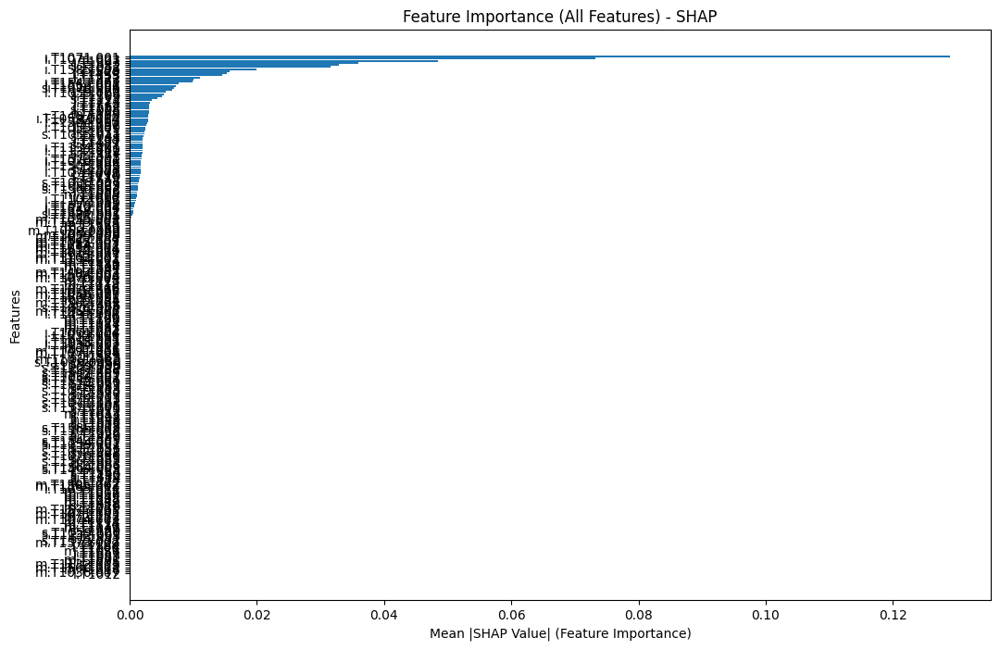

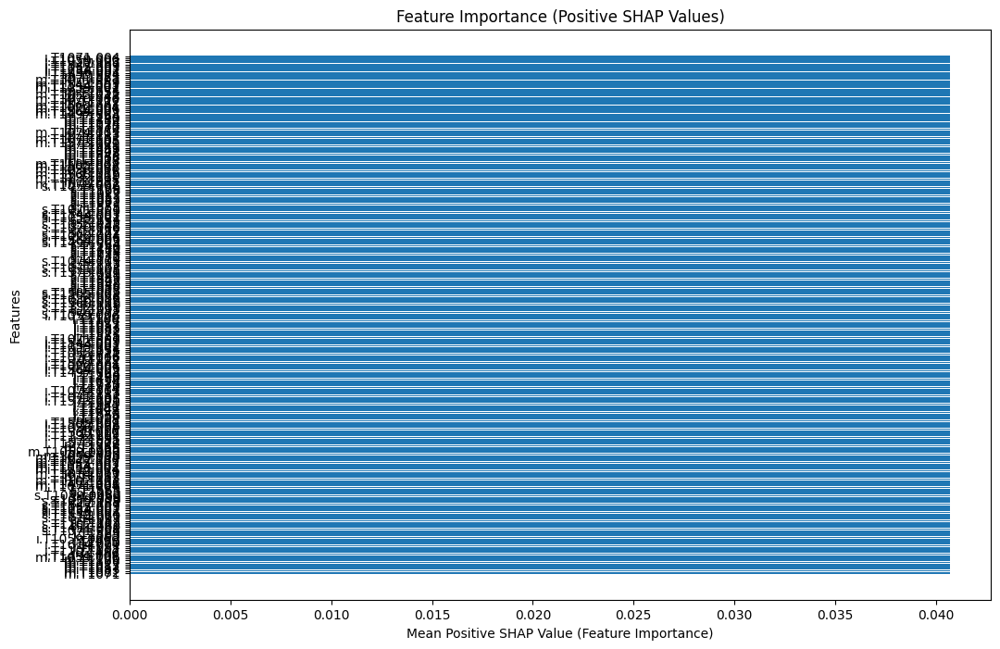


Model with Top 20 Features (Positive SHAP) - Confusion Matrix:
[[8 6]
 [6 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       0.45      0.45      0.45        11

    accuracy                           0.52        25
   macro avg       0.51      0.51      0.51        25
weighted avg       0.52      0.52      0.52        25


Model with Top 50 Features (Positive SHAP) - Confusion Matrix:
[[8 6]
 [6 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.57      0.57        14
           1       0.45      0.45      0.45        11

    accuracy                           0.52        25
   macro avg       0.51      0.51      0.51        25
weighted avg       0.52      0.52      0.52        25



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Verileri yükleyin (kendi veriniz ile değiştirin)
# df = pd.read_csv("data.csv")  # Verinizi buraya yükleyin

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel types
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# Pozitif SHAP değerlerini filtreleyelim ve ortalama mutlak değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerli en önemli feature'ları seçelim
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri filtreleniyor
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance göstermek
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All Features) - SHAP")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_shap.index[:20]]
X_test_20 = X_test[:, importance_df_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features (Positive SHAP) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_shap.index[:50]]
X_test_50 = X_test[:, importance_df_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features (Positive SHAP) - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


***`smote`***

Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



  0%|          | 0/25 [00:00<?, ?it/s]

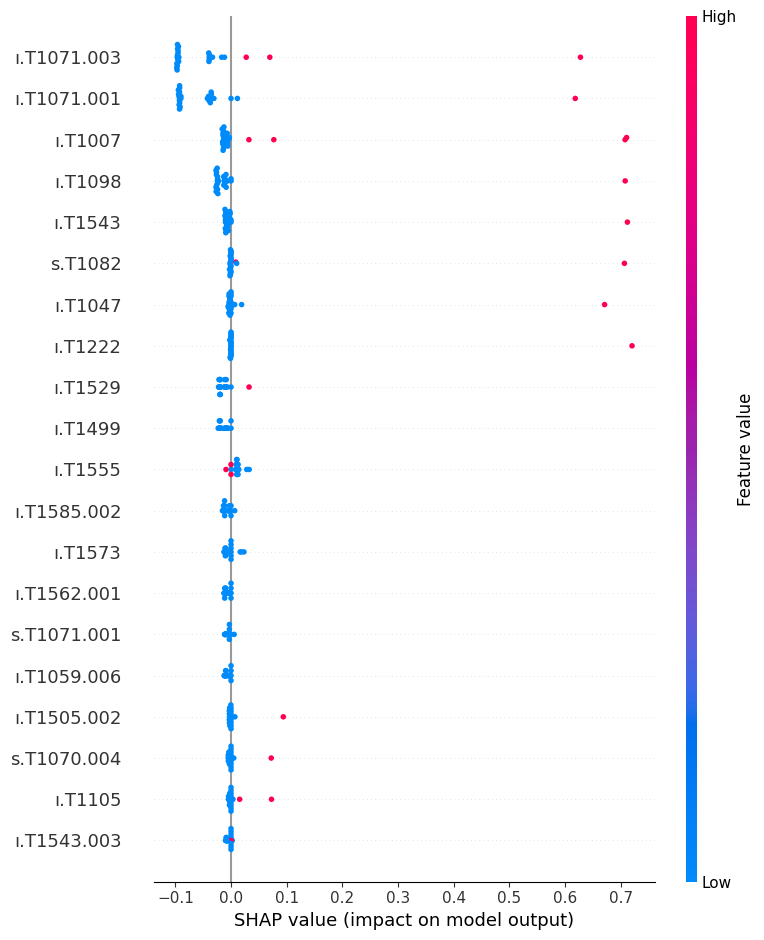

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


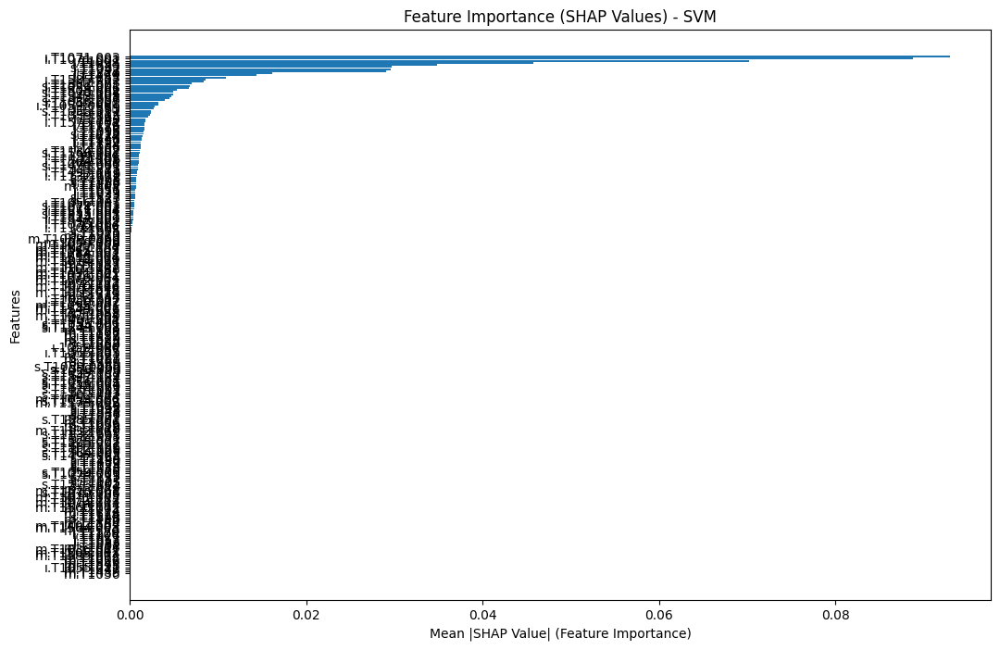


Model with Top 20 Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25


Model with Top 50 Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



In [ ]:
# Gerekli kütüphaneleri yükleyin
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel("data.xlsx")  # root yerine dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel types
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# En iyi model ile Feature Importance hesaplama (SHAP ile)
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance
# Lineer kernel kullanıyorsanız, coef_ ile importance hesaplanabilir
if best_params['kernel'] == 'linear':
    feature_importance = np.abs(best_model.coef_[0])  # Koefisyanlar negatif veya pozitif olabilir, mutlak değer alarak önem hesaplıyoruz
    features = X.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Feature Importance grafiği (Linear Kernel)
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel("Importance (Absolute Coefficient Value)")
    plt.ylabel("Features")
    plt.title("Feature Importance - SVM (Linear Kernel)")
    plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
    plt.show()
else:
    # Diğer kernel türleri için SHAP ile Feature Importance
    explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
    shap_values = explainer.shap_values(X_test)

    # SHAP summary plot (grafik)
    shap.summary_plot(shap_values, X_test, feature_names=X.columns)

    # SHAP değerlerinin ortalama mutlak değerini alarak feature importance hesaplayalım
    feature_importance_shap = np.mean(np.abs(shap_values), axis=0)
    importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance_shap})
    importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

    # Bar grafiği ile SHAP importance'ını gösterelim
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
    plt.xlabel("Mean |SHAP Value| (Feature Importance)")
    plt.ylabel("Features")
    plt.title("Feature Importance (SHAP Values) - SVM")
    plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
    plt.show()

    # En önemli 20 ve 50 özellikleri seçme
    top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
    top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

    # En önemli 20 özellik ile modeli yeniden eğitme
    X_train_20 = X_train[:, importance_df_shap.index[:20]]
    X_test_20 = X_test[:, importance_df_shap.index[:20]]

    best_model_20 = SVC(**best_params)
    best_model_20.fit(X_train_20, y_train)
    y_pred_20 = best_model_20.predict(X_test_20)

    print("\nModel with Top 20 Features - Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_20))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_20))

    # En önemli 50 özellik ile modeli yeniden eğitme
    X_train_50 = X_train[:, importance_df_shap.index[:50]]
    X_test_50 = X_test[:, importance_df_shap.index[:50]]

    best_model_50 = SVC(**best_params)
    best_model_50.fit(X_train_50, y_train)
    y_pred_50 = best_model_50.predict(X_test_50)

    print("\nModel with Top 50 Features - Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_50))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_50))


# ***`SMOTE SHAP`***

Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



  0%|          | 0/25 [00:00<?, ?it/s]

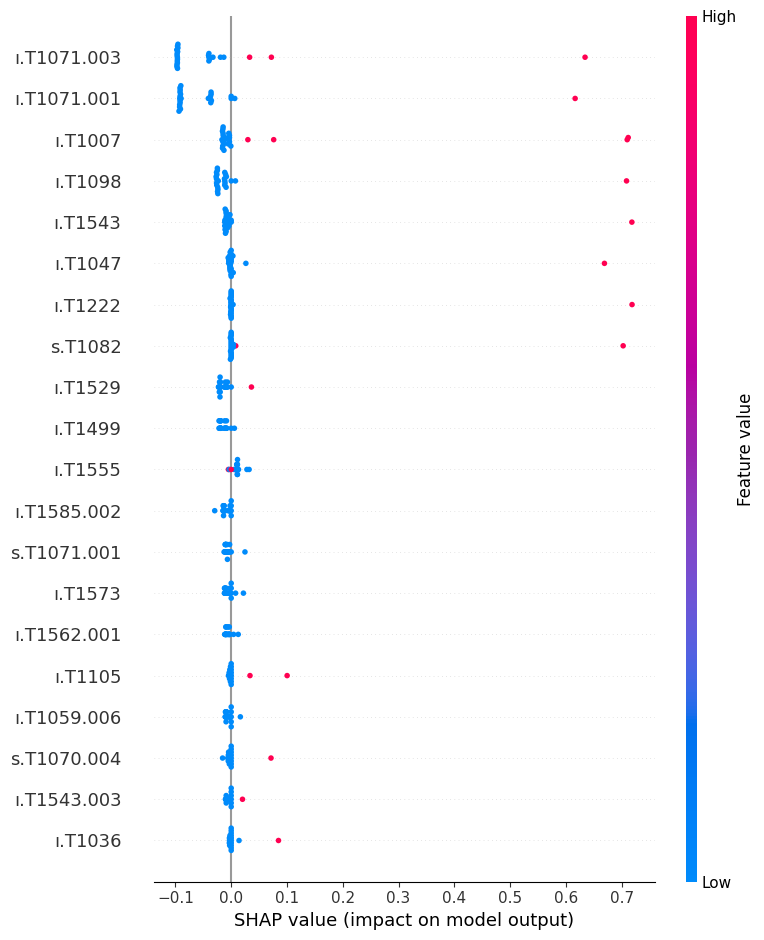

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


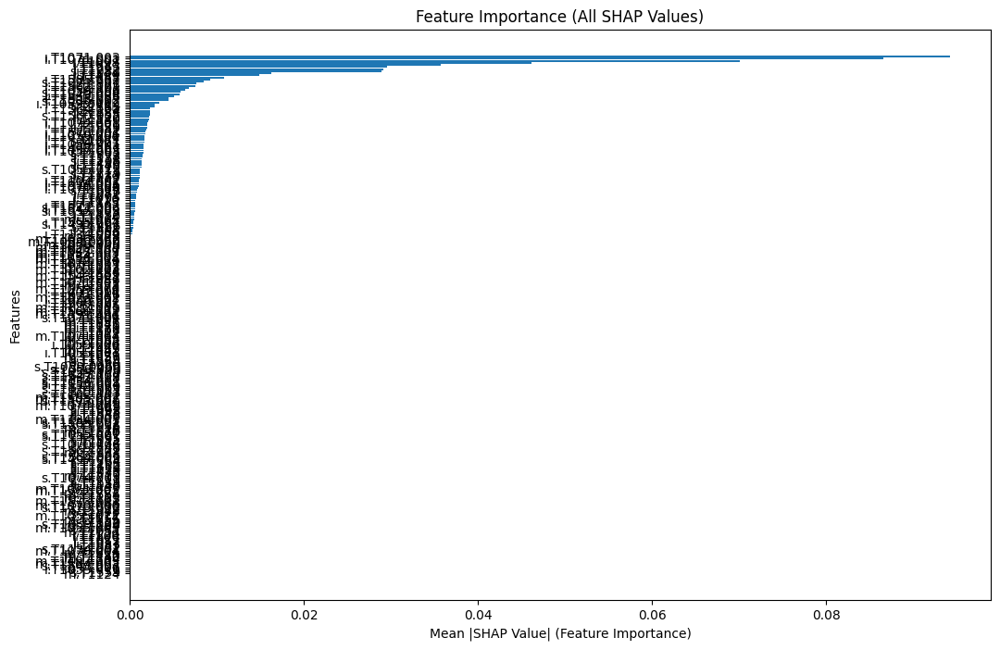

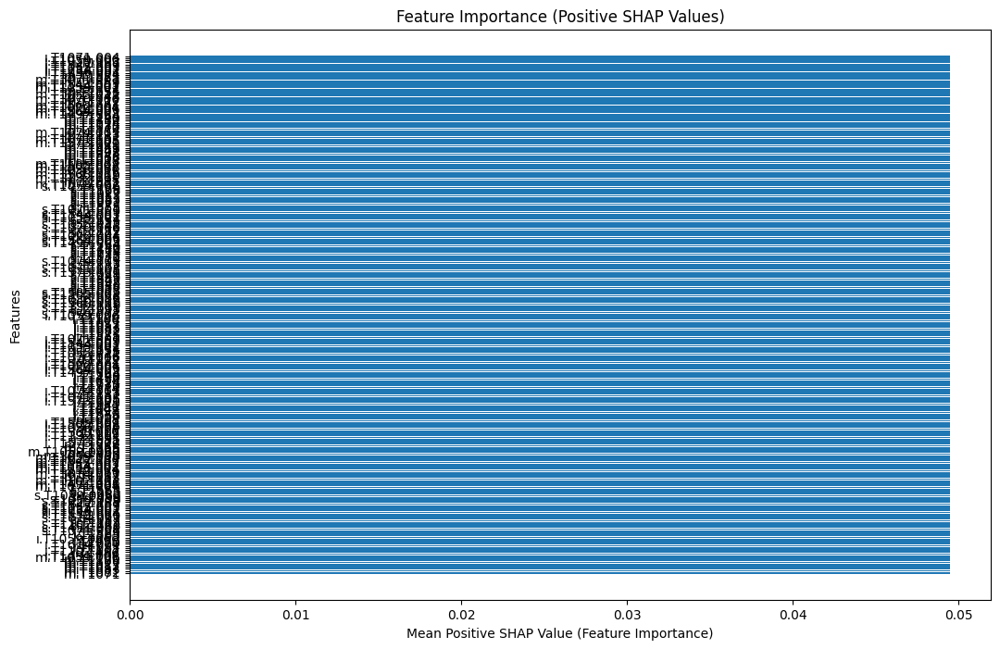


Model with Top 20 Positive SHAP Features - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25


Model with Top 50 Positive SHAP Features - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel("data.xlsx")  # root yerine dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel types
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerleri hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_positive_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_positive_shap.index[:20]]
X_test_20 = X_test[:, importance_df_positive_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_positive_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_positive_shap.index[:50]]
X_test_50 = X_test[:, importance_df_positive_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


## ***`Borderline-SMOTE`***

Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.
Malicious
1    62
0    59
Name: count, dtype: int64
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Confusion Matrix:
[[10  7]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.62        17
           1       0.30      0.38      0.33         8

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.55      0.52      0.53        25



  0%|          | 0/25 [00:00<?, ?it/s]

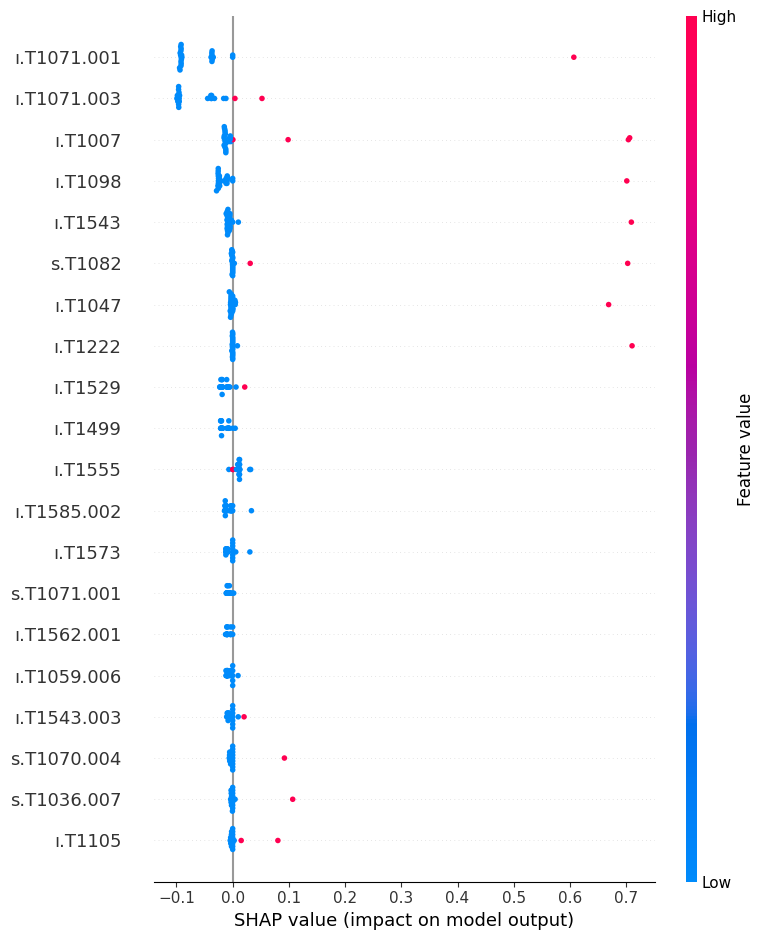

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


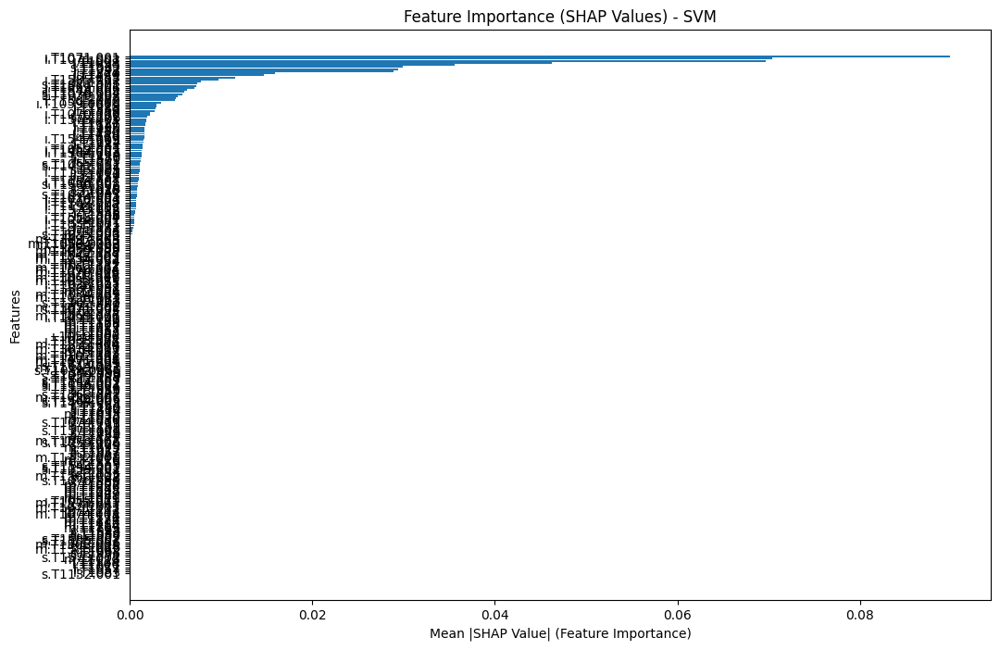


Model with Top 20 Features - Confusion Matrix:
[[10  7]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.62        17
           1       0.30      0.38      0.33         8

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.55      0.52      0.53        25


Model with Top 50 Features - Confusion Matrix:
[[10  7]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.62        17
           1       0.30      0.38      0.33         8

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.55      0.52      0.53        25



In [ ]:
# Gerekli kütüphaneleri yükleyin
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel("data.xlsx")  # root yerine dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Sınıf dağılımını kontrol edin
print(y.value_counts())

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel türleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# En iyi model ile Feature Importance hesaplama (SHAP ile)
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance
# SHAP ile importance hesaplama
if best_params['kernel'] == 'linear':
    feature_importance = np.abs(best_model.coef_[0])  # Koefisyanlar negatif veya pozitif olabilir, mutlak değer alarak önem hesaplıyoruz
    features = X.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Feature Importance grafiği (Linear Kernel)
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel("Importance (Absolute Coefficient Value)")
    plt.ylabel("Features")
    plt.title("Feature Importance - SVM (Linear Kernel)")
    plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
    plt.show()
else:
    # Diğer kernel türleri için SHAP ile Feature Importance
    explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
    shap_values = explainer.shap_values(X_test)

    # SHAP summary plot (grafik)
    shap.summary_plot(shap_values, X_test, feature_names=X.columns)

    # SHAP değerlerinin ortalama mutlak değerini alarak feature importance hesaplayalım
    feature_importance_shap = np.mean(np.abs(shap_values), axis=0)
    importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance_shap})
    importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

    # Bar grafiği ile SHAP importance'ını gösterelim
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
    plt.xlabel("Mean |SHAP Value| (Feature Importance)")
    plt.ylabel("Features")
    plt.title("Feature Importance (SHAP Values) - SVM")
    plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
    plt.show()

    # En önemli 20 ve 50 özellikleri seçme
    top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
    top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

    # En önemli 20 özellik ile modeli yeniden eğitme
    X_train_20 = X_train[:, importance_df_shap.index[:20]]
    X_test_20 = X_test[:, importance_df_shap.index[:20]]

    best_model_20 = SVC(**best_params)
    best_model_20.fit(X_train_20, y_train)
    y_pred_20 = best_model_20.predict(X_test_20)

    print("\nModel with Top 20 Features - Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_20))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_20))

    # En önemli 50 özellik ile modeli yeniden eğitme
    X_train_50 = X_train[:, importance_df_shap.index[:50]]
    X_test_50 = X_test[:, importance_df_shap.index[:50]]

    best_model_50 = SVC(**best_params)
    best_model_50.fit(X_train_50, y_train)
    y_pred_50 = best_model_50.predict(X_test_50)

    print("\nModel with Top 50 Features - Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_50))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_50))


# ***`borderline smote +shap`***

Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.
Malicious
1    62
0    59
Name: count, dtype: int64
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Best parameters found:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Confusion Matrix:
[[10  7]
 [ 5  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.62        17
           1       0.30      0.38      0.33         8

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.55      0.52      0.53        25



  0%|          | 0/25 [00:00<?, ?it/s]

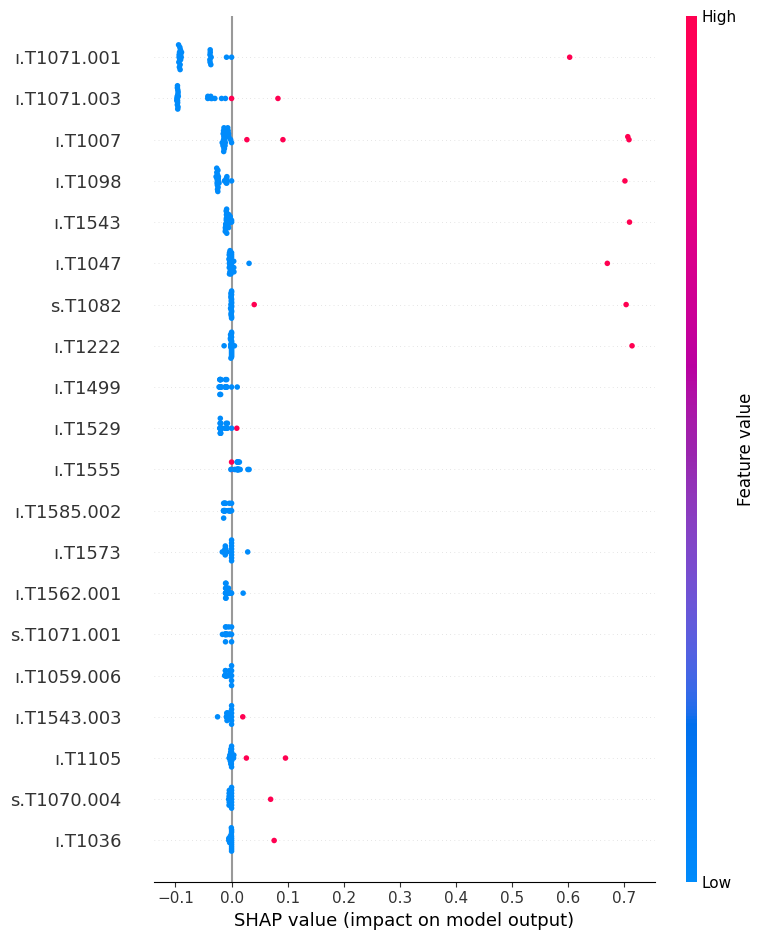

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


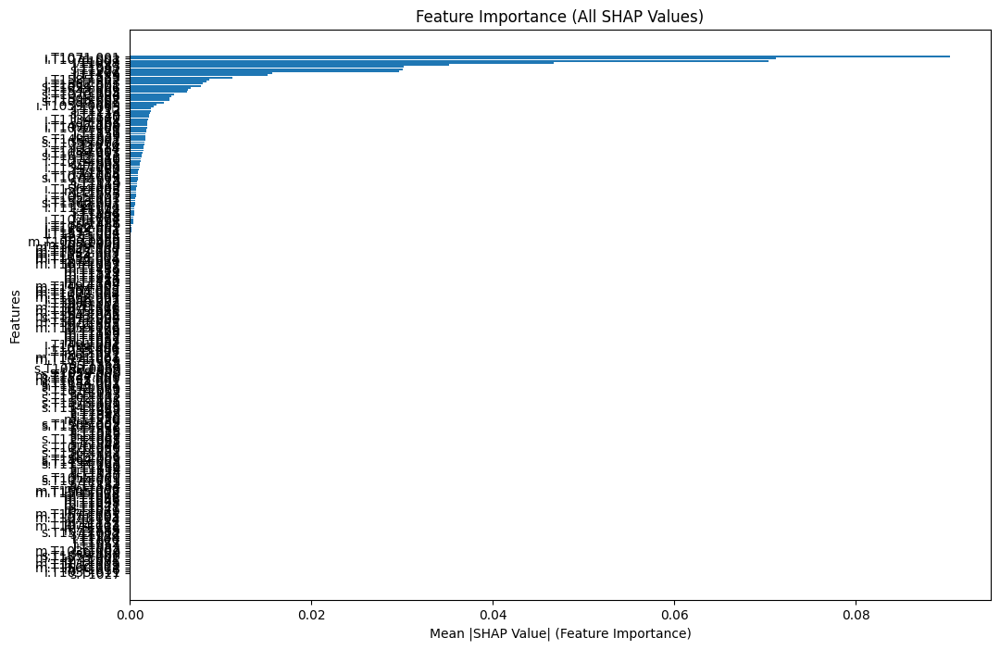

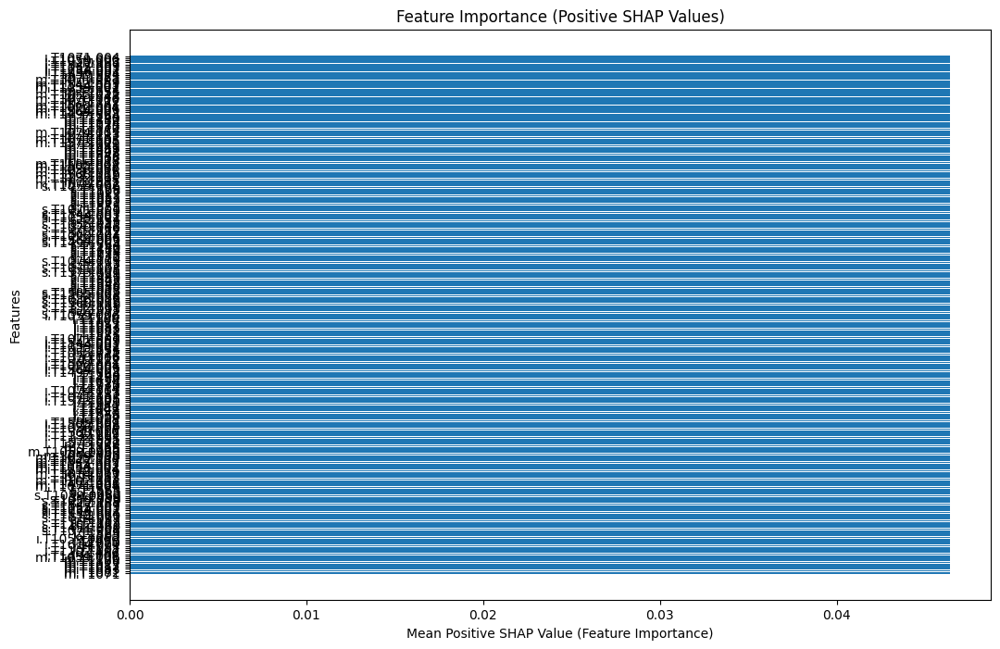


Model with Top 20 Positive SHAP Features - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25


Model with Top 50 Positive SHAP Features - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [ ]:
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel("data.xlsx")  # root yerine dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Sınıf dağılımını kontrol edin
print(y.value_counts())

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel türleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance hesaplama
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerleri hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_positive_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_positive_shap.index[:20]]
X_test_20 = X_test[:, importance_df_positive_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_positive_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_positive_shap.index[:50]]
X_test_50 = X_test[:, importance_df_positive_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`sometenc+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Malicious
1    62
0    59
Name: count, dtype: int64
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Bulunan en iyi parametreler:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Karmaşıklık Matrisi:
[[9 8]
 [5 3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



  0%|          | 0/25 [00:00<?, ?it/s]

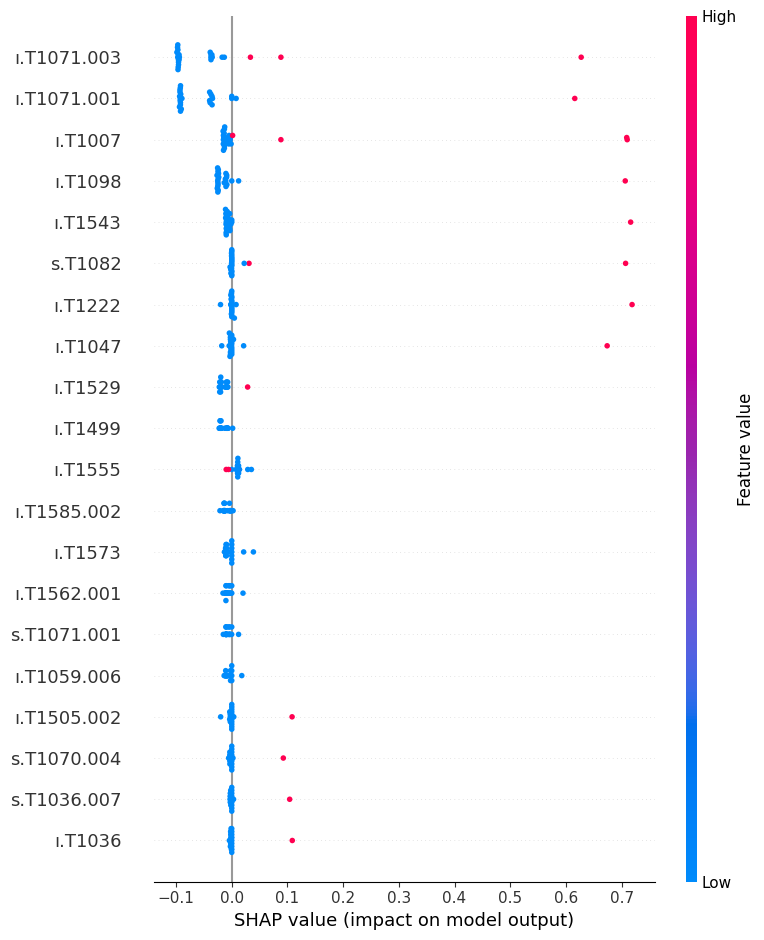


Model with Top 20 Positive SHAP Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25


Model with Top 50 Positive SHAP Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Sınıf dağılımını kontrol edin
print(y.value_counts())
categorical_features = [0, 2, 3]
# SMOTENC kullanarak veri artırma
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel tipleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Bulunan en iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# En iyi model ile Feature Importance hesaplama (SHAP ile)
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_  # Bu satır eklendi

# SHAP ile Feature Importance (kernel linear değilse)
explainer = shap.KernelExplainer(best_model.predict, X_egitim[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# SHAP değerlerinin ortalama mutlak değerini alarak feature importance hesaplayalım
feature_importance_shap = np.mean(np.abs(shap_values), axis=0)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance_shap})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerinin olduğu özellikleri seçelim
positive_shap_features = importance_df_shap[importance_df_shap['Importance'] > 0]

# Pozitif değerli en önemli ilk 20 ve 50 özelliği seçelim
top_20_features_shap = positive_shap_features['Feature'].iloc[:20]
top_50_features_shap = positive_shap_features['Feature'].iloc[:50]

# İlk 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, positive_shap_features.index[:20]]
X_test_20 = X_test[:, positive_shap_features.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_egitim)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# İlk 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, positive_shap_features.index[:50]]
X_test_50 = X_test[:, positive_shap_features.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_egitim)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`RandomOverSampler+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Bulunan en iyi parametreler:  {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Karmaşıklık Matrisi:
[[9 8]
 [5 3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



  0%|          | 0/25 [00:00<?, ?it/s]

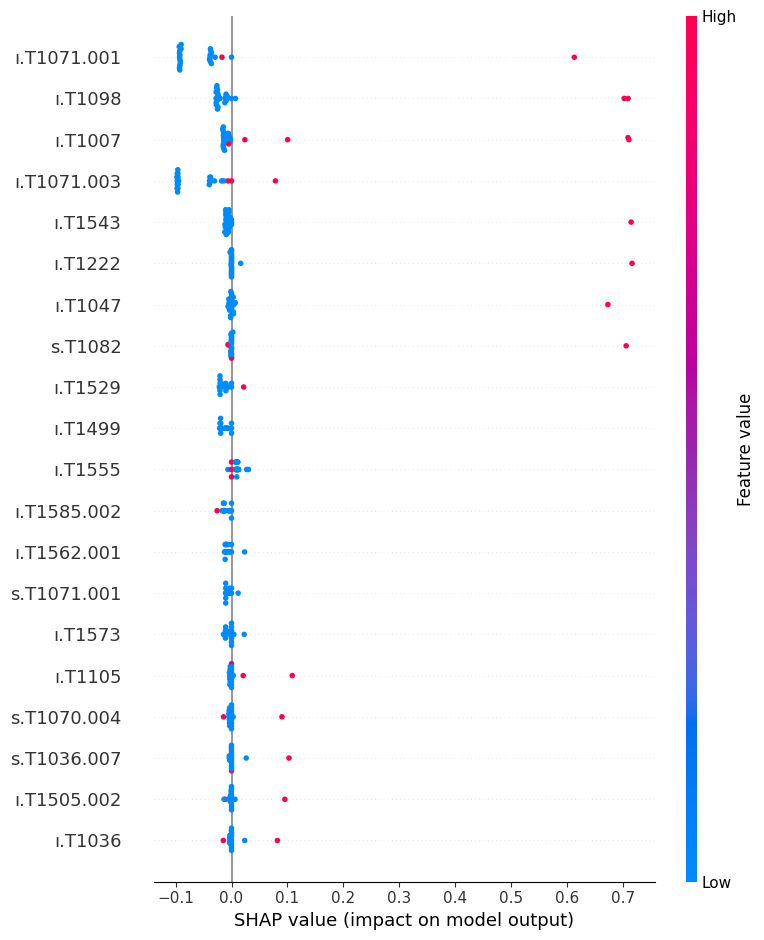

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


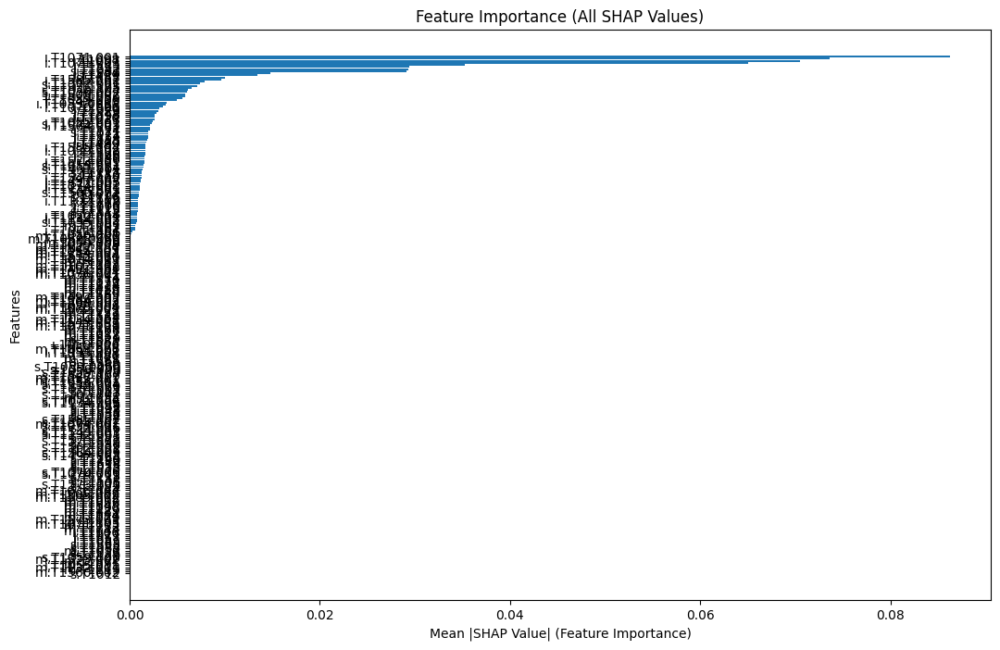

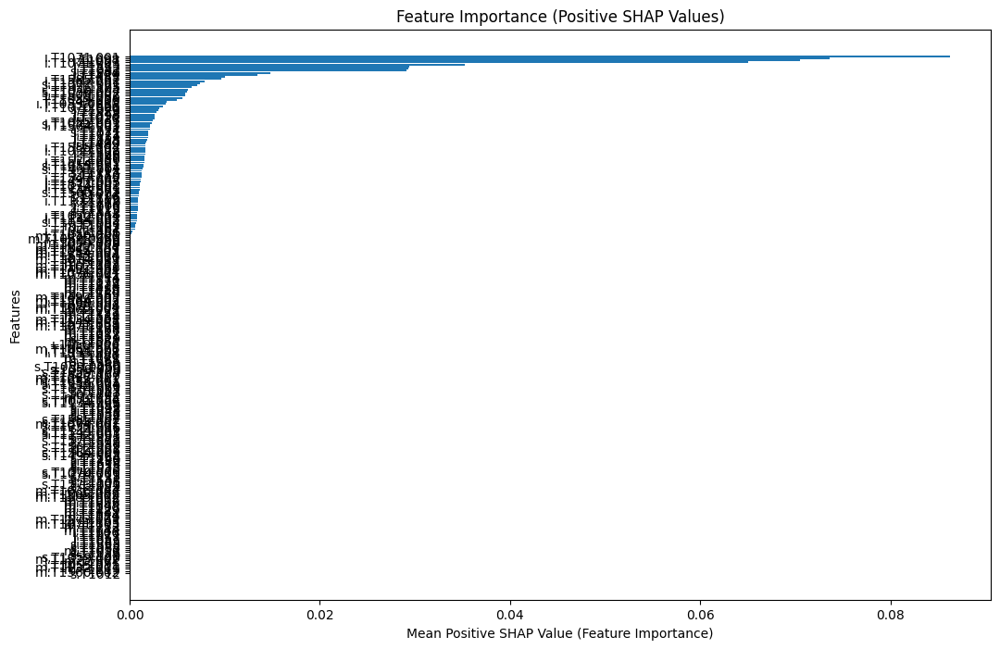


Model with Top 20 Positive SHAP Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25


Model with Top 50 Positive SHAP Features - Confusion Matrix:
[[9 8]
 [5 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58        17
           1       0.27      0.38      0.32         8

    accuracy                           0.48        25
   macro avg       0.46      0.45      0.45        25
weighted avg       0.52      0.48      0.50        25



In [ ]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel türleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Bulunan en iyi parametreler: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance hesaplama
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# SHAP feature importance hesaplama (Tüm SHAP değerlerini kullanarak)
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerleri hesaplayalım
positive_shap_values = shap_values_abs  # Zaten tüm SHAP değerlerinin mutlak değerini aldık
mean_positive_shap_values = np.mean(positive_shap_values, axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_positive_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_positive_shap.index[:20]]
X_test_20 = X_test[:, importance_df_positive_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_positive_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_positive_shap.index[:50]]
X_test_50 = X_test[:, importance_df_positive_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Positive SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Tomek Links+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 96 candidates, totalling 288 fits
En iyi parametreler: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Karmaşıklık Matrisi:
[[6 6]
 [7 5]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.46      0.50      0.48        12
           1       0.45      0.42      0.43        12

    accuracy                           0.46        24
   macro avg       0.46      0.46      0.46        24
weighted avg       0.46      0.46      0.46        24



  0%|          | 0/24 [00:00<?, ?it/s]

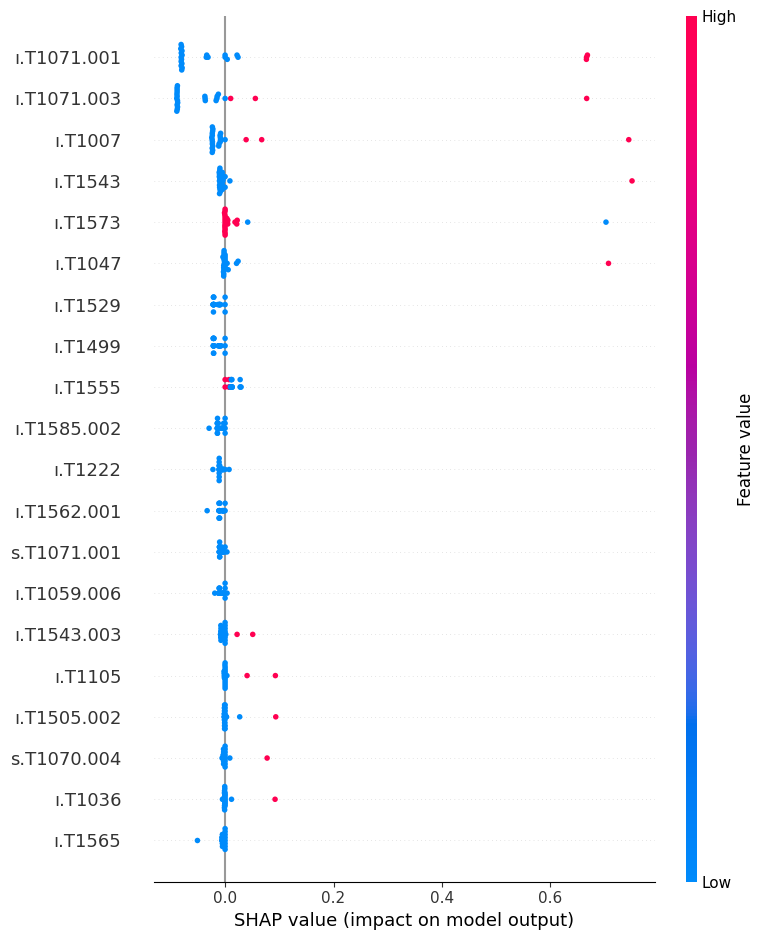

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


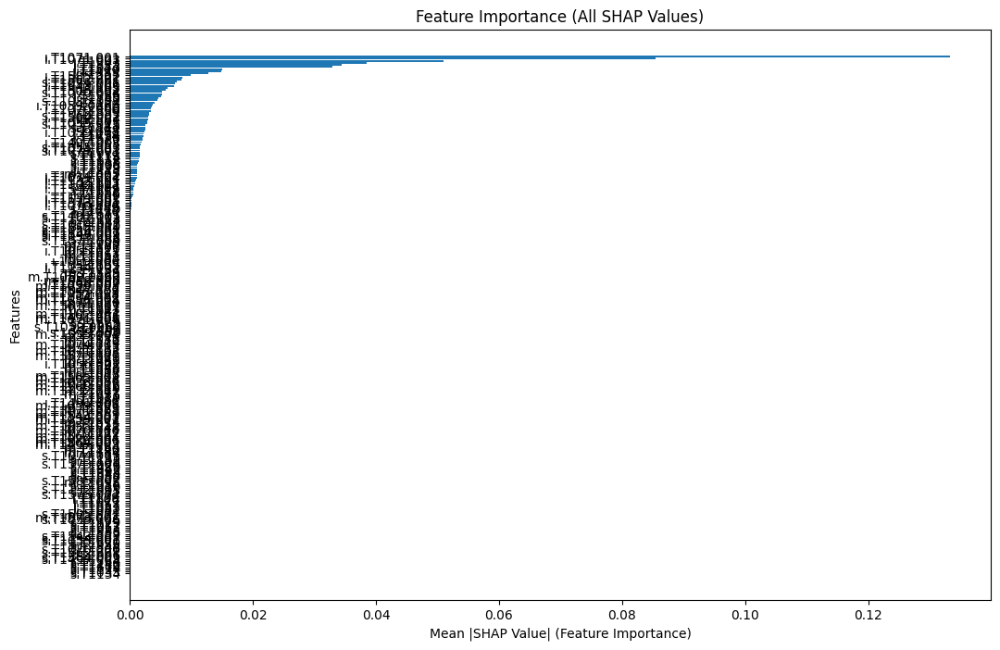


Model with Top 20 SHAP Features - Confusion Matrix:
[[6 6]
 [7 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.50      0.48        12
           1       0.45      0.42      0.43        12

    accuracy                           0.46        24
   macro avg       0.46      0.46      0.46        24
weighted avg       0.46      0.46      0.46        24


Model with Top 50 SHAP Features - Confusion Matrix:
[[6 6]
 [7 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.50      0.48        12
           1       0.45      0.42      0.43        12

    accuracy                           0.46        24
   macro avg       0.46      0.46      0.46        24
weighted avg       0.46      0.46      0.46        24



In [ ]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links kullanarak veri dengesizliğini düzeltme
tl = TomekLinks()
X_resampled, y_resampled = tl.fit_resample(X, y)

# Eğitim ve test setlerini oluşturma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel tipleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("En iyi parametreler:", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance hesaplama
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# SHAP feature importance hesaplama (Tüm SHAP değerlerini kullanarak)
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_shap.index[:20]]
X_test_20 = X_test[:, importance_df_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_shap.index[:50]]
X_test_50 = X_test[:, importance_df_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTETomek+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 96 candidates, totalling 288 fits
En iyi parametreler: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Karmaşıklık Matrisi:
[[8 5]
 [9 2]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.47      0.62      0.53        13
           1       0.29      0.18      0.22        11

    accuracy                           0.42        24
   macro avg       0.38      0.40      0.38        24
weighted avg       0.39      0.42      0.39        24



  0%|          | 0/24 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/shap/plots/_beeswarm.py:950: UserWarning: Glyph 9 (	) missing from current font.
  pl.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


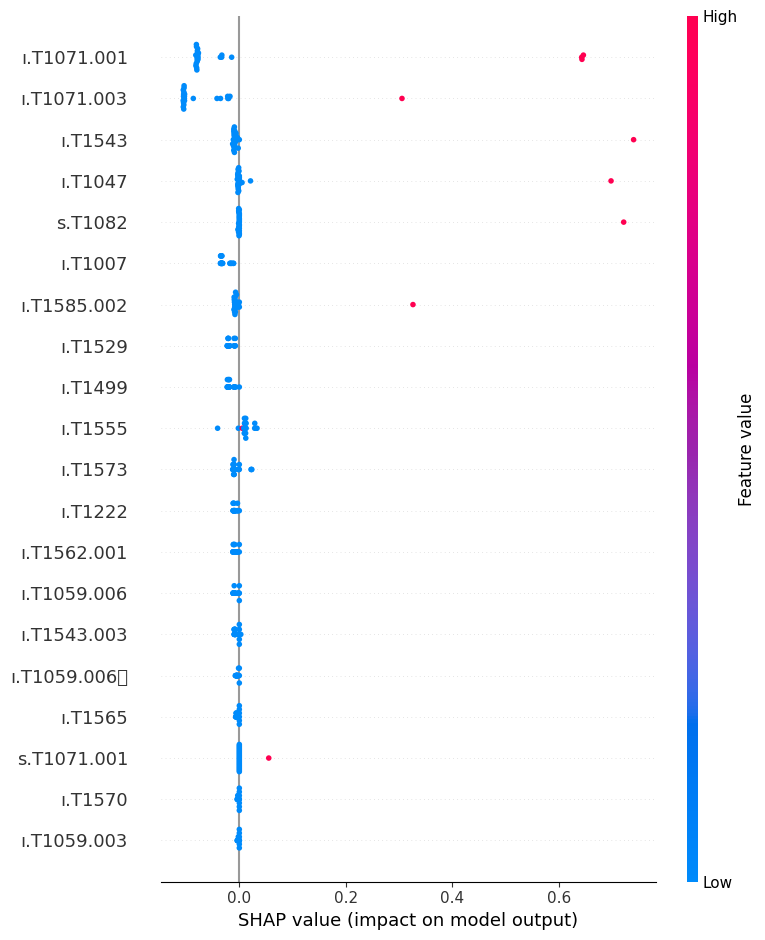

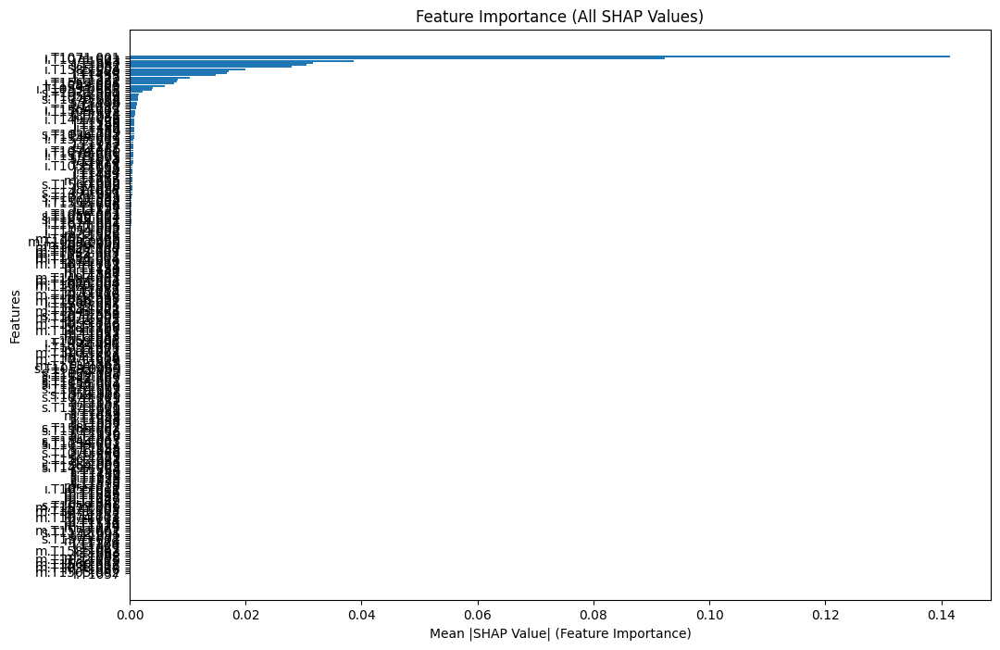


Model with Top 20 SHAP Features - Confusion Matrix:
[[8 5]
 [9 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.62      0.53        13
           1       0.29      0.18      0.22        11

    accuracy                           0.42        24
   macro avg       0.38      0.40      0.38        24
weighted avg       0.39      0.42      0.39        24


Model with Top 50 SHAP Features - Confusion Matrix:
[[8 5]
 [9 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.62      0.53        13
           1       0.29      0.18      0.22        11

    accuracy                           0.42        24
   macro avg       0.38      0.40      0.38        24
weighted avg       0.39      0.42      0.39        24



In [ ]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Kombine yöntemi kullanarak veri dengesizliğini düzeltme (SMOTE + Tomek Links)
smotek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smotek.fit_resample(X, y)

# Eğitim ve test setlerini oluşturma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'C': [0.1, 1, 10, 100],  # Düzenleme parametresi
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel katsayısı
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']  # Kernel tipleri
}

# Grid Search
grid_search = GridSearchCV(SVC(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("En iyi parametreler:", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# En iyi model ile SHAP Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP ile Feature Importance hesaplama
explainer = shap.KernelExplainer(best_model.predict, X_train[:100])  # İlk 100 örneği referans olarak alıyoruz
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (grafik)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# SHAP feature importance hesaplama (Tüm SHAP değerlerini kullanarak)
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 SHAP değeri ile modeli yeniden eğitme
top_20_features_shap = importance_df_shap.iloc[:20]['Feature'].values
X_train_20 = X_train[:, importance_df_shap.index[:20]]
X_test_20 = X_test[:, importance_df_shap.index[:20]]

best_model_20 = SVC(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 SHAP değeri ile modeli yeniden eğitme
top_50_features_shap = importance_df_shap.iloc[:50]['Feature'].values
X_train_50 = X_train[:, importance_df_shap.index[:50]]
X_test_50 = X_test[:, importance_df_shap.index[:50]]

best_model_50 = SVC(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Karar Ağaçları (Decision Trees)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Karar Ağaçları modelini oluştur
dt_model = DecisionTreeClassifier()

# Modeli eğit
dt_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendir
y_pred = dt_model.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50,60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'auto', 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 1008 candidates, totalling 3024 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
756 fits failed out of a total of 3024.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
286 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}
Confusion Matrix:
[[10  4]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.71      0.61        14
           1       0.33      0.18      0.24        11

    accuracy                           0.48        25
   macro avg       0.43      0.45      0.42        25
weighted avg       0.44      0.48      0.44        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


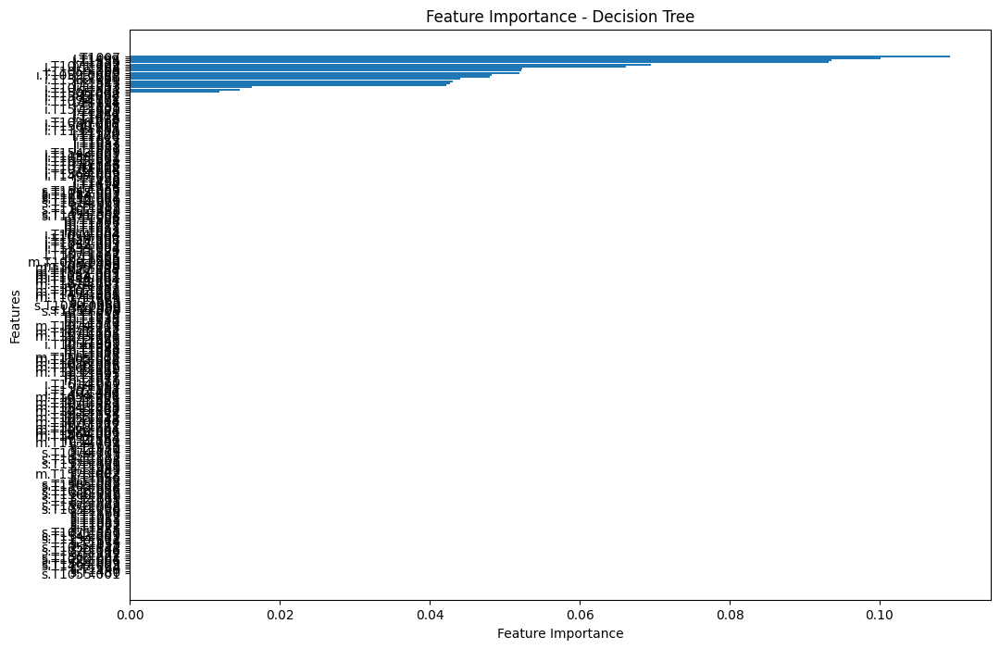

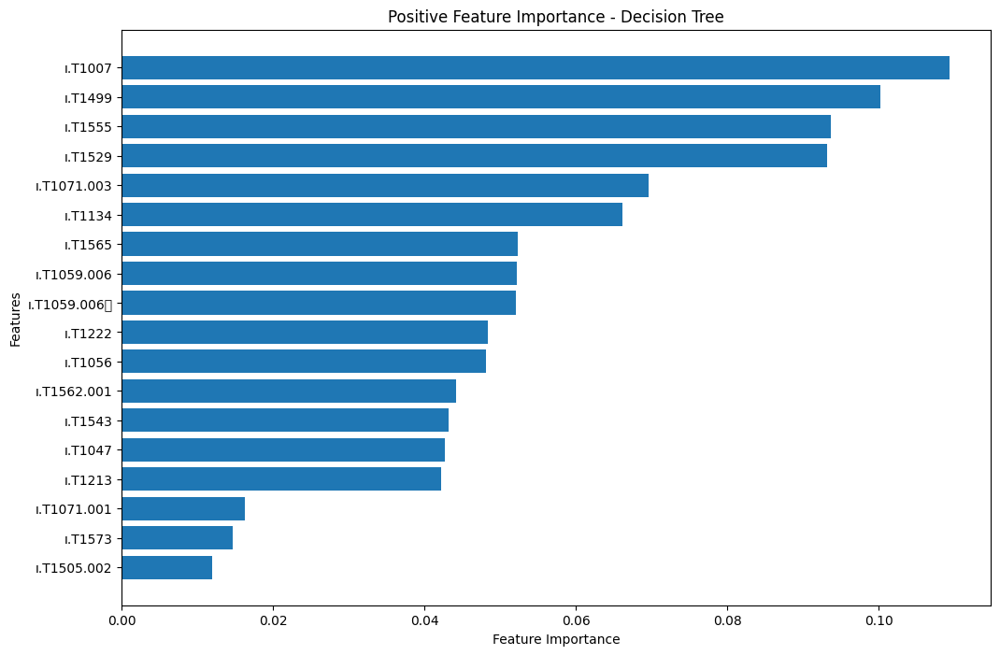


Model with Positive Feature Importance - Confusion Matrix:
[[10  4]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25


Model with Top 20 Features - Confusion Matrix:
[[10  4]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.71      0.61        14
           1       0.33      0.18      0.24        11

    accuracy                           0.48        25
   macro avg       0.43      0.45      0.42        25
weighted avg       0.44      0.48      0.44        25


Model with Top 50 Features - Confusion Matrix:
[[10  4]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [ ]:
# Gerekli kütüphaneleri yükleyin
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0.01'den büyük importance değerleri)
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params)
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]

best_model_20 = DecisionTreeClassifier(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]

best_model_50 = DecisionTreeClassifier(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


shap

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance hesaplama
best_model = grid_search.best_estimator_

# SHAP TreeExplainer ile feature importance hesaplama
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Binary sınıflandırmada shap_values iki sınıf için döndürülür, bu yüzden ikisini birleştiriyoruz
shap_values_combined = np.mean(np.abs(shap_values), axis=0)

# SHAP summary plot (birleştirilmiş SHAP değerleri kullanarak)
shap.summary_plot(shap_values_combined, X_test, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values_combined)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Bar grafikleri ile feature importance'ı göstermek
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()


Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

# ***`smote+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 864 candidates, totalling 2592 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
Confusion Matrix:
[[ 1 16]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


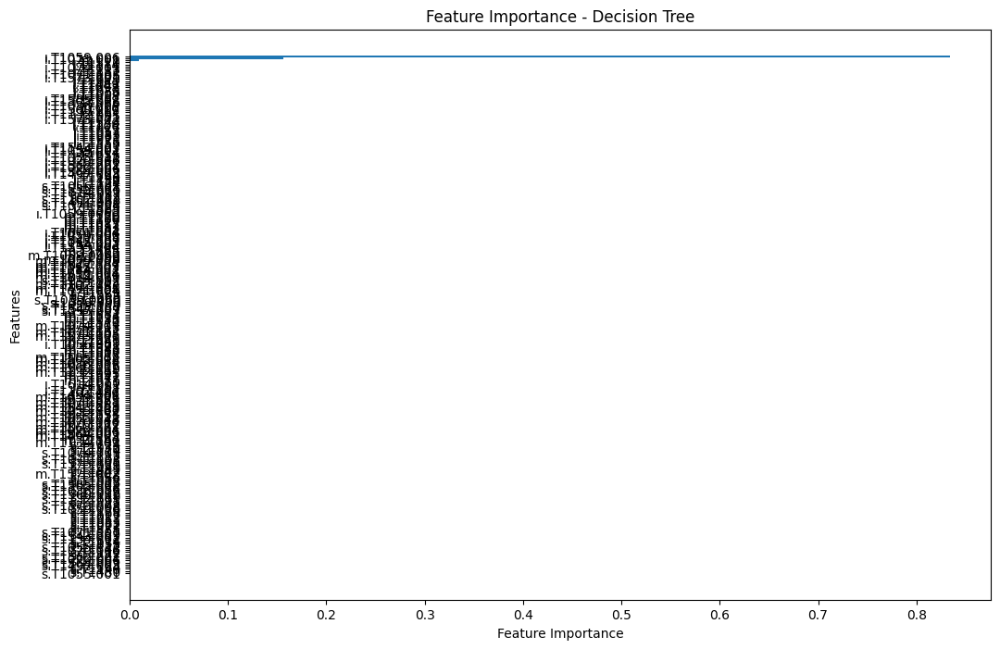


Model with Positive Feature Importance - Confusion Matrix:
[[ 1 16]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


Model with Top 20 Features - Confusion Matrix:
[[15  2]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        17
           1       0.50      0.25      0.33         8

    accuracy                           0.68        25
   macro avg       0.61      0.57      0.56        25
weighted avg       0.65      0.68      0.64        25


Model with Top 50 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası (daha geniş aralıklarla deneyin)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced'),  # Sınıf ağırlıkları dengelendi
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance ile yeniden eğitme
positive_features_list = positive_features['Feature'].tolist()
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

best_model_positive = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
best_model_20 = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
best_model_50 = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


***`Borderline-SMOTE+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'random'}

Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


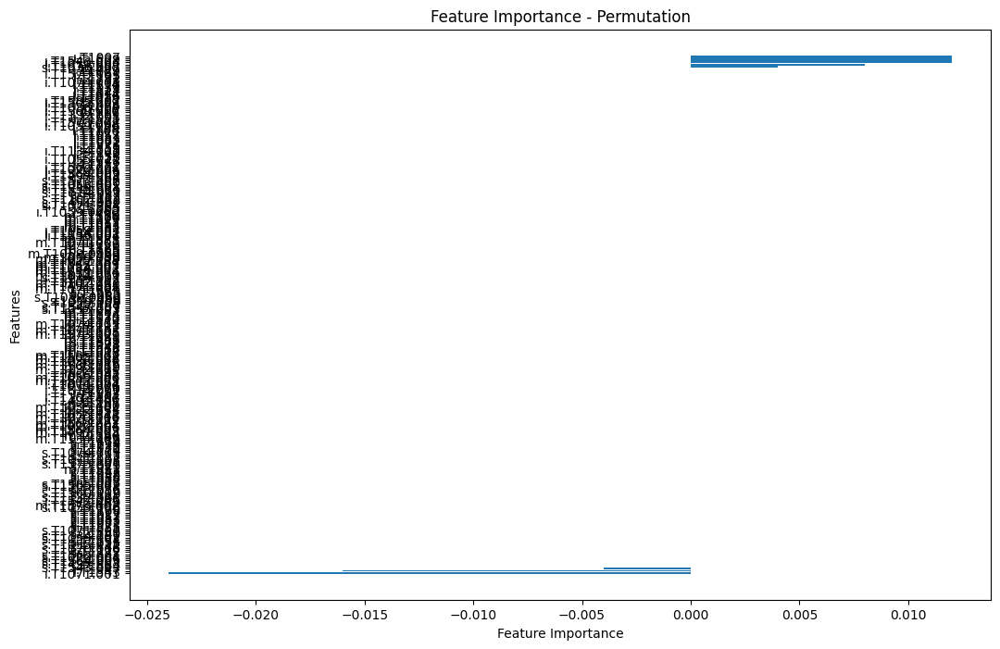

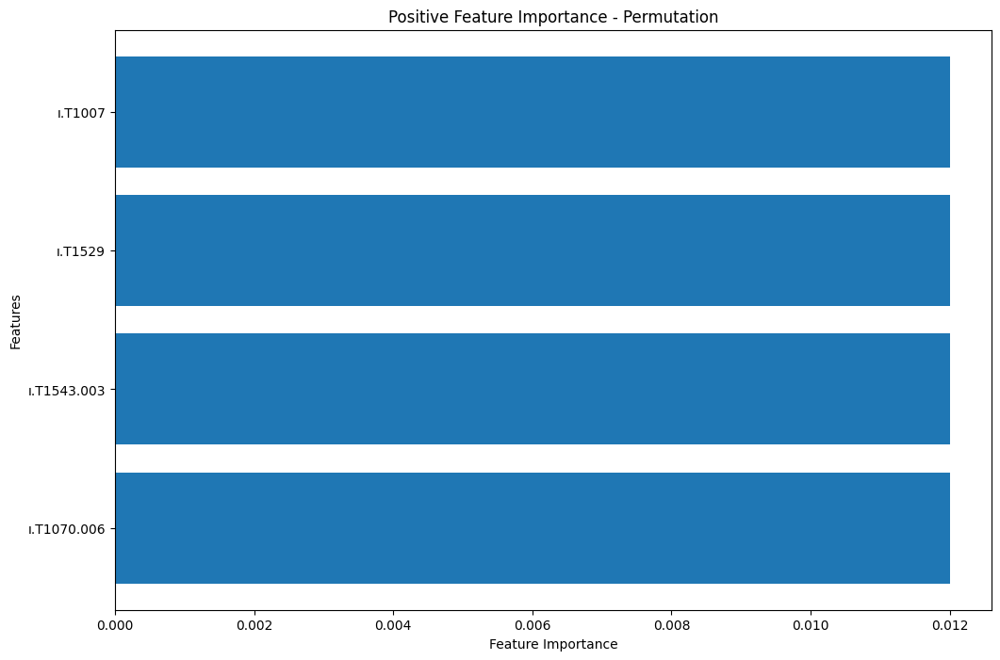


Model with Positive Feature Importance - Confusion Matrix:
[[15  2]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        17
           1       0.50      0.25      0.33         8

    accuracy                           0.68        25
   macro avg       0.61      0.57      0.56        25
weighted avg       0.65      0.68      0.64        25


Model with Top 20 Features - Confusion Matrix:
[[15  2]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        17
           1       0.50      0.25      0.33         8

    accuracy                           0.68        25
   macro avg       0.61      0.57      0.56        25
weighted avg       0.65      0.68      0.64        25


Model with Top 50 Features - Confusion Matrix:
[[14  3]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

# Veri yükleme (dosya yolunu doğru kontrol edin)
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(class_weight='balanced'),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Sonuçları gösterme
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# Permutation Feature Importance hesaplama
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42)

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Tüm feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Permutation")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitme
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Permutation")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile yeniden eğitim
positive_features_list = positive_features['Feature'].tolist()

# DataFrame'lerde doğru kolon seçimini yapalım
X_train_positive = X_train[:, [X.columns.get_loc(feature) for feature in positive_features_list]]
X_test_positive = X_test[:, [X.columns.get_loc(feature) for feature in positive_features_list]]

# Modeli pozitif feature'lar ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, [X.columns.get_loc(feature) for feature in top_20_features]]
X_test_20 = X_test[:, [X.columns.get_loc(feature) for feature in top_20_features]]
best_model_20 = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, [X.columns.get_loc(feature) for feature in top_50_features]]
X_test_50 = X_test[:, [X.columns.get_loc(feature) for feature in top_50_features]]
best_model_50 = DecisionTreeClassifier(**best_params, class_weight='balanced')
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


# ***`SMOTENC (SMOTE for Nominal and Continuous)+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'best'}
Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.66      0.50      0.24        25
weighted avg       0.78      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


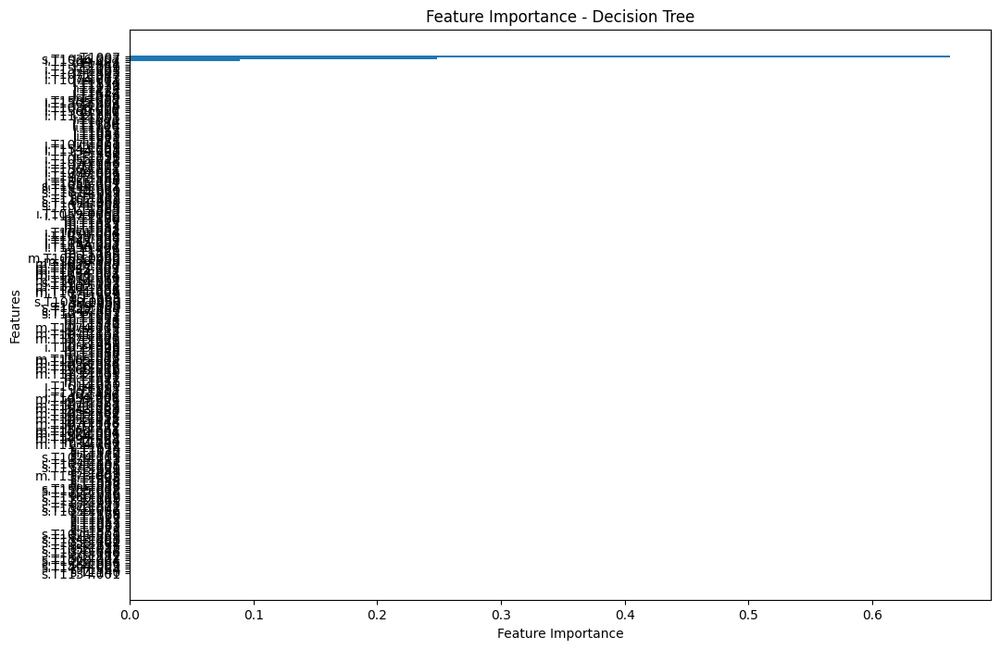

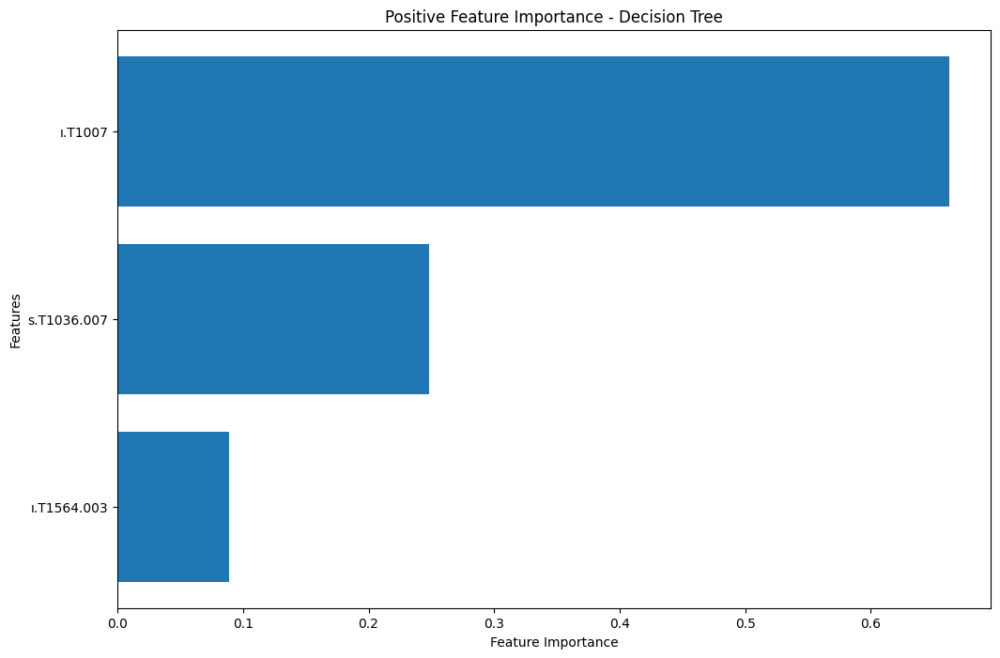


Model with Positive Feature Importance - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.66      0.50      0.24        25
weighted avg       0.78      0.32      0.16        25


Model with Top 20 Features - Confusion Matrix:
[[ 0 17]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.66      0.50      0.24        25
weighted avg       0.78      0.32      0.16        25


Model with Top 50 Features - Confusion Matrix:
[[ 2 15]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

      

In [10]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # 'root' yerine gerçek dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0.01'den büyük importance değerleri)
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params)
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
best_model_20 = DecisionTreeClassifier(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
best_model_50 = DecisionTreeClassifier(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


# ***`RandomOverSampler+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'splitter': 'random'}
Confusion Matrix:
[[ 1 16]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.06      0.11        17
           1       0.30      0.88      0.45         8

    accuracy                           0.32        25
   macro avg       0.40      0.47      0.28        25
weighted avg       0.44      0.32      0.22        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


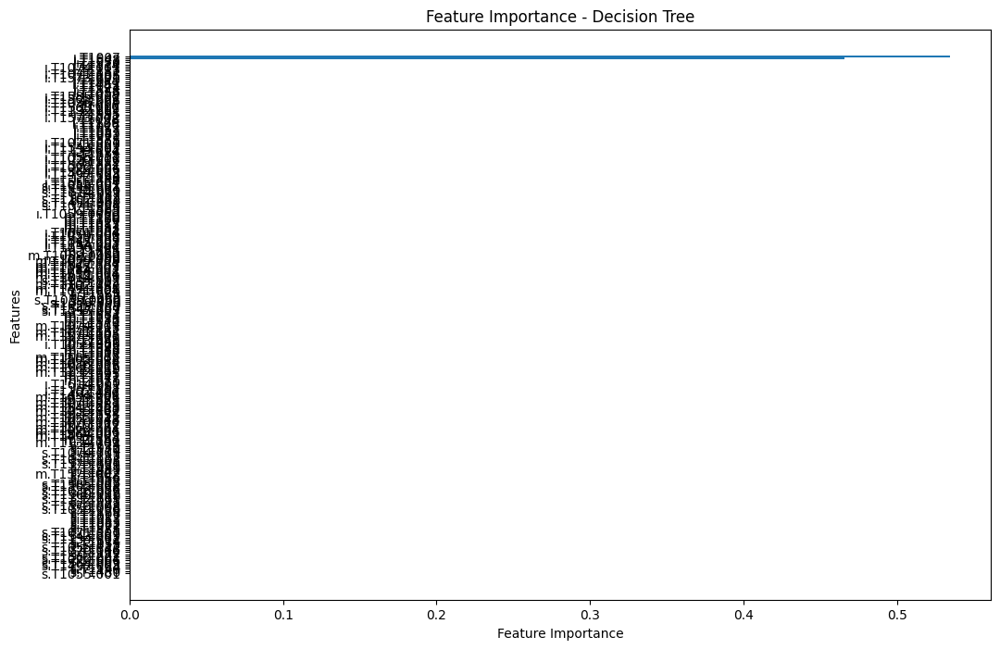

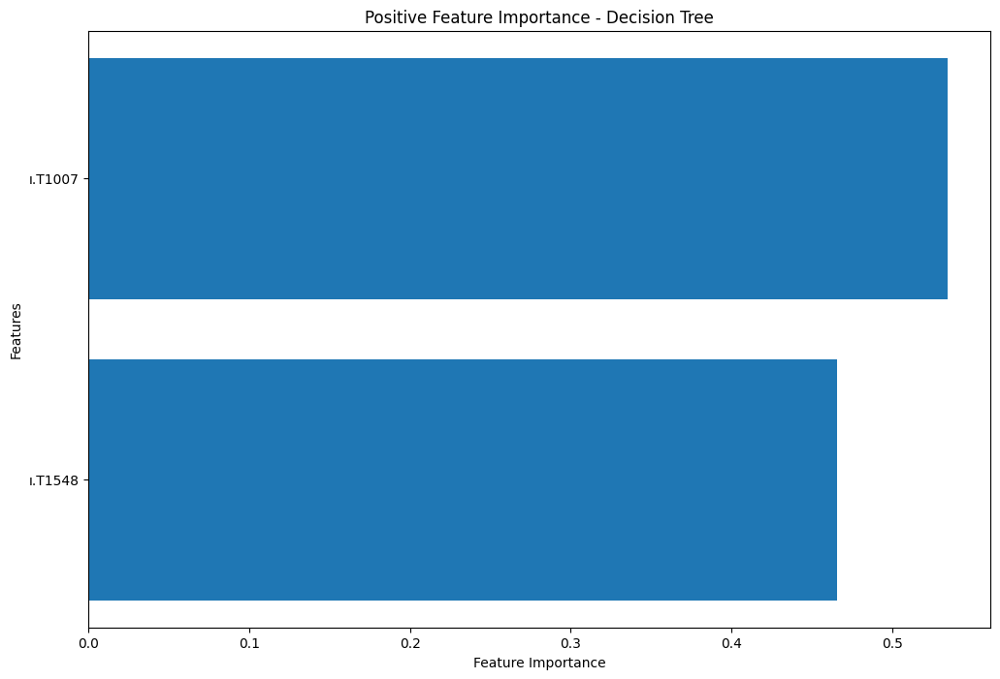


Model with Positive Feature Importance - Confusion Matrix:
[[ 1 16]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.06      0.11        17
           1       0.30      0.88      0.45         8

    accuracy                           0.32        25
   macro avg       0.40      0.47      0.28        25
weighted avg       0.44      0.32      0.22        25


Model with Top 20 Features - Confusion Matrix:
[[ 1 16]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.06      0.11        17
           1       0.30      0.88      0.45         8

    accuracy                           0.32        25
   macro avg       0.40      0.47      0.28        25
weighted avg       0.44      0.32      0.22        25


Model with Top 50 Features - Confusion Matrix:
[[ 2 15]
 [ 1  7]]

Classification Report:
              precision    recall  f1-score   support

      

In [12]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine doğru etiket sütununu yazmalısınız
y = df['Malicious']  # 'Malicious' yerine doğru etiket sütununu yazmalısınız

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0.01'den büyük importance değerleri)
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, [X.columns.get_loc(feature) for feature in positive_features_list]]
X_test_positive = X_test[:, [X.columns.get_loc(feature) for feature in positive_features_list]]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params)
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, [X.columns.get_loc(feature) for feature in top_20_features]]
X_test_20 = X_test[:, [X.columns.get_loc(feature) for feature in top_20_features]]
best_model_20 = DecisionTreeClassifier(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, [X.columns.get_loc(feature) for feature in top_50_features]]
X_test_50 = X_test[:, [X.columns.get_loc(feature) for feature in top_50_features]]
best_model_50 = DecisionTreeClassifier(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


# ***`Tomek Links+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'best'}
Confusion Matrix:
[[ 7  5]
 [10  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


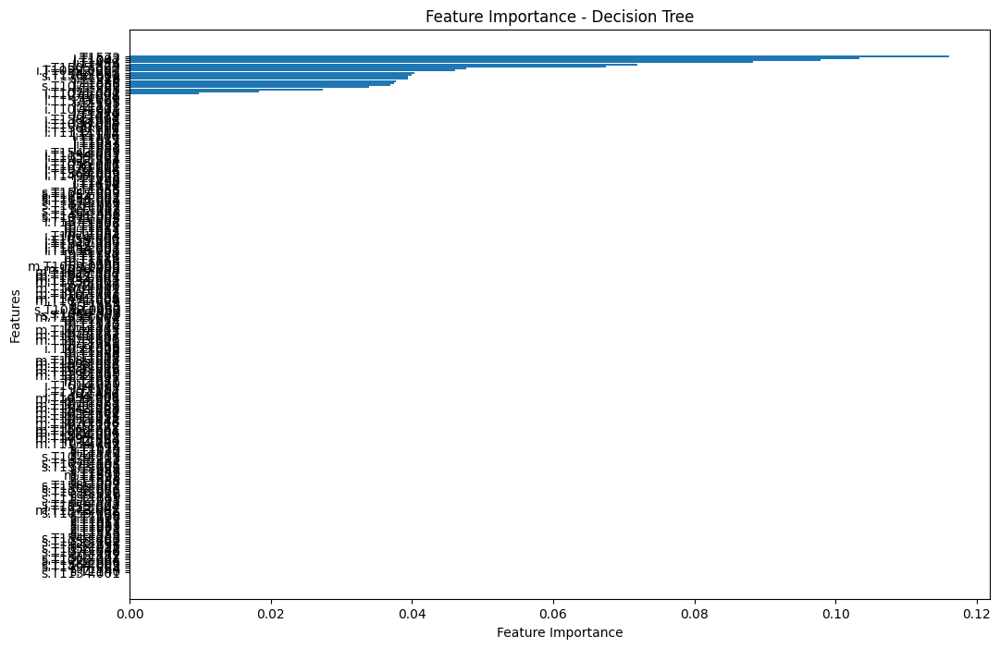

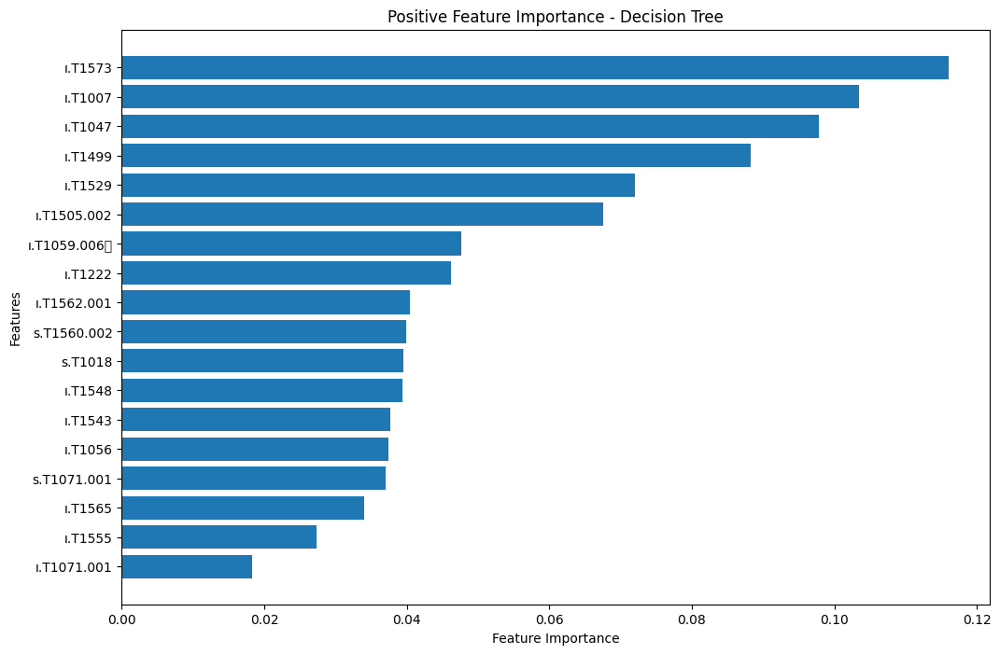


Model with Positive Feature Importance - Confusion Matrix:
[[7 5]
 [9 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.38      0.25      0.30        12

    accuracy                           0.42        24
   macro avg       0.41      0.42      0.40        24
weighted avg       0.41      0.42      0.40        24


Model with Top 20 Features - Confusion Matrix:
[[7 5]
 [9 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.38      0.25      0.30        12

    accuracy                           0.42        24
   macro avg       0.41      0.42      0.40        24
weighted avg       0.41      0.42      0.40        24


Model with Top 50 Features - Confusion Matrix:
[[ 8  4]
 [11  1]]

Classification Report:
              precision    recall  f1-score   support

           0  

In [13]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # 'root' yerine dosya yolunu buraya yazmalısınız
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links kullanarak veri dengesizliğini düzeltme
tl = TomekLinks()
X_resampled, y_resampled = tl.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0.01'den büyük importance değerleri)
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params)
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
best_model_20 = DecisionTreeClassifier(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
best_model_50 = DecisionTreeClassifier(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


# ***`SMOTE + Tomek Links)+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 756 candidates, totalling 2268 fits
Best parameters found:  {'criterion': 'gini', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       1.00      0.00      0.00        11

    accuracy                           0.54        24
   macro avg       0.77      0.50      0.35        24
weighted avg       0.75      0.54      0.38        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


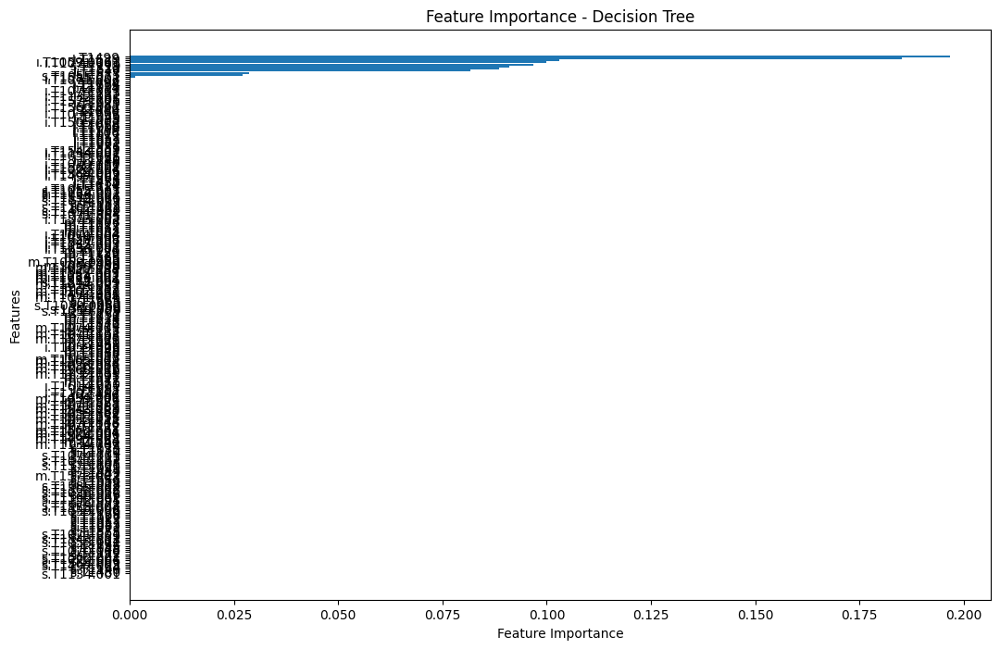

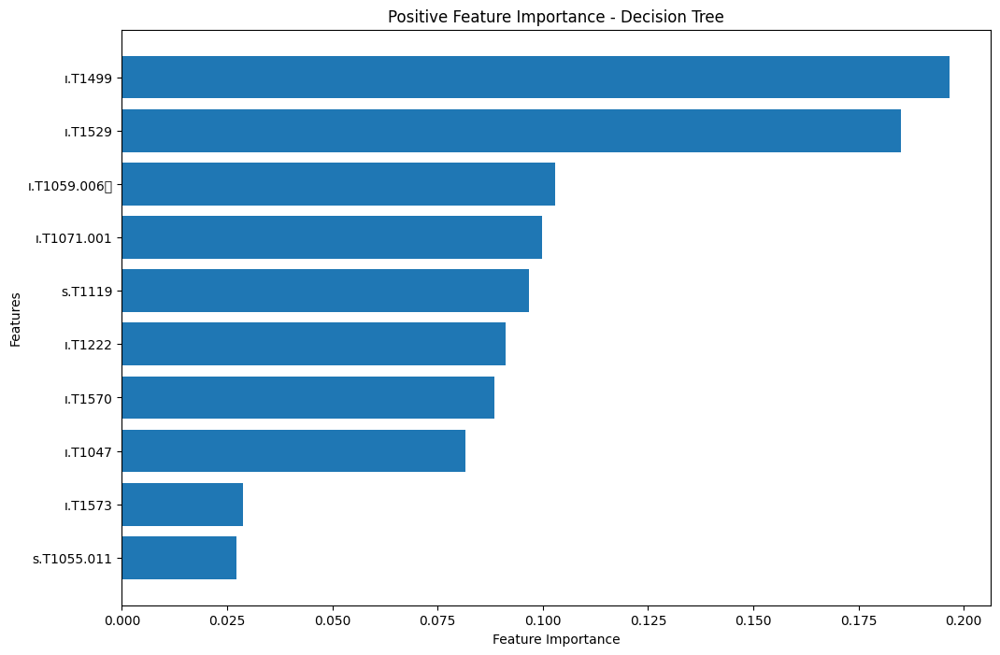


Model with Positive Feature Importance - Confusion Matrix:
[[11  2]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.85      0.65        13
           1       0.33      0.09      0.14        11

    accuracy                           0.50        24
   macro avg       0.43      0.47      0.39        24
weighted avg       0.44      0.50      0.42        24


Model with Top 20 Features - Confusion Matrix:
[[11  2]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.85      0.67        13
           1       0.50      0.18      0.27        11

    accuracy                           0.54        24
   macro avg       0.53      0.51      0.47        24
weighted avg       0.53      0.54      0.48        24


Model with Top 50 Features - Confusion Matrix:
[[12  1]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [14]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# DataFrame bilgilerini yazdırın
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Kombine yöntem ile veri dengesizliğini düzeltme (SMOTE + Tomek Links)
smotek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smotek.fit_resample(X, y)

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Karar Ağaçları için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50, 60],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# En iyi model ile Feature Importance hesaplama
best_model = grid_search.best_estimator_
feature_importance = best_model.feature_importances_
features = X.columns

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olacak şekilde sıralama
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0.01'den büyük importance değerleri)
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma (sütun indekslerini doğru şekilde seçiyoruz)
positive_indices = importance_df.index[importance_df['Feature'].isin(positive_features_list)]
X_train_positive = X_train[:, positive_indices]
X_test_positive = X_test[:, positive_indices]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = DecisionTreeClassifier(**best_params)
best_model_positive.fit(X_train_positive, y_train)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive, zero_division=1))

# En önemli 20 ve 50 özellikleri seçme
top_20_indices = importance_df.index[:20]
top_50_indices = importance_df.index[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, top_20_indices]
X_test_20 = X_test[:, top_20_indices]
best_model_20 = DecisionTreeClassifier(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20, zero_division=1))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, top_50_indices]
X_test_50 = X_test[:, top_50_indices]
best_model_50 = DecisionTreeClassifier(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50, zero_division=1))


# ***`K-En Yakın Komşu (KNN)`***

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'etiket_sutunu' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# K-En Yakın Komşu (KNN) modelini oluştur
knn_model = KNeighborsClassifier(n_neighbors=3)  # K değerini istediğiniz şekilde ayarlayabilirsiniz

# Modeli eğit
knn_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendir
y_pred = knn_model.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[11  3]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.79      0.67        14
           1       0.50      0.27      0.35        11

    accuracy                           0.56        25
   macro avg       0.54      0.53      0.51        25
weighted avg       0.54      0.56      0.53        25



In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Confusion Matrix:
[[10  4]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25



/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


# ***`shap`***

Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Confusion Matrix:
[[10  4]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


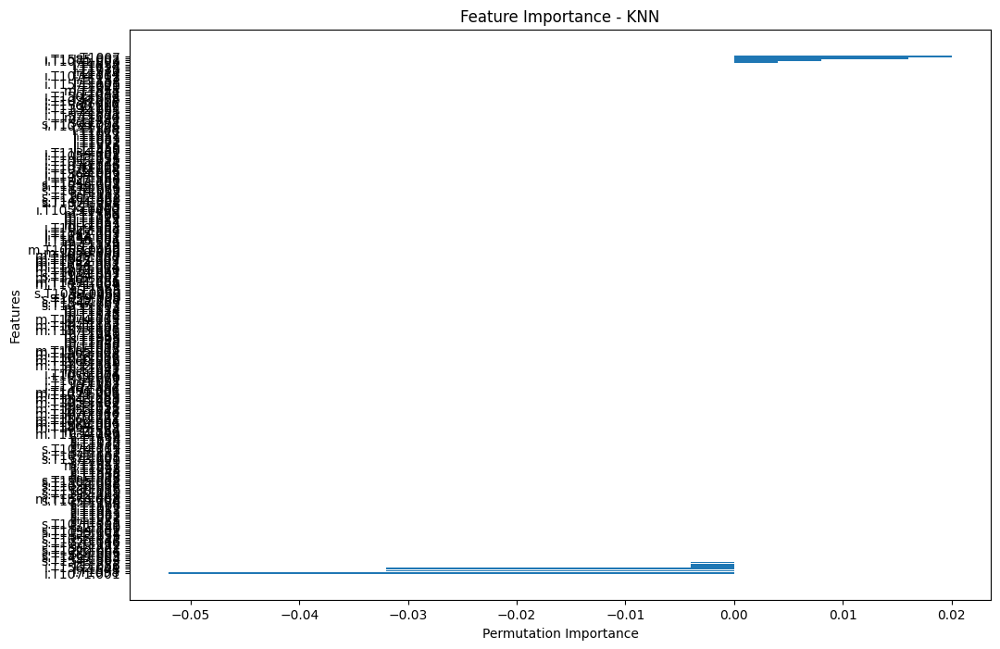

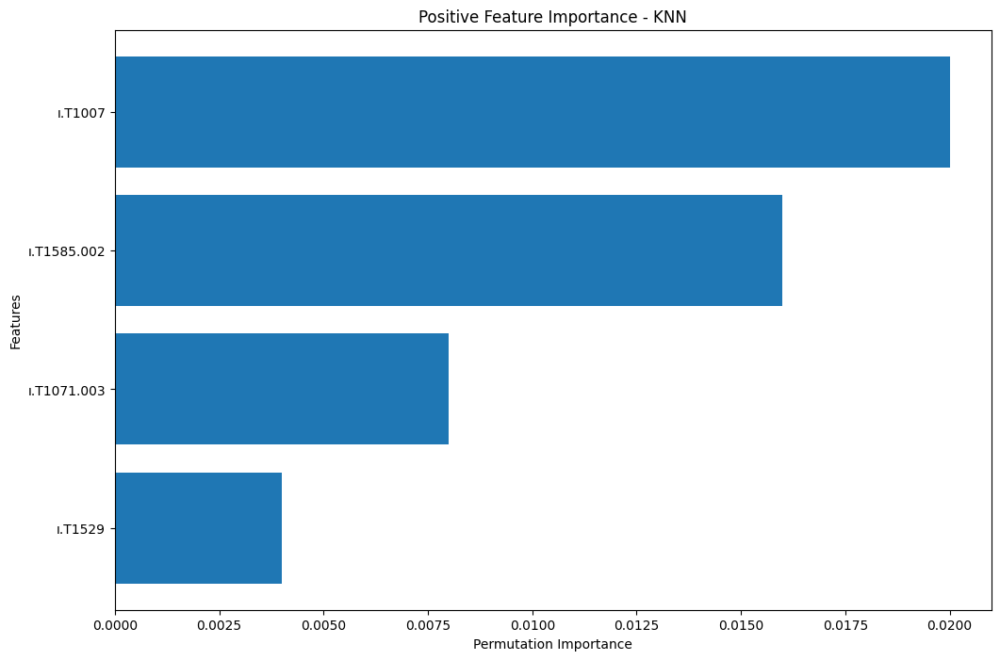


Model with Positive Feature Importance - Confusion Matrix:
[[ 0 14]
 [ 1 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.42      0.91      0.57        11

    accuracy                           0.40        25
   macro avg       0.21      0.45      0.29        25
weighted avg       0.18      0.40      0.25        25


Model with Top 20 Features - Confusion Matrix:
[[ 1 13]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.12        14
           1       0.41      0.82      0.55        11

    accuracy                           0.40        25
   macro avg       0.37      0.44      0.33        25
weighted avg       0.37      0.40      0.31        25


Model with Top 50 Features - Confusion Matrix:
[[ 1 13]
 [ 1 10]]

Classification Report:
              precision    recall  f1-score   support

      

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_egitim)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_egitim)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`smote+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Confusion Matrix:
[[12  5]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


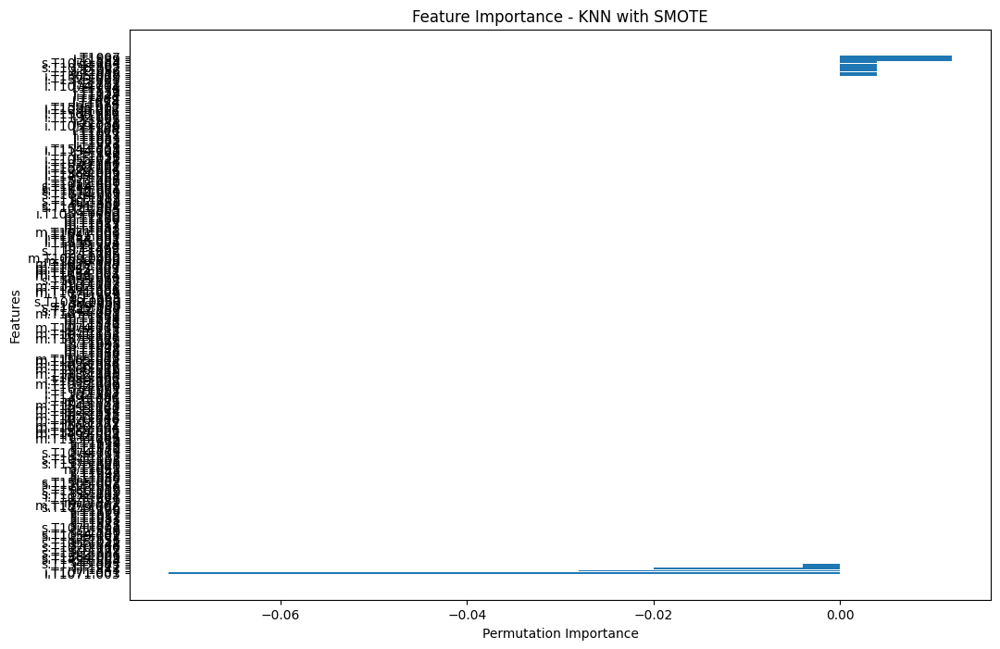

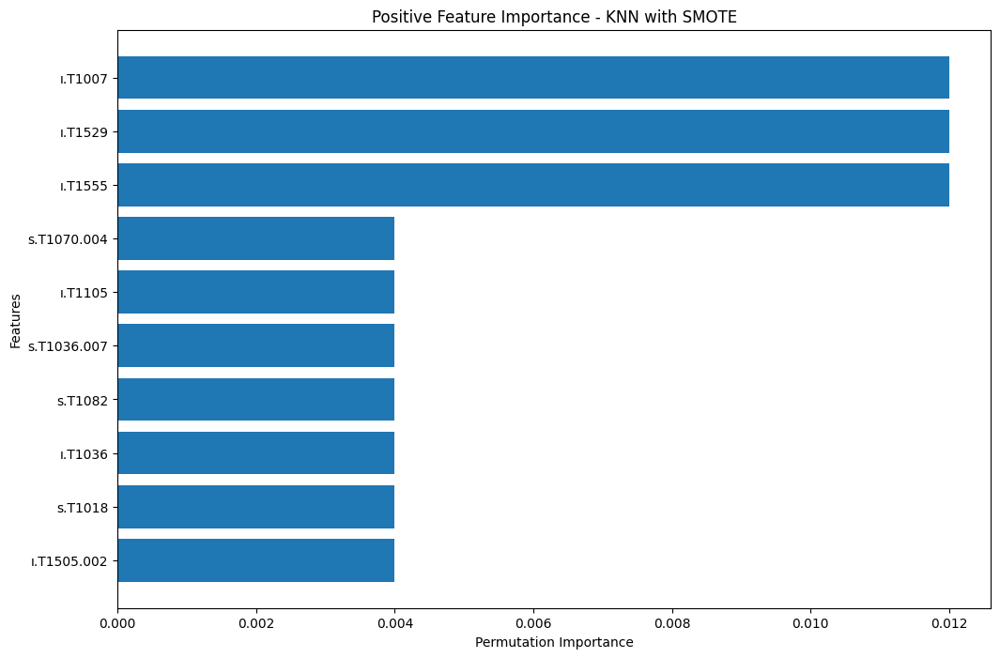


Model with Positive Feature Importance - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25


Model with Top 20 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 50 Features - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [18]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosyayı okuyun
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN with SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN with SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_egitim)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_egitim)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Borderline-SMOTE+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


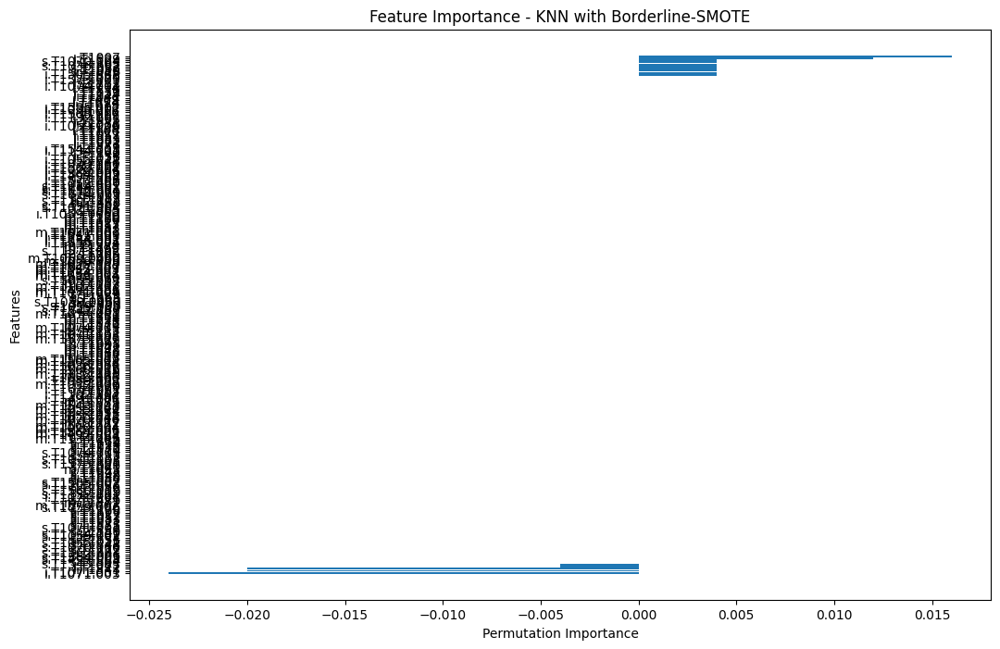

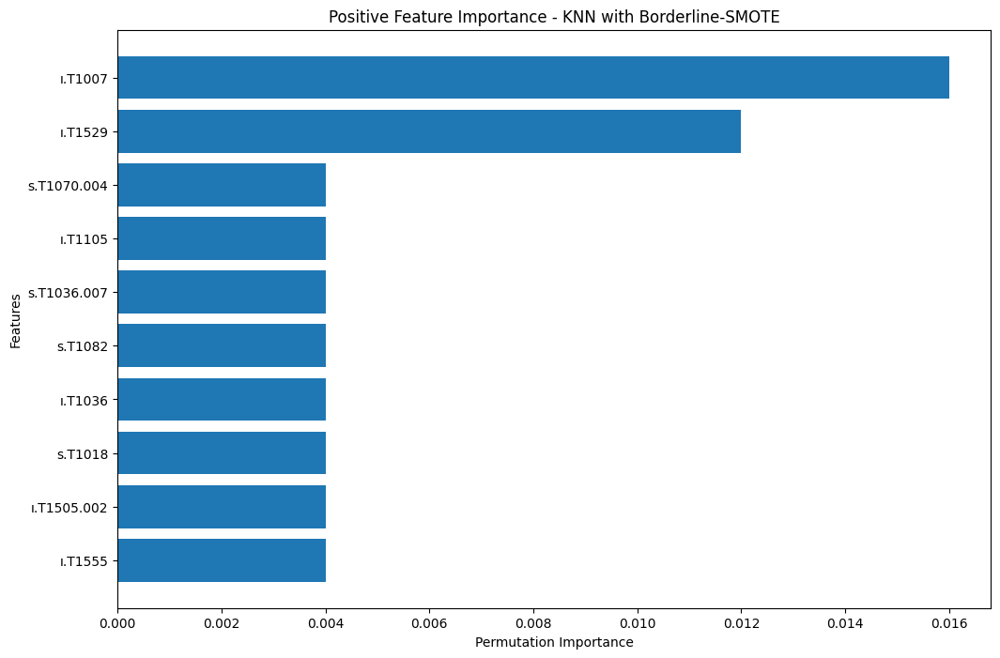


Model with Positive Feature Importance - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 20 Features - Confusion Matrix:
[[15  2]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        17
           1       0.50      0.25      0.33         8

    accuracy                           0.68        25
   macro avg       0.61      0.57      0.56        25
weighted avg       0.65      0.68      0.64        25


Model with Top 50 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [19]:
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN with Borderline-SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
positive_features = importance_df[importance_df['Importance'] > 0]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN with Borderline-SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_egitim)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_egitim)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


***`SMOTENC (SMOTE for Nominal and Continuous)`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Confusion Matrix:
[[12  5]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


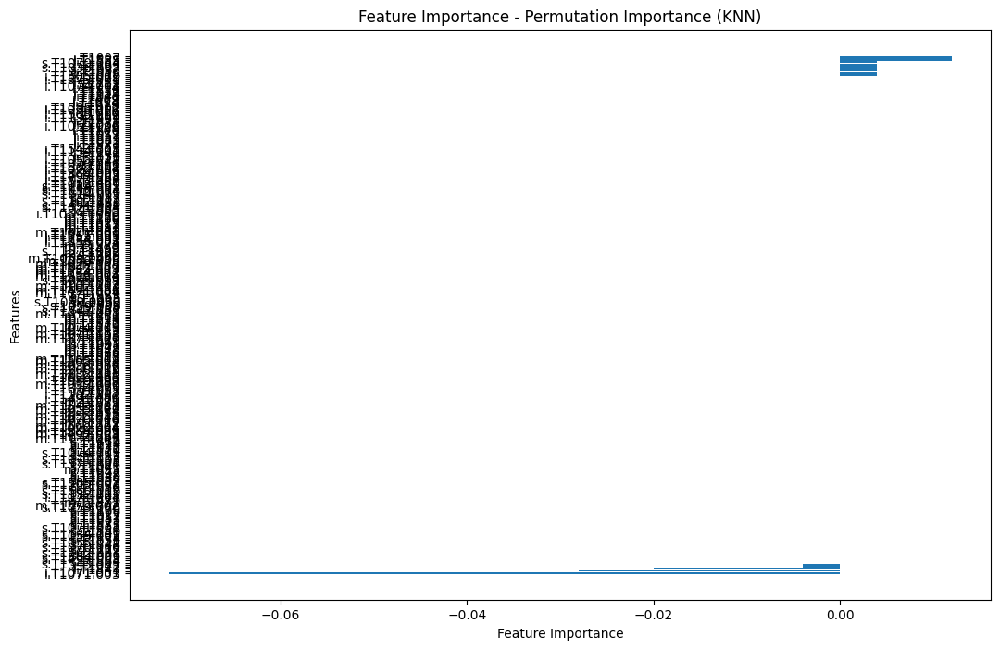

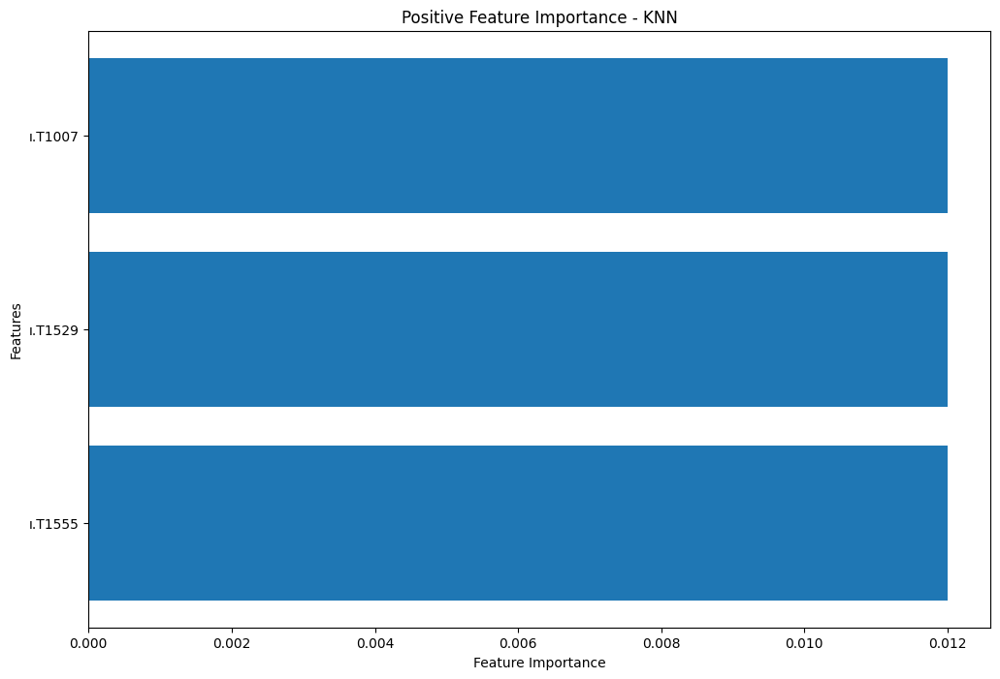


Model with Positive Feature Importance - Confusion Matrix:
[[15  2]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        17
           1       0.50      0.25      0.33         8

    accuracy                           0.68        25
   macro avg       0.61      0.57      0.56        25
weighted avg       0.65      0.68      0.64        25


Model with Top 20 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 50 Features - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [21]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation Feature Importance hesaplama
best_model = grid_search.best_estimator_
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Feature importance verisini DataFrame'e çevirme ve sıralama
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Permutation Importance (KNN)")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance belirleme
importance_threshold = 0.01
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_egitim_positive = X_egitim[:, [X.columns.get_loc(feature) for feature in positive_features_list]]
X_test_positive = X_test[:, [X.columns.get_loc(feature) for feature in positive_features_list]]

# Modeli pozitif feature importance ile yeniden eğitme
best_model_positive = KNeighborsClassifier(**grid_search.best_params_)
best_model_positive.fit(X_egitim_positive, y_egitim)
y_pred_positive = best_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_egitim_20 = X_egitim[:, [X.columns.get_loc(feature) for feature in top_20_features]]
X_test_20 = X_test[:, [X.columns.get_loc(feature) for feature in top_20_features]]
best_model_20 = KNeighborsClassifier(**grid_search.best_params_)
best_model_20.fit(X_egitim_20, y_egitim)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_egitim_50 = X_egitim[:, [X.columns.get_loc(feature) for feature in top_50_features]]
X_test_50 = X_test[:, [X.columns.get_loc(feature) for feature in top_50_features]]
best_model_50 = KNeighborsClassifier(**grid_search.best_params_)
best_model_50.fit(X_egitim_50, y_egitim)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`RandomOverSampler+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


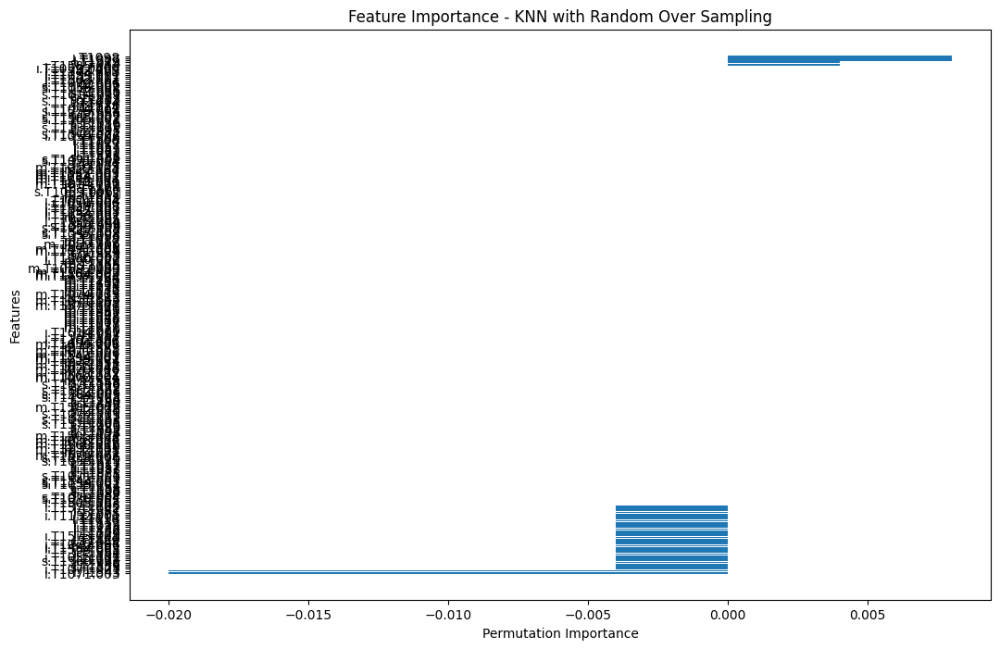

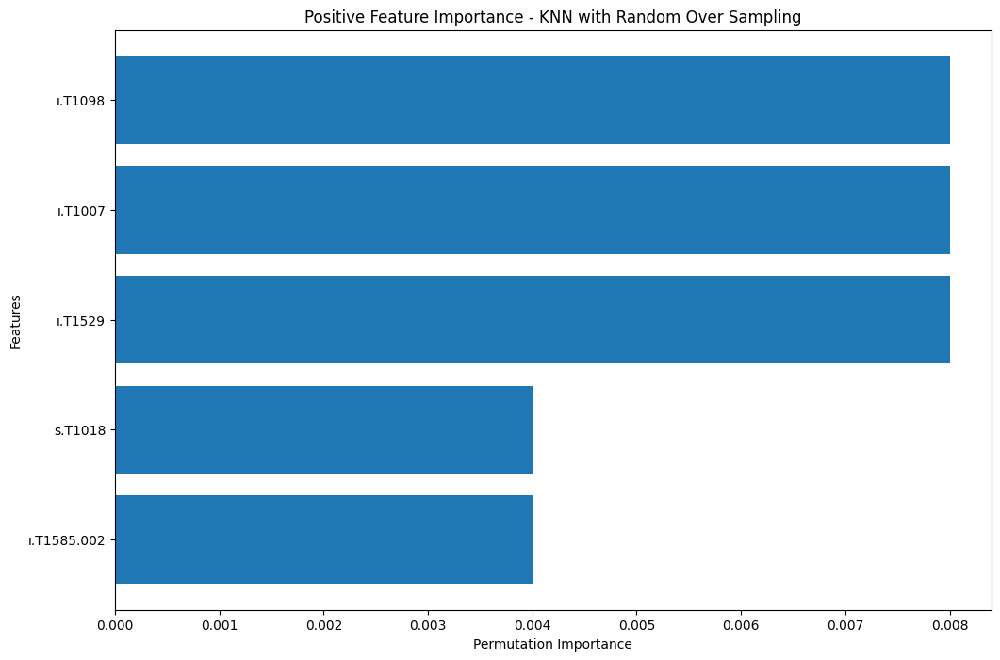


Model with Positive Feature Importance - Confusion Matrix:
[[ 1 16]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


Model with Top 20 Features - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25


Model with Top 50 Features - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [22]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosyayı okuyun ve veriyi yükleyin
try:
    df = pd.read_excel(root)
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN with Random Over Sampling")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
positive_features = importance_df[importance_df['Importance'] > 0]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN with Random Over Sampling")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_train)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_train)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_train)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Tomek Links+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Confusion Matrix:
[[ 7  5]
 [10  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


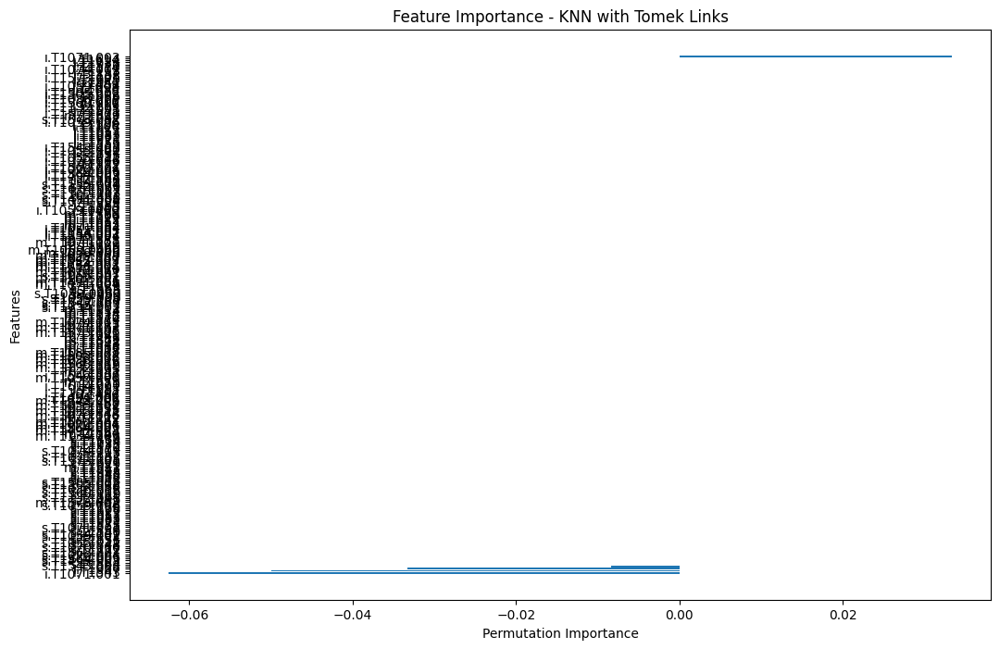

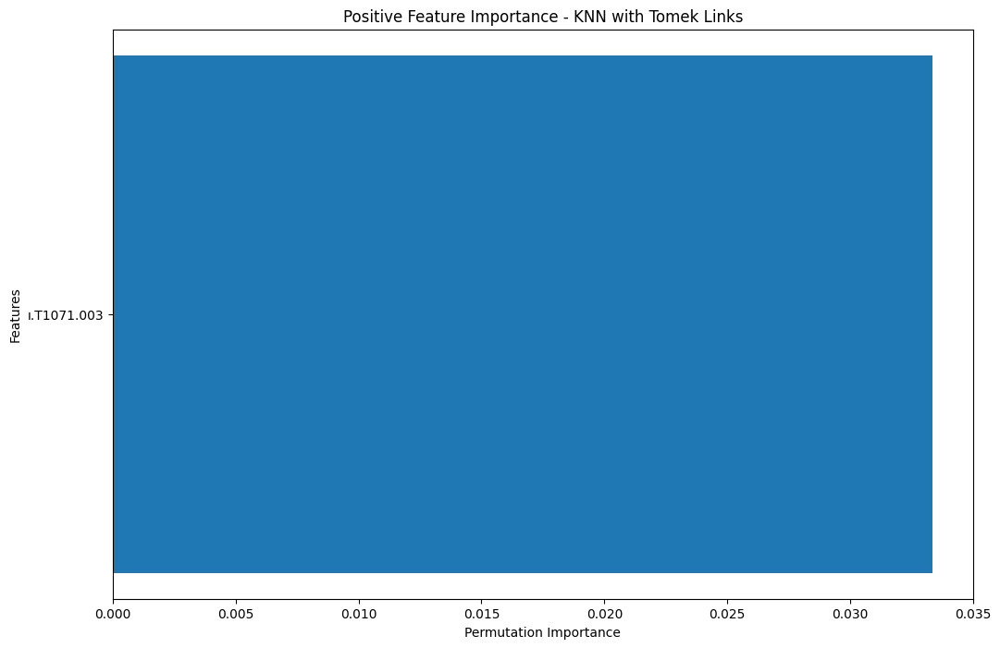


Model with Positive Feature Importance - Confusion Matrix:
[[12  0]
 [12  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        12
           1       0.00      0.00      0.00        12

    accuracy                           0.50        24
   macro avg       0.25      0.50      0.33        24
weighted avg       0.25      0.50      0.33        24


Model with Top 20 Features - Confusion Matrix:
[[11  1]
 [11  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.92      0.65        12
           1       0.50      0.08      0.14        12

    accuracy                           0.50        24
   macro avg       0.50      0.50      0.39        24
weighted avg       0.50      0.50      0.39        24


Model with Top 50 Features - Confusion Matrix:
[[11  1]
 [11  1]]

Classification Report:
              precision    recall  f1-score   support

      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve veriyi yükleyin
try:
    df = pd.read_excel(root)
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links kullanarak veri dengesizliğini düzeltme
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search ile en iyi parametreleri bulma
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN with Tomek Links")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
positive_features = importance_df[importance_df['Importance'] > 0]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN with Tomek Links")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_train)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_train)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_train)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTETomek+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 42 candidates, totalling 126 fits
Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Confusion Matrix:
[[12  1]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.92      0.69        13
           1       0.50      0.09      0.15        11

    accuracy                           0.54        24
   macro avg       0.52      0.51      0.42        24
weighted avg       0.52      0.54      0.44        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


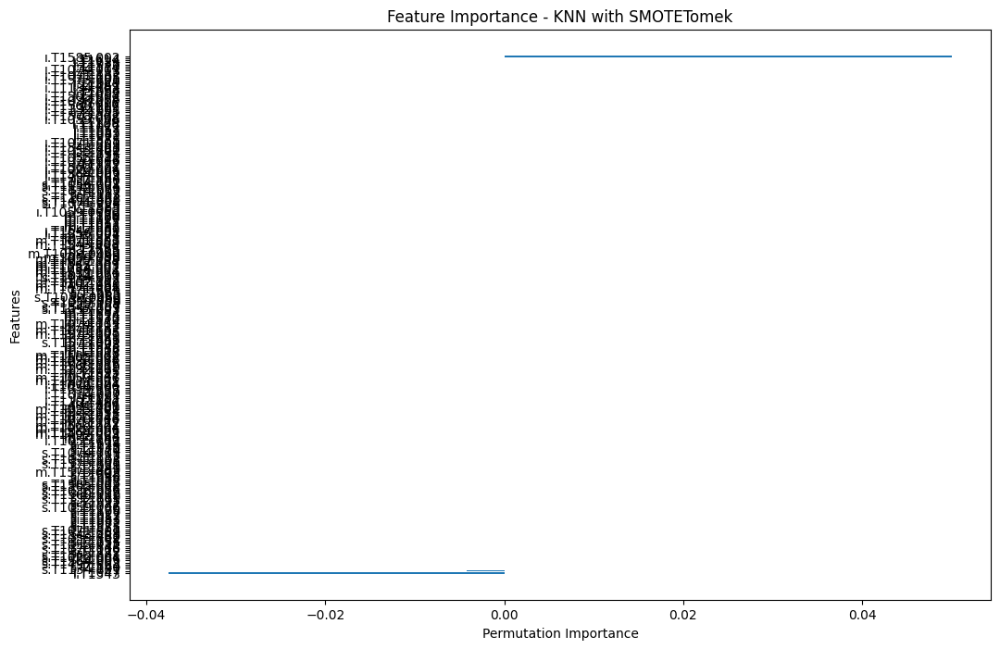

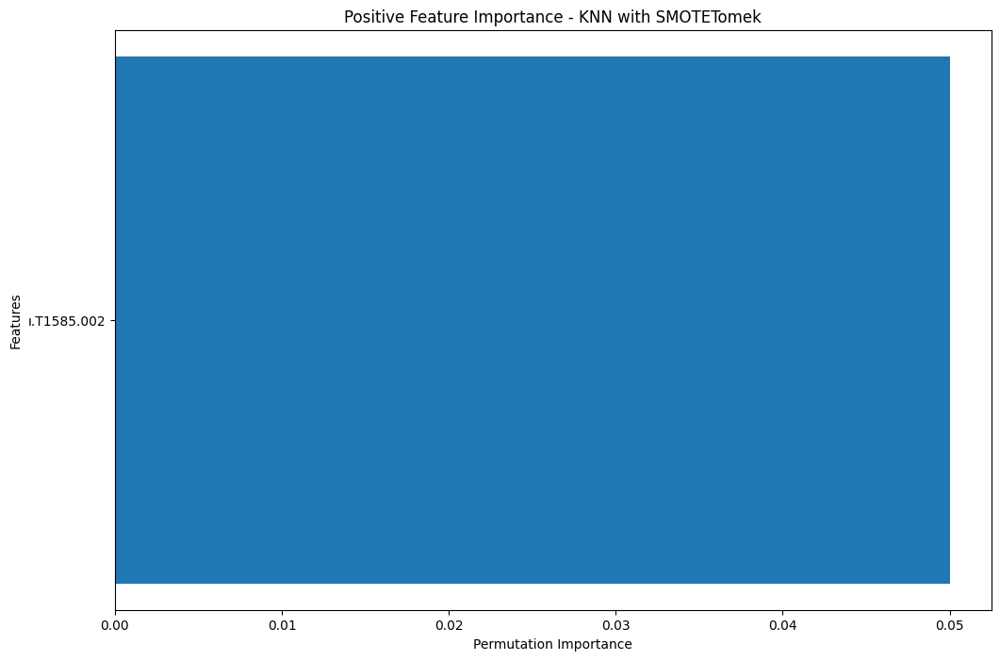


Model with Positive Feature Importance - Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       0.00      0.00      0.00        11

    accuracy                           0.54        24
   macro avg       0.27      0.50      0.35        24
weighted avg       0.29      0.54      0.38        24


Model with Top 20 Features - Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       0.00      0.00      0.00        11

    accuracy                           0.54        24
   macro avg       0.27      0.50      0.35        24
weighted avg       0.29      0.54      0.38        24


Model with Top 50 Features - Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [24]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve veriyi yükleyin
try:
    df = pd.read_excel(root)
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTETomek ile veri dengesizliğini düzeltme
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (KNN için gereklidir)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Grid Search ile en iyi parametreleri bulma
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları gösterme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - KNN with SMOTETomek")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
positive_features = importance_df[importance_df['Importance'] > 0]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - KNN with SMOTETomek")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_train[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
knn_model_positive = KNeighborsClassifier(**best_params)
knn_model_positive.fit(X_train_positive, y_train)
y_pred_positive = knn_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
knn_model_20 = KNeighborsClassifier(**best_params)
knn_model_20.fit(X_train_20, y_train)
y_pred_20 = knn_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
knn_model_50 = KNeighborsClassifier(**best_params)
knn_model_50.fit(X_train_50, y_train)
y_pred_50 = knn_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Gaussian Naive Bayes`***

# ***`shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Confusion Matrix:
[[11  3]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.79      0.63        14
           1       0.25      0.09      0.13        11

    accuracy                           0.48        25
   macro avg       0.39      0.44      0.38        25
weighted avg       0.40      0.48      0.41        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


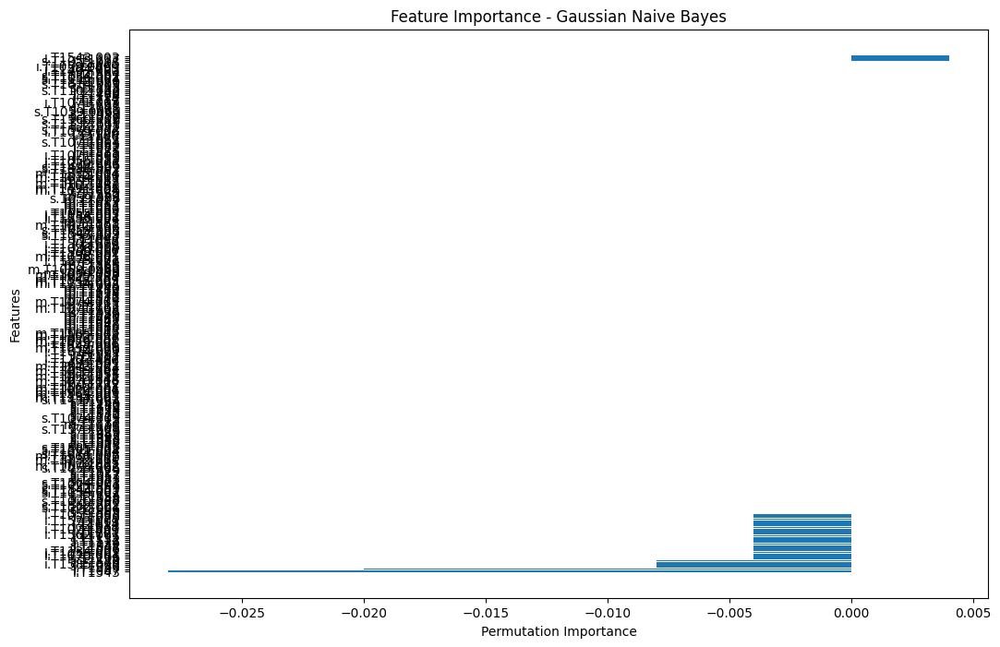

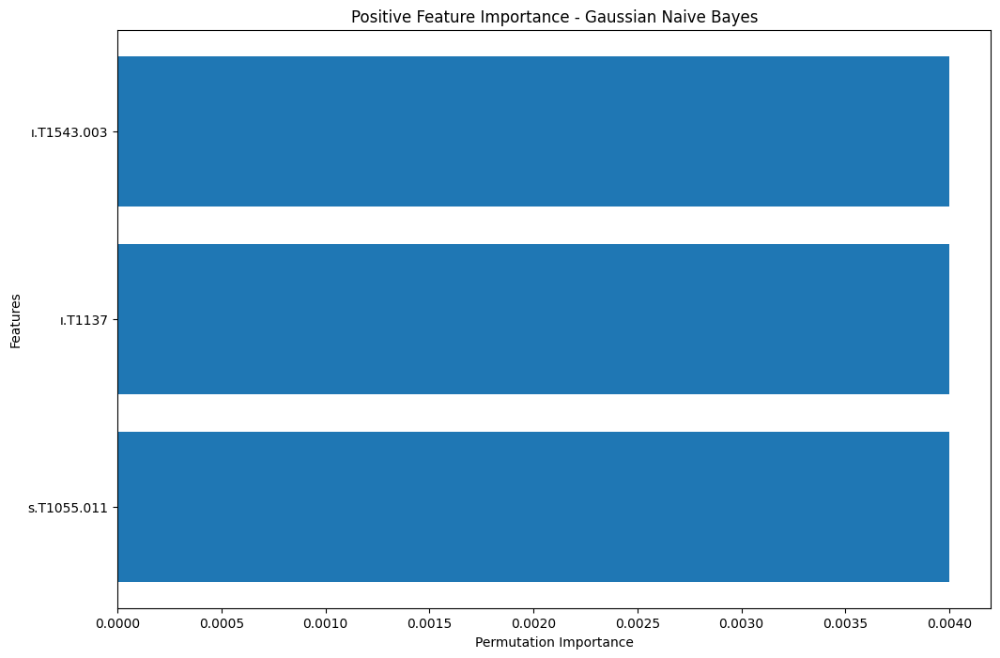


Model with Positive Feature Importance - Confusion Matrix:
[[14  0]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        14
           1       1.00      0.09      0.17        11

    accuracy                           0.60        25
   macro avg       0.79      0.55      0.45        25
weighted avg       0.77      0.60      0.49        25



In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veriyi yükleyin
try:
    df = pd.read_excel(root)  # 'root' yerine veri setinizin dosya yolunu yazın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Gaussian Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Gaussian Naive Bayes modelini oluştur
gnb_model = GaussianNB()

# Modeli eğit
gnb_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendir
y_pred = gnb_model.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation Importance ile özellik önemi hesapla
perm_importance = permutation_importance(gnb_model, X_test, y_test, n_repeats=10, random_state=42)

# Özellik önemlerini bir DataFrame olarak göster
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralı olarak göster
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
positive_features = importance_df[importance_df['Importance'] > 0]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))


# ***`shap2`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[11  3]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.79      0.63        14
           1       0.25      0.09      0.13        11

    accuracy                           0.48        25
   macro avg       0.39      0.44      0.38        25
weighted avg       0.40      0.48      0.41        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


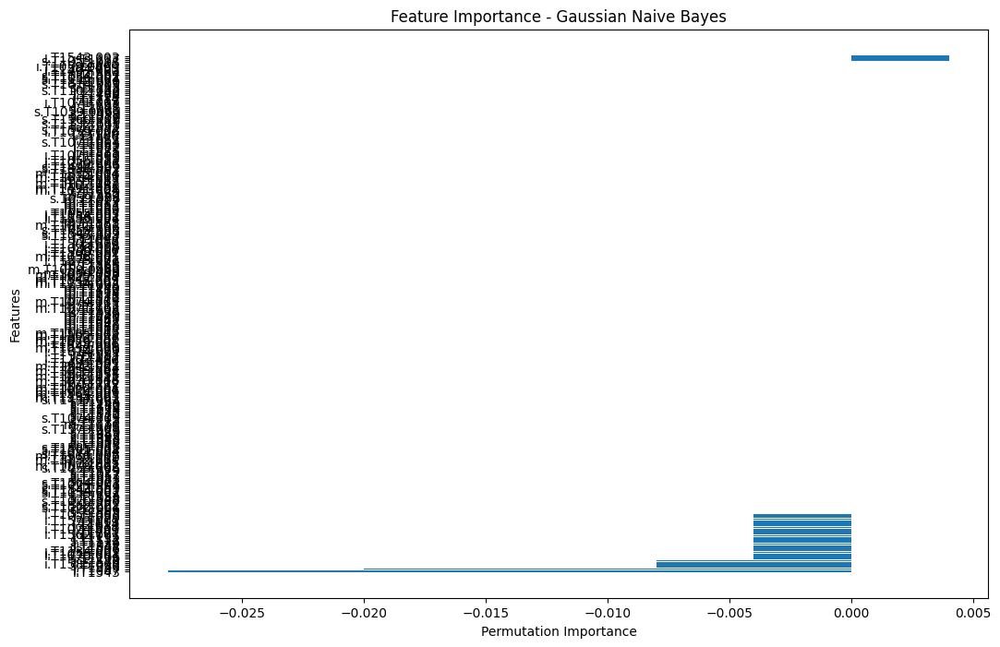

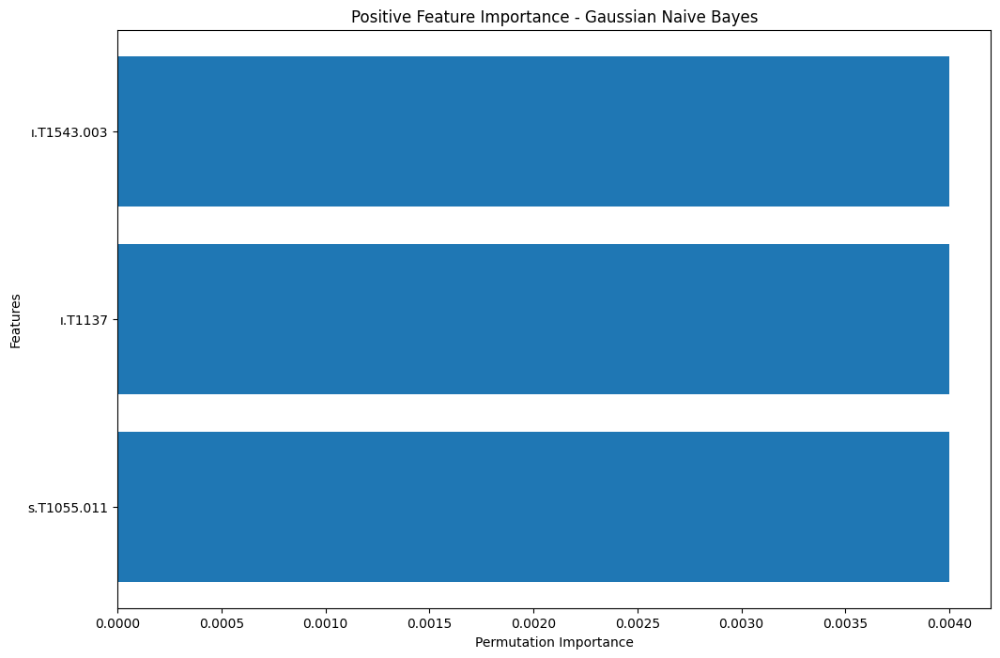


Model with Positive Feature Importance - Confusion Matrix:
[[14  0]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        14
           1       1.00      0.09      0.17        11

    accuracy                           0.60        25
   macro avg       0.79      0.55      0.45        25
weighted avg       0.77      0.60      0.49        25


Model with Top 20 Features - Confusion Matrix:
[[14  0]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      1.00      0.74        14
           1       1.00      0.09      0.17        11

    accuracy                           0.60        25
   macro avg       0.79      0.55      0.45        25
weighted avg       0.77      0.60      0.49        25


Model with Top 50 Features - Confusion Matrix:
[[14  0]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veri kümesini yükleyin
try:
    df = pd.read_excel(root)  # 'root' yerine veri setinizin dosya yolunu yazın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`smote+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.50      0.12      0.20         8

    accuracy                           0.68        25
   macro avg       0.60      0.53      0.50        25
weighted avg       0.63      0.68      0.61        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


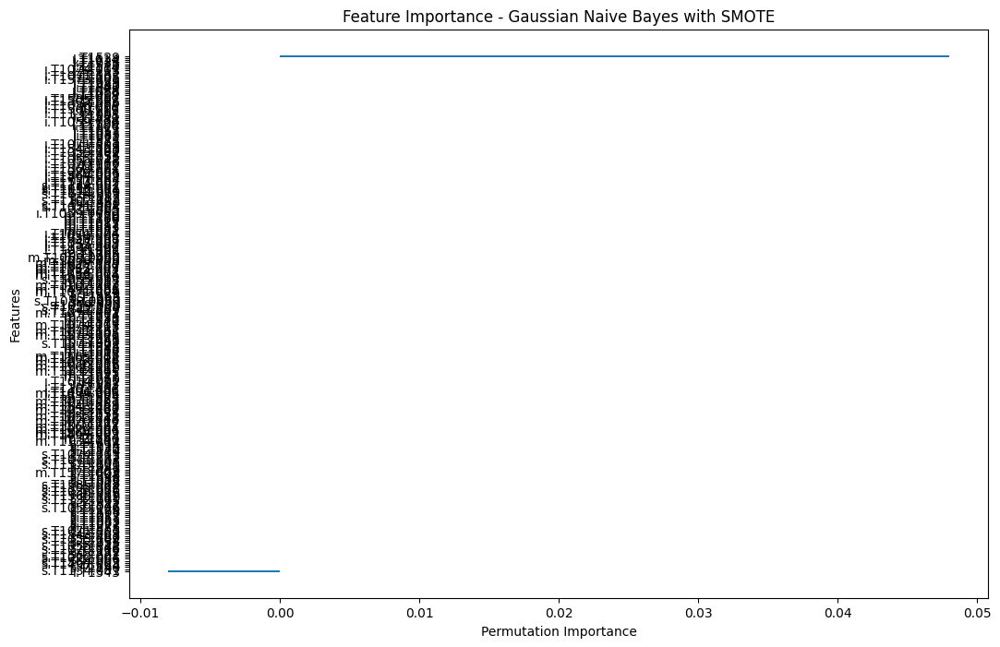

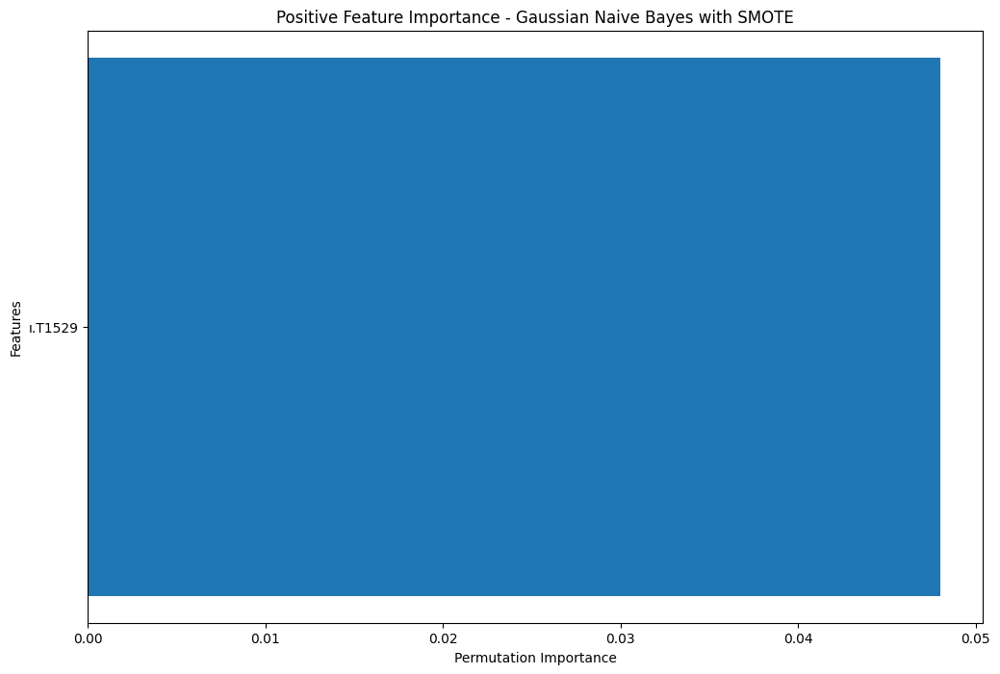


Model with Positive Feature Importance - Confusion Matrix:
[[17  0]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        17
           1       1.00      0.12      0.22         8

    accuracy                           0.72        25
   macro avg       0.85      0.56      0.53        25
weighted avg       0.80      0.72      0.64        25


Model with Top 20 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 50 Features - Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [27]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # root yerine kendi dosya yolunuzu yazın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Borderline-SMOTE+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.50      0.12      0.20         8

    accuracy                           0.68        25
   macro avg       0.60      0.53      0.50        25
weighted avg       0.63      0.68      0.61        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


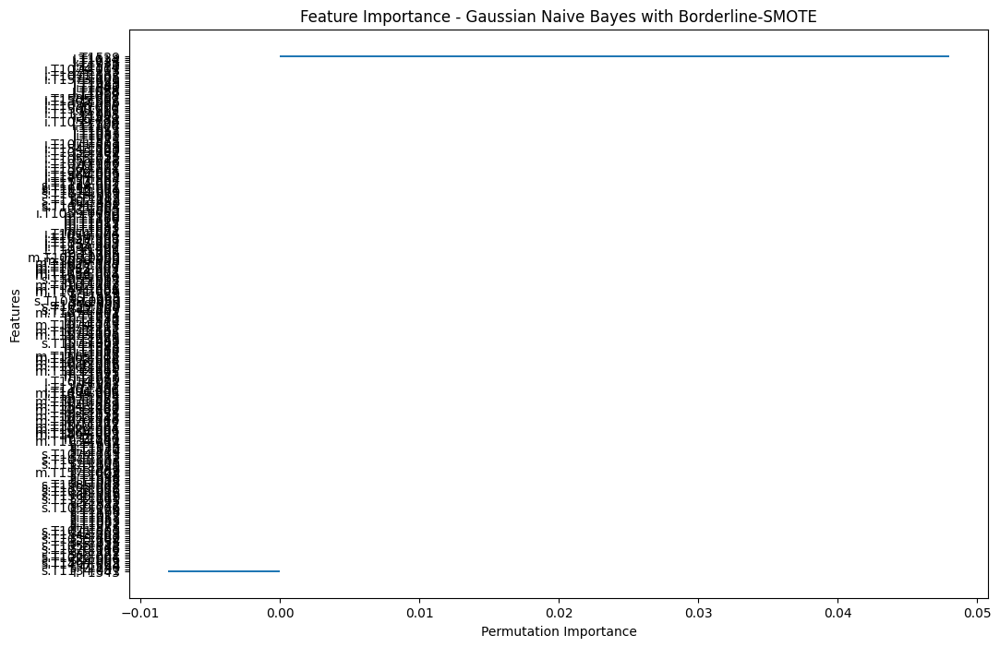

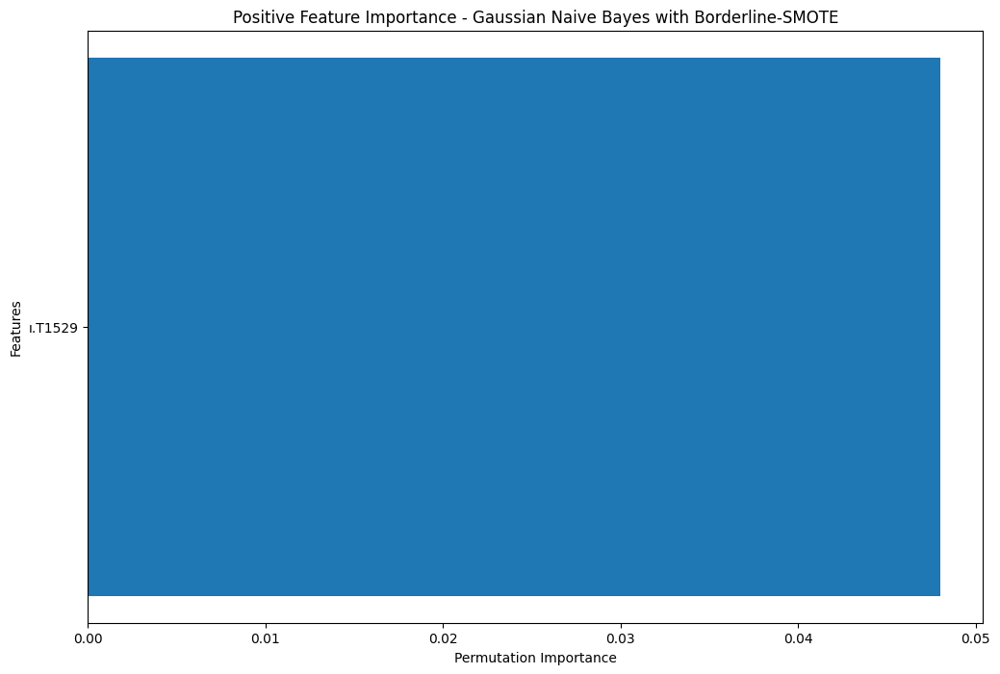


Model with Positive Feature Importance - Confusion Matrix:
[[17  0]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        17
           1       1.00      0.12      0.22         8

    accuracy                           0.72        25
   macro avg       0.85      0.56      0.53        25
weighted avg       0.80      0.72      0.64        25


Model with Top 20 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 50 Features - Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [28]:
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # root yerine kendi dosya yolunuzu yazın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with Borderline-SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with Borderline-SMOTE")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTENC+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.50      0.12      0.20         8

    accuracy                           0.68        25
   macro avg       0.60      0.53      0.50        25
weighted avg       0.63      0.68      0.61        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


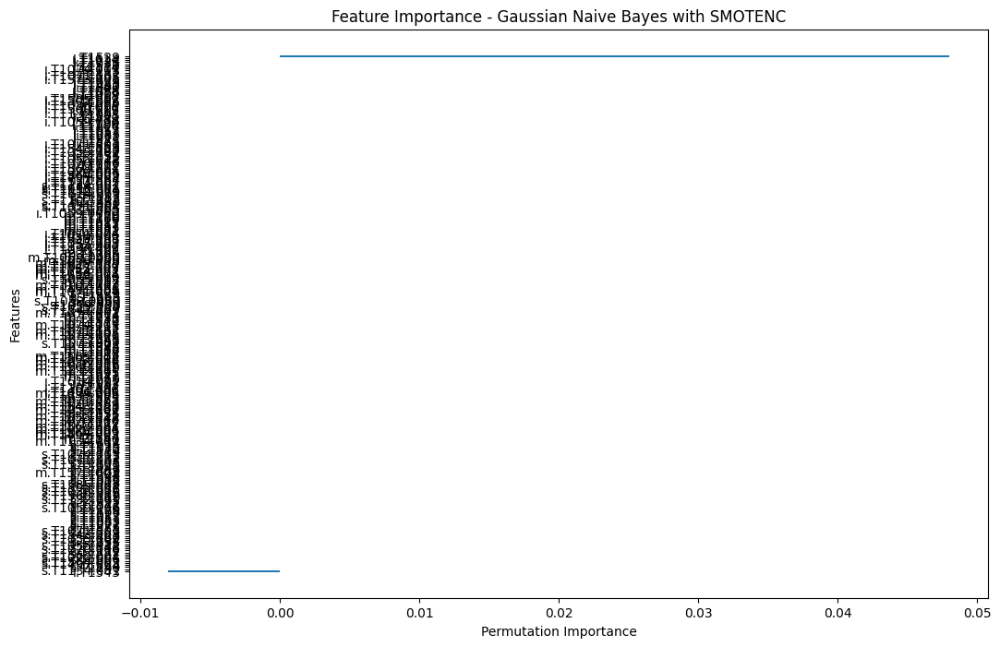

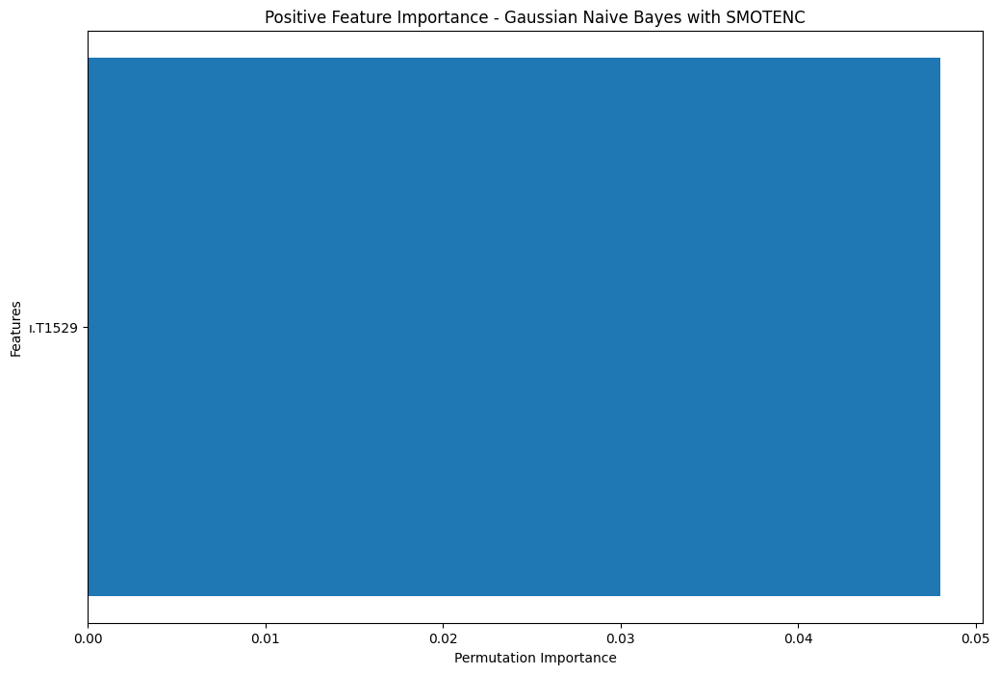


Model with Positive Feature Importance - Confusion Matrix:
[[17  0]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83        17
           1       1.00      0.12      0.22         8

    accuracy                           0.72        25
   macro avg       0.85      0.56      0.53        25
weighted avg       0.80      0.72      0.64        25


Model with Top 20 Features - Confusion Matrix:
[[14  3]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25


Model with Top 50 Features - Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

      

In [29]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # 'root' yerine kendi dosya yolunuzu yazın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Kategorik özelliklerin indekslerini belirtin
categorical_features = [0, 2]  # Kendi veri kümenize göre güncelleyin

# SMOTENC kullanarak veri artırma
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with SMOTENC")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with SMOTENC")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`RandomOverSampler+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[16  1]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.50      0.12      0.20         8

    accuracy                           0.68        25
   macro avg       0.60      0.53      0.50        25
weighted avg       0.63      0.68      0.61        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


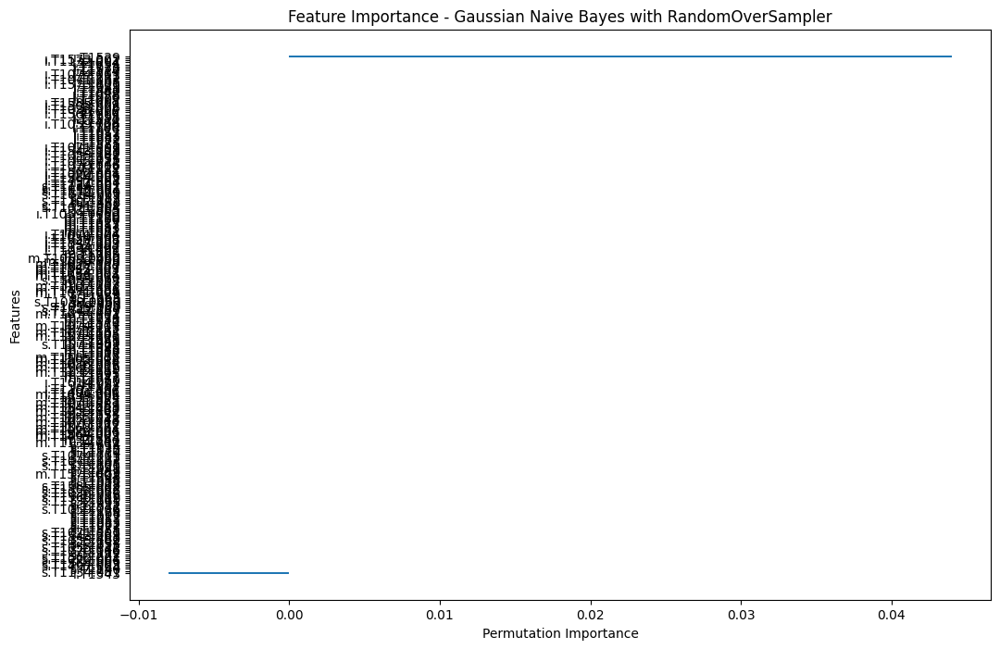

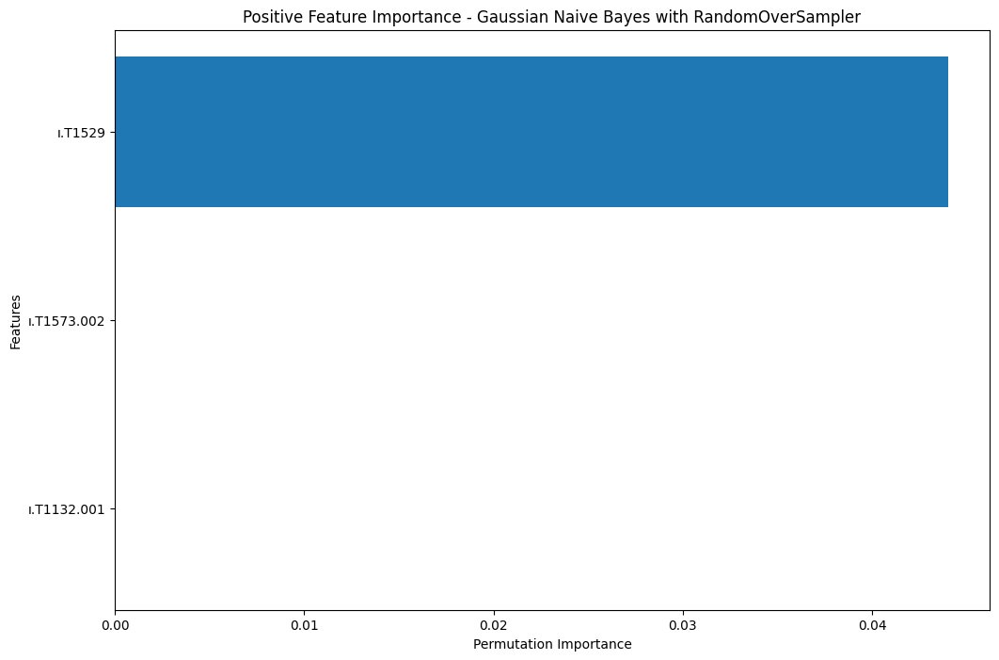


Model with Positive Feature Importance - Confusion Matrix:
[[ 1 16]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


Model with Top 20 Features - Confusion Matrix:
[[ 1 16]
 [ 0  8]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


Model with Top 50 Features - Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

      

In [30]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # 'root' yerine kendi dosya yolunuzu girin
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with RandomOverSampler")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with RandomOverSampler")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Tomek Links+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[10  2]
 [12  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.83      0.59        12
           1       0.00      0.00      0.00        12

    accuracy                           0.42        24
   macro avg       0.23      0.42      0.29        24
weighted avg       0.23      0.42      0.29        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


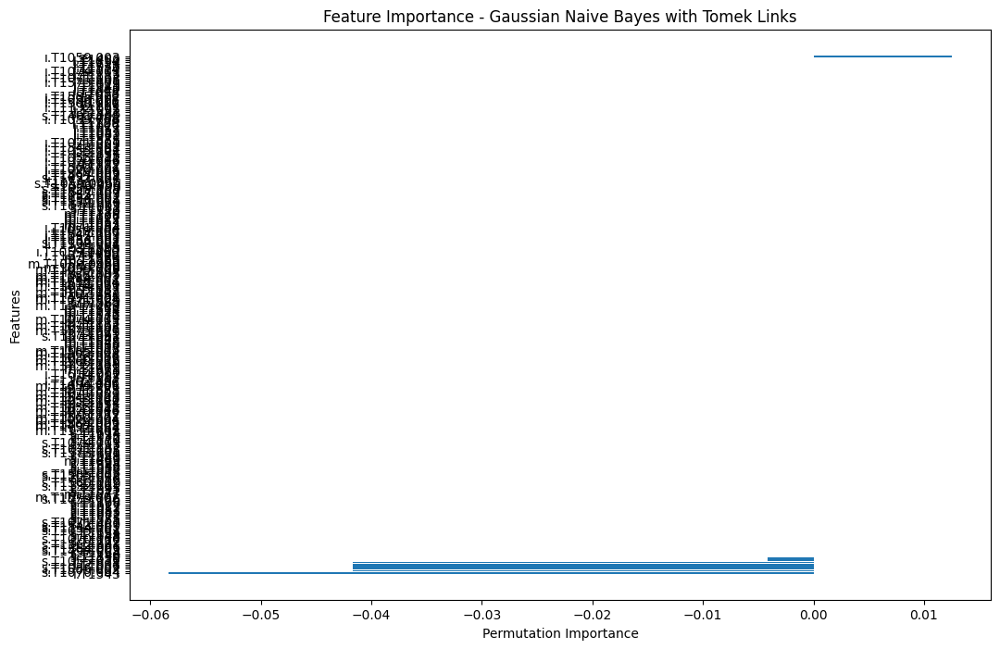

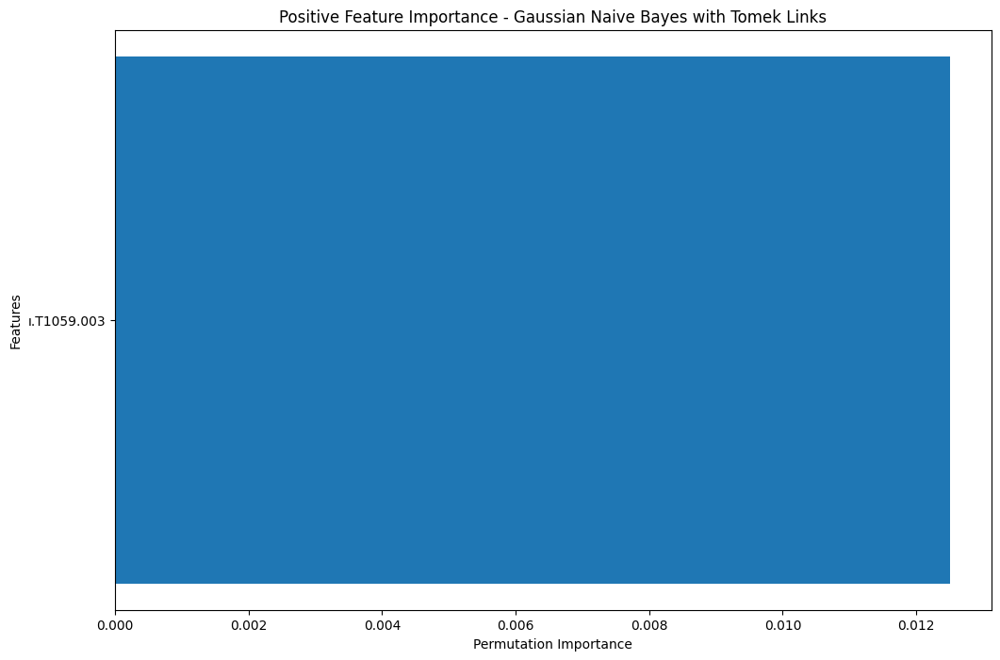


Model with Positive Feature Importance - Confusion Matrix:
[[12  0]
 [11  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69        12
           1       1.00      0.08      0.15        12

    accuracy                           0.54        24
   macro avg       0.76      0.54      0.42        24
weighted avg       0.76      0.54      0.42        24


Model with Top 20 Features - Confusion Matrix:
[[12  0]
 [11  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      1.00      0.69        12
           1       1.00      0.08      0.15        12

    accuracy                           0.54        24
   macro avg       0.76      0.54      0.42        24
weighted avg       0.76      0.54      0.42        24


Model with Top 50 Features - Confusion Matrix:
[[ 1 11]
 [ 2 10]]

Classification Report:
              precision    recall  f1-score   support

      

In [31]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)  # 'root' yerine kendi dosya yolunuzu girin
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links kullanarak veri dengesini düzeltme
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Verileri eğitim ve test setlerine ayırma
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search ile en iyi hiperparametreleri bulma
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahmin yapma
y_pred = grid_search.predict(X_test)

# Model performansını değerlendirme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': df.drop('Malicious', axis=1).columns,
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with Tomek Links")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için bir eşik belirleme (örneğin 0'dan büyük importance değerleri)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with Tomek Links")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
X_train_positive = X_egitim[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]
X_test_positive = X_test[:, importance_df.index[importance_df['Feature'].isin(positive_features_list)]]

# Modeli pozitif feature importance ile yeniden eğitme
gnb_model_positive = GaussianNB()
gnb_model_positive.fit(X_train_positive, y_egitim)
y_pred_positive = gnb_model_positive.predict(X_test_positive)

print("\nModel with Positive Feature Importance - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_positive))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, importance_df.index[:20]]
X_test_20 = X_test[:, importance_df.index[:20]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, importance_df.index[:50]]
X_test_50 = X_test[:, importance_df.index[:50]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTETomek+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Best parameters found:  {'var_smoothing': 1e-09}
Confusion Matrix:
[[11  2]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.85      0.63        13
           1       0.00      0.00      0.00        11

    accuracy                           0.46        24
   macro avg       0.25      0.42      0.31        24
weighted avg       0.27      0.46      0.34        24



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


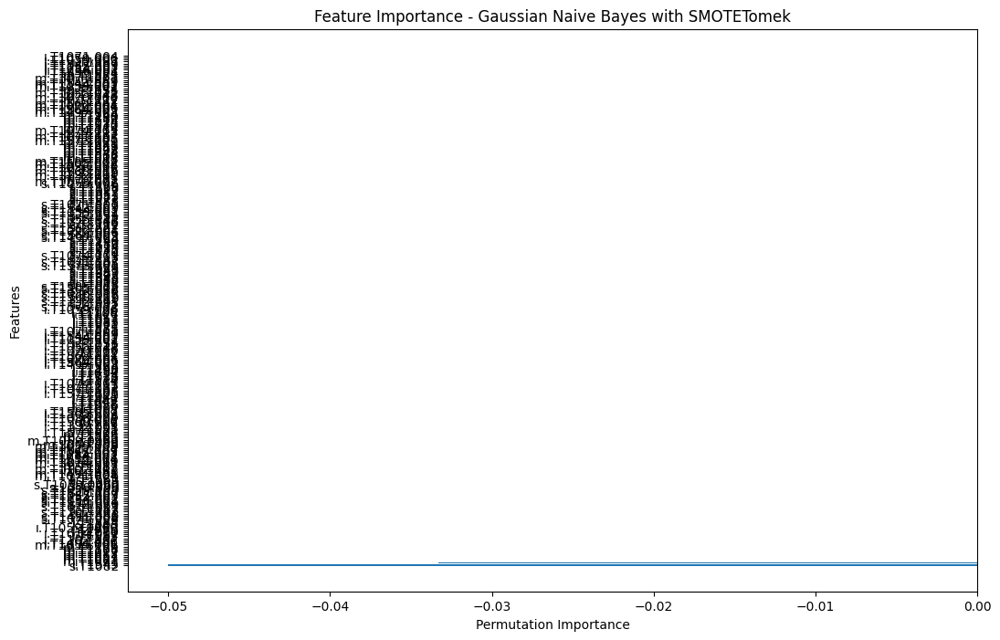

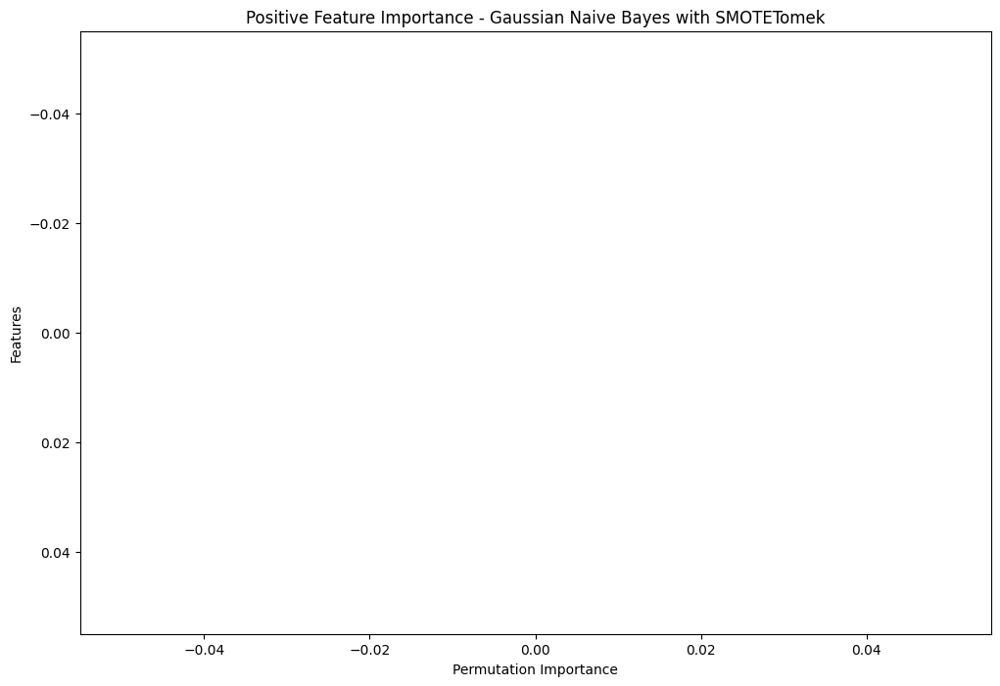

No positive features were selected.

Model with Top 20 Features - Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       0.00      0.00      0.00        11

    accuracy                           0.54        24
   macro avg       0.27      0.50      0.35        24
weighted avg       0.29      0.54      0.38        24


Model with Top 50 Features - Confusion Matrix:
[[13  0]
 [11  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        13
           1       0.00      0.00      0.00        11

    accuracy                           0.54        24
   macro avg       0.27      0.50      0.35        24
weighted avg       0.29      0.54      0.38        24



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [34]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosyayı okuyun
try:
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununu yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununu yazmalısınız

# SMOTETomek kullanarak veri dengesizliğini düzeltme
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayırma
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme (Naive Bayes için gerekli değil, ancak diğer modellerle birlikte kullanıldığında faydalı olabilir)
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid Search ile en iyi hiperparametreleri bulma
grid_search = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri gösterme
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahmin yapma
y_pred = grid_search.predict(X_test)

# Model performansını değerlendirme
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance hesaplama (Permutation Importance)
perm_importance = permutation_importance(grid_search.best_estimator_, X_test, y_test, n_repeats=10, random_state=42)

# Permutation importance değerlerini bir DataFrame'e çevirme
importance_df = pd.DataFrame({
    'Feature': X.columns,  # Doğru feature isimlerini kullanma
    'Importance': perm_importance.importances_mean
})

# Özellik önemlerini sıralama ve bar grafiği ile gösterme
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Bar grafiği ile feature importance gösterme
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Gaussian Naive Bayes with SMOTETomek")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance belirleme (eşik değeri 0)
importance_threshold = 0
positive_features = importance_df[importance_df['Importance'] > importance_threshold]

# Pozitif feature importance bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Positive Feature Importance - Gaussian Naive Bayes with SMOTETomek")
plt.gca().invert_yaxis()
plt.show()

# Pozitif feature importance ile modeli yeniden eğitmek için listeyi oluşturma
positive_features_list = positive_features['Feature'].tolist()

# Pozitif feature importance ile eğitim ve test verileri oluşturma
positive_feature_indices = [X.columns.get_loc(feature) for feature in positive_features_list]  # Feature'ları indexe çevirme
if len(positive_feature_indices) == 0:
    print("No positive features were selected.")
else:
    X_train_positive = X_egitim[:, positive_feature_indices]
    X_test_positive = X_test[:, positive_feature_indices]

    # Modeli pozitif feature importance ile yeniden eğitme
    gnb_model_positive = GaussianNB()
    gnb_model_positive.fit(X_train_positive, y_egitim)
    y_pred_positive = gnb_model_positive.predict(X_test_positive)

    print("\nModel with Positive Feature Importance - Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_positive))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_positive))

# En önemli 20 ve 50 özellikleri seçme
top_20_features = importance_df['Feature'].iloc[:20]
top_50_features = importance_df['Feature'].iloc[:50]

# En önemli 20 özellik ile modeli yeniden eğitme
X_train_20 = X_egitim[:, [X.columns.get_loc(feature) for feature in top_20_features]]
X_test_20 = X_test[:, [X.columns.get_loc(feature) for feature in top_20_features]]
gnb_model_20 = GaussianNB()
gnb_model_20.fit(X_train_20, y_egitim)
y_pred_20 = gnb_model_20.predict(X_test_20)

print("\nModel with Top 20 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 özellik ile modeli yeniden eğitme
X_train_50 = X_egitim[:, [X.columns.get_loc(feature) for feature in top_50_features]]
X_test_50 = X_test[:, [X.columns.get_loc(feature) for feature in top_50_features]]
gnb_model_50 = GaussianNB()
gnb_model_50.fit(X_train_50, y_egitim)
y_pred_50 = gnb_model_50.predict(X_test_50)

print("\nModel with Top 50 Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Random Forest`***

# ***`Gini Importance`***

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
412 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': False, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
[[ 1 13]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.12        14
           1       0.41      0.82      0.55        11

    accuracy                           0.40        25
   macro avg       0.37      0.44      0.33        25
weighted avg       0.37      0.40      0.31        25



<ipython-input-35-75b0af0fe460>:50: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


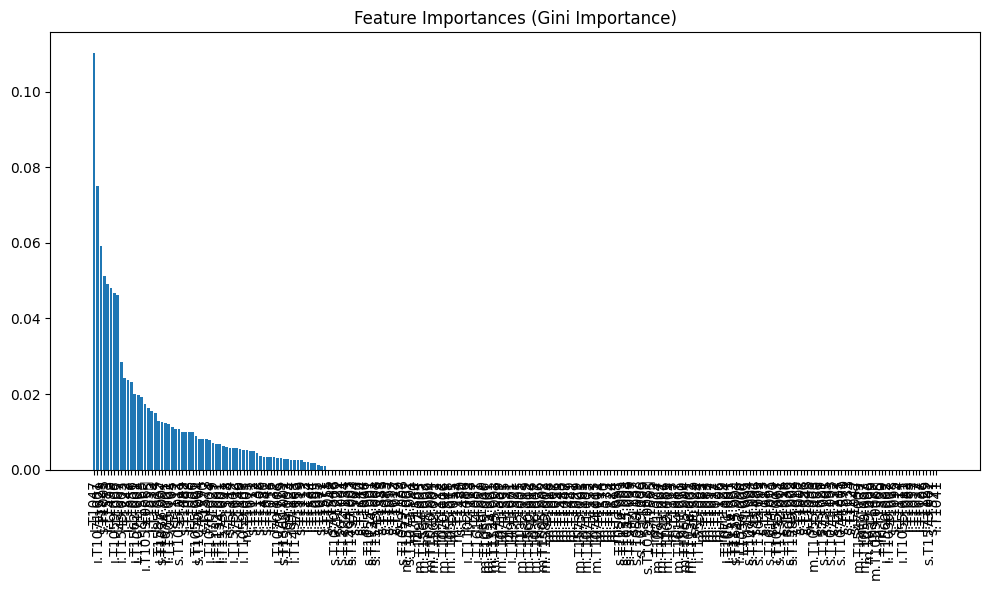

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
388 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[10  4]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[9 5]
 [8 3]]
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        14
           1       0.38      0.27      0.32        11

    accuracy                           0.48        25
   macro avg       0.45      0.46      0.45        25
weighted avg       0.46      0.48      0.46        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
304 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


# ***SMOTE***

In [36]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
[[11  6]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.14      0.12      0.13         8

    accuracy                           0.48        25
   macro avg       0.38      0.39      0.38        25
weighted avg       0.46      0.48      0.47        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
306 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB


<ipython-input-37-9b209f43eaf4>:39: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


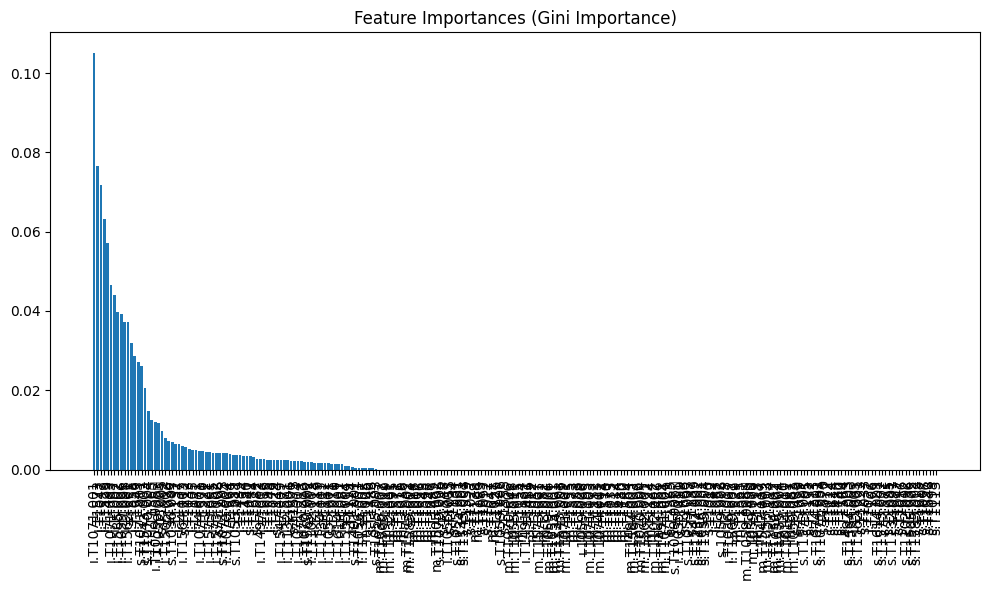


Results for Top 20 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25


Results for Top 50 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25



In [37]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Random Forest Modeli
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance (Gini importance)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seçip yeniden eğitim yapma
top_20_features = X_train.columns[indices[:20]].tolist()
top_50_features = X_train.columns[indices[:50]].tolist()

def retrain_and_evaluate(features, name):
    X_train_new = X_train[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    rf.fit(X_train_new, y_train)

    # Tahmin yap
    y_pred = rf.predict(X_test_new)

    # Sonuçları yazdır
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

# İlk 20 ve ilk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


***`Borderline-SMOTE`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
368 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
[[12  5]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.17      0.12      0.14         8

    accuracy                           0.52        25
   macro avg       0.40      0.42      0.40        25
weighted avg       0.48      0.52      0.50        25



<ipython-input-38-aaf7b0d31543>:63: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


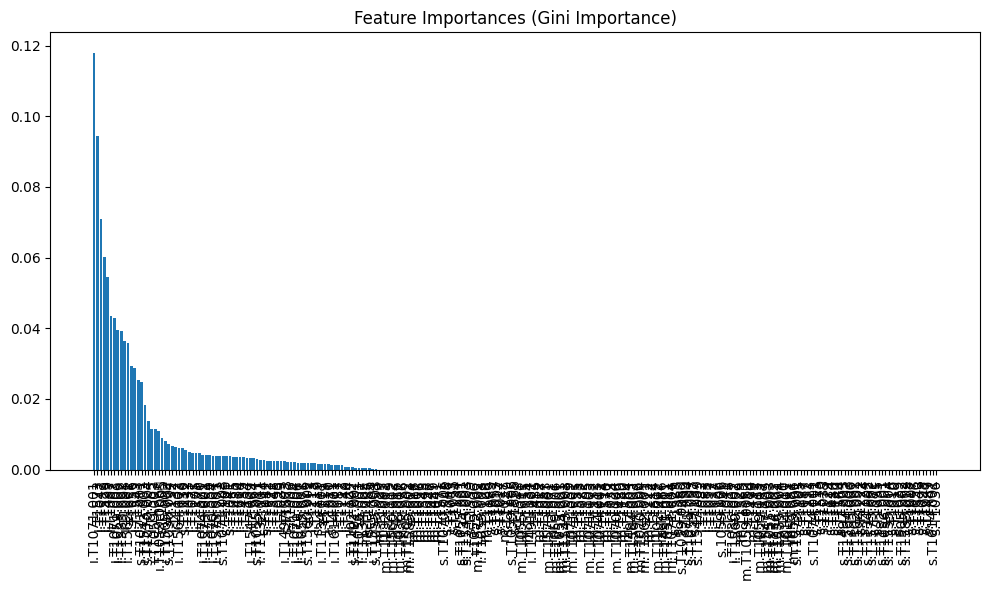

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
331 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[12  5]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[12  5]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
355 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [38]:
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


***`SMOTENC (SMOTE for Nominal and Continuous)`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
371 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
[[11  6]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.14      0.12      0.13         8

    accuracy                           0.48        25
   macro avg       0.38      0.39      0.38        25
weighted avg       0.46      0.48      0.47        25



<ipython-input-39-8ca129b407b1>:64: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


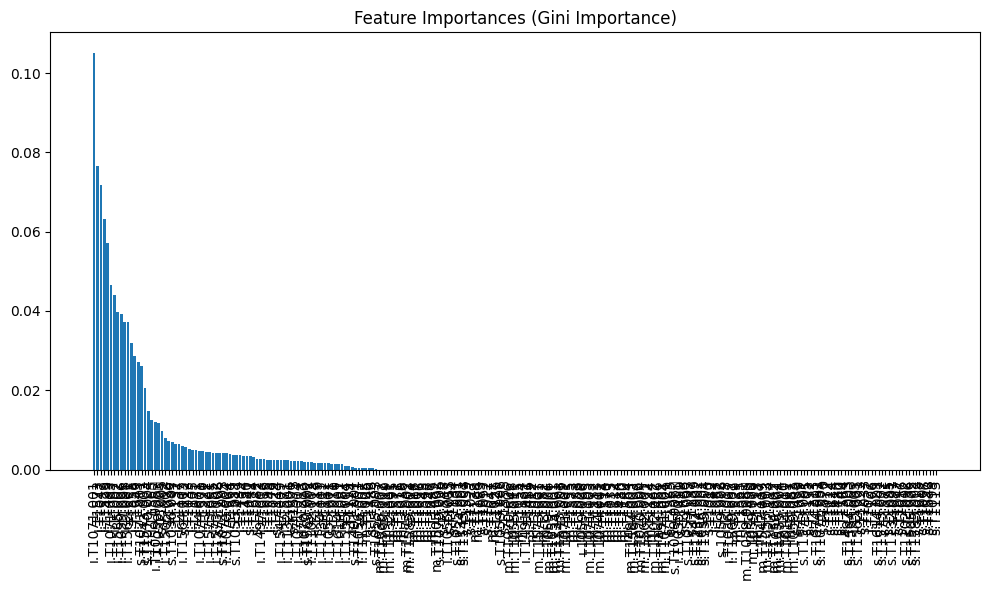

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
465 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
342 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [39]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


***`RandomOverSampler`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
332 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Confusion Matrix:
[[11  6]
 [ 7  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.14      0.12      0.13         8

    accuracy                           0.48        25
   macro avg       0.38      0.39      0.38        25
weighted avg       0.46      0.48      0.47        25



<ipython-input-40-c9796201d841>:63: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


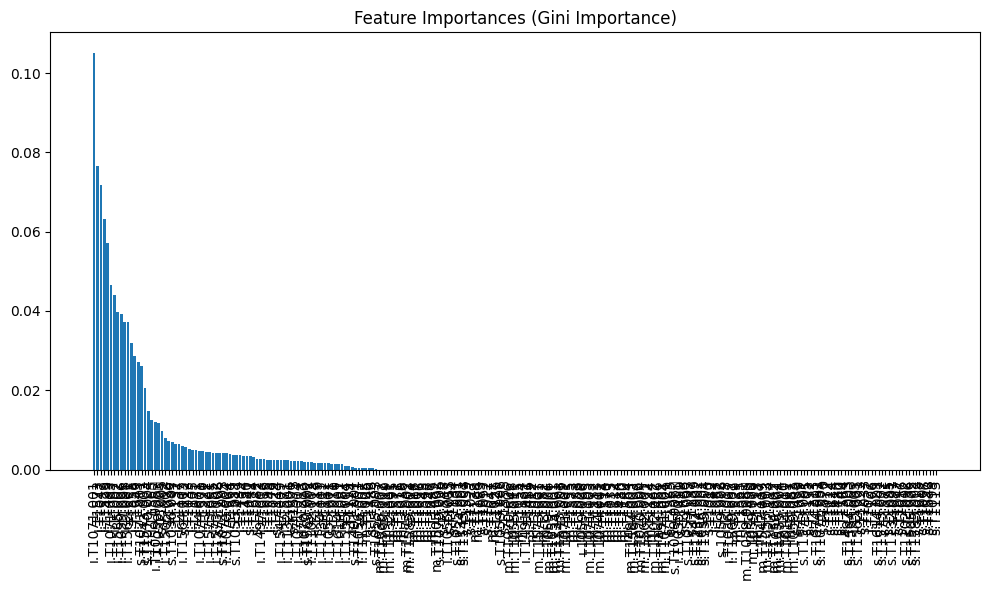

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
499 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[11  6]
 [ 6  2]]
              precision    recall  f1-score   support

           0       0.65      0.65      0.65        17
           1       0.25      0.25      0.25         8

    accuracy                           0.52        25
   macro avg       0.45      0.45      0.45        25
weighted avg       0.52      0.52      0.52        25



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
275 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [40]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Random OverSampling ile veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


***`Tomek Links`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
423 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Confusion Matrix:
[[ 7  5]
 [10  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24



<ipython-input-41-64639d8783d2>:63: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


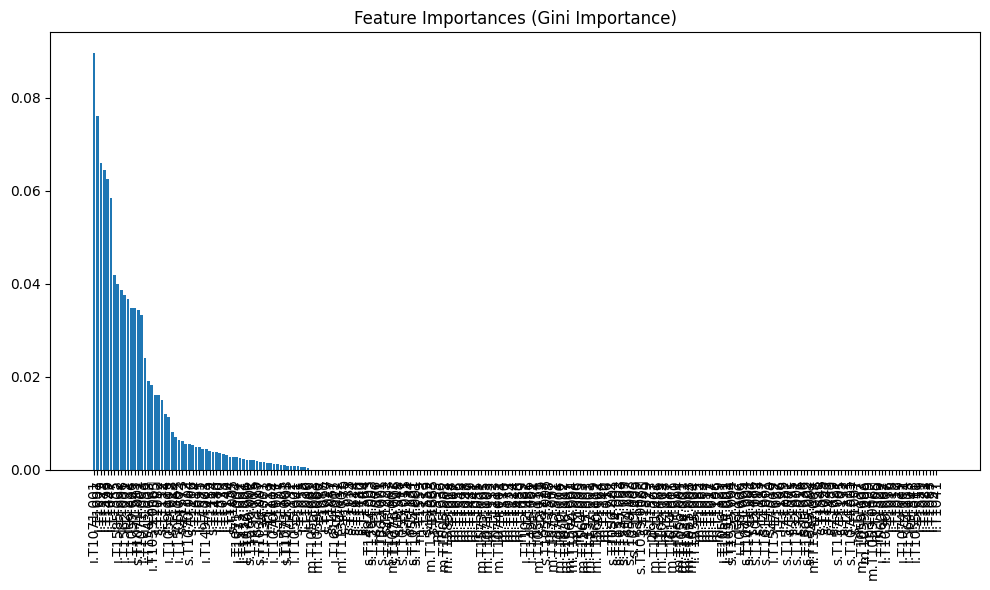

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
172 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[7 5]
 [9 3]]
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.38      0.25      0.30        12

    accuracy                           0.42        24
   macro avg       0.41      0.42      0.40        24
weighted avg       0.41      0.42      0.40        24

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[ 7  5]
 [10  2]]
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
309 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [41]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links ile veri dengeleme (under-sampling)
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
343 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

Best parameters found:  {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Confusion Matrix:
[[10  3]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24



<ipython-input-42-e43fce96931f>:63: UserWarning: Glyph 9 (	) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


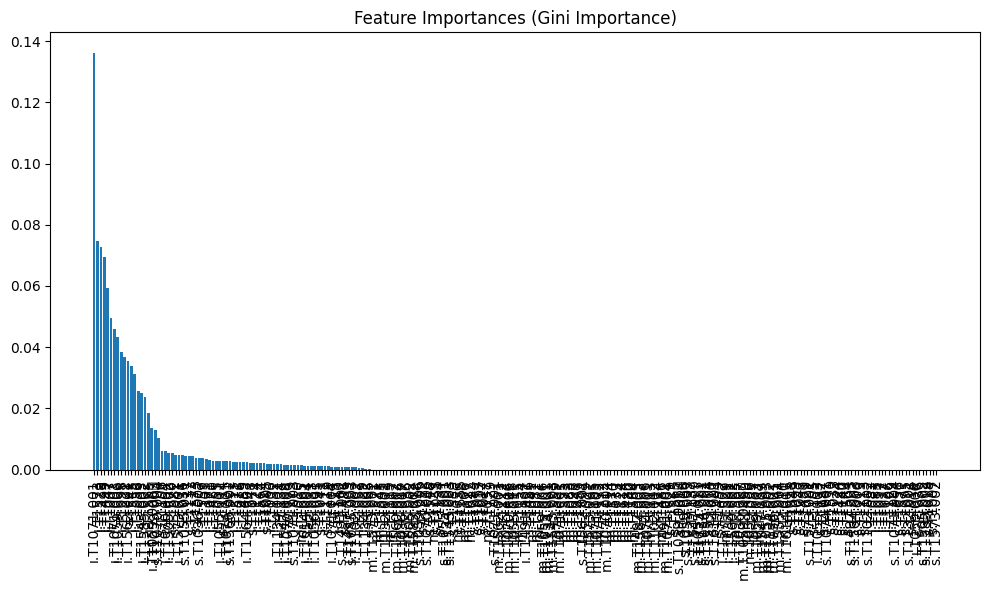

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
328 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti


Results for Top 20 Gini Importance Features:
[[10  3]
 [ 9  2]]
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24

Fitting 3 folds for each of 648 candidates, totalling 1944 fits

Results for Top 50 Gini Importance Features:
[[10  3]
 [ 9  2]]
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24



/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
648 fits failed out of a total of 1944.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
298 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/uti

In [42]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTETomek ile veri artırma ve dengeleme
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Gini Importance (MDI) hesaplama
importances = grid_search.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Feature importance'ları görselleştir
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Gini Importance)")
plt.bar(range(X_egitim.shape[1]), importances[indices], align="center")
plt.xticks(range(X_egitim.shape[1]), X_egitim.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# İlk 20 ve ilk 50 feature'ları seç
top_20_features = X_egitim.columns[indices[:20]].tolist()
top_50_features = X_egitim.columns[indices[:50]].tolist()

# Yeniden eğitim ve değerlendirme fonksiyonu
def retrain_and_evaluate(features, name):
    X_egitim_new = X_egitim[features]
    X_test_new = X_test[features]

    # Modeli yeniden eğit
    grid_search.fit(X_egitim_new, y_egitim)

    # Tahmin yap
    y_pred_new = grid_search.predict(X_test_new)

    # Sonuçları göster
    print(f"\nResults for {name}:")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))

# İlk 20 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_20_features, "Top 20 Gini Importance Features")

# İlk 50 feature'lar ile yeniden eğitim ve değerlendirme
retrain_and_evaluate(top_50_features, "Top 50 Gini Importance Features")


# ***`Gradient Boosting`***

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'etiket_sutunu' gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'etiket_sutunu' gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting modelini oluştur
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Modeli eğit
gb_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendir
y_pred = gb_model.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[10  4]
 [ 8  3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25



Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
Confusion Matrix:
[[9 5]
 [7 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.44      0.36      0.40        11

    accuracy                           0.52        25
   macro avg       0.50      0.50      0.50        25
weighted avg       0.51      0.52      0.51        25

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.44      0.36      0.40        11

    accuracy                           0.52        25
   macro avg       0.50      0.50      0.50        25
weighted a

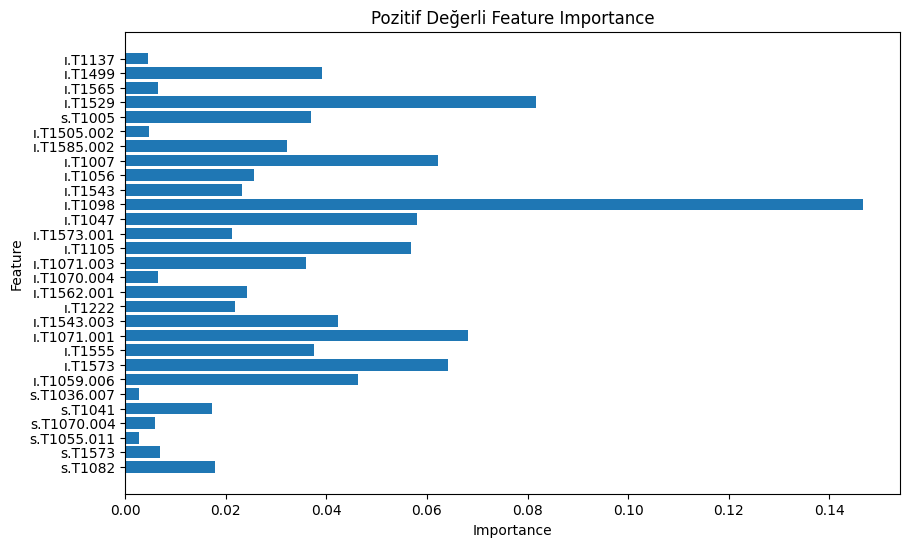

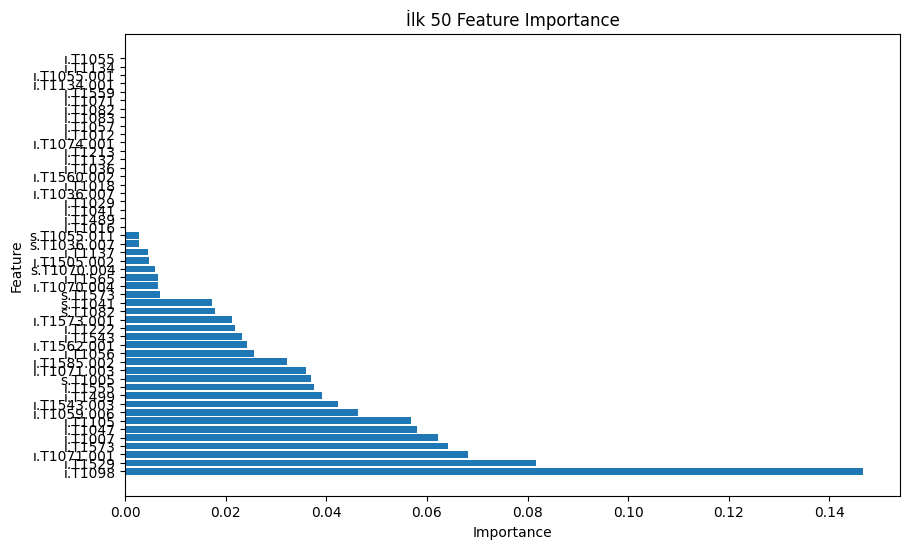

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Veri setindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


# ***SMOTE***

# ***`smote+shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50, 'subsample': 0.9}
Confusion Matrix:
[[10  7]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61        17
           1       0.22      0.25      0.24         8

    accuracy                           0.48        25
   macro avg       0.42      0.42      0.42        25
weighted avg       0.50      0.48      0.49        25

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
       

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Classification Report (İlk 50 Özellik ile):
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


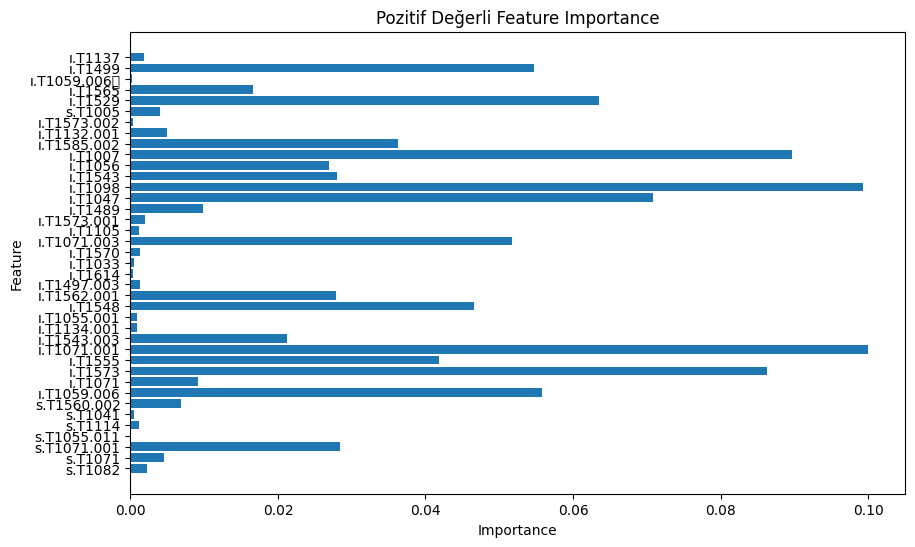

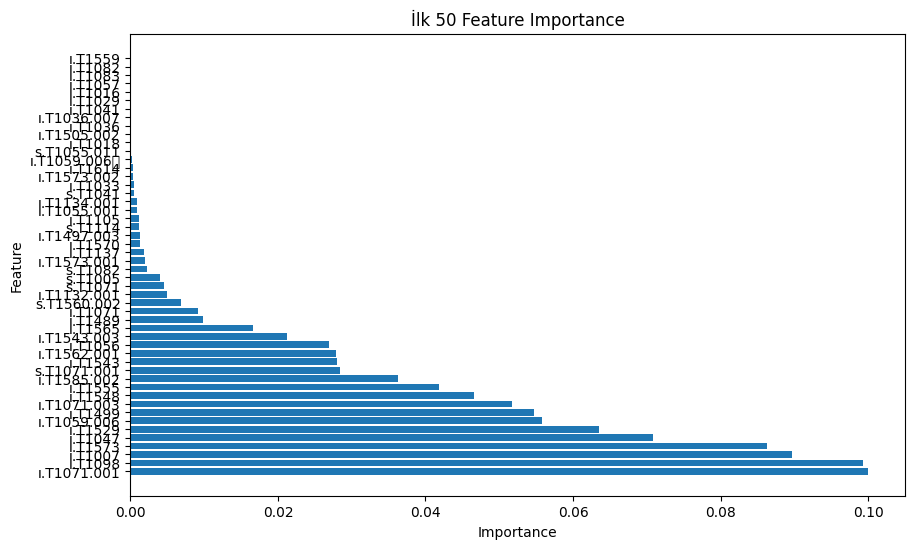

In [45]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


***`Borderline-SMOTE`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.9}
Confusion Matrix:
[[12  5]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
     

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


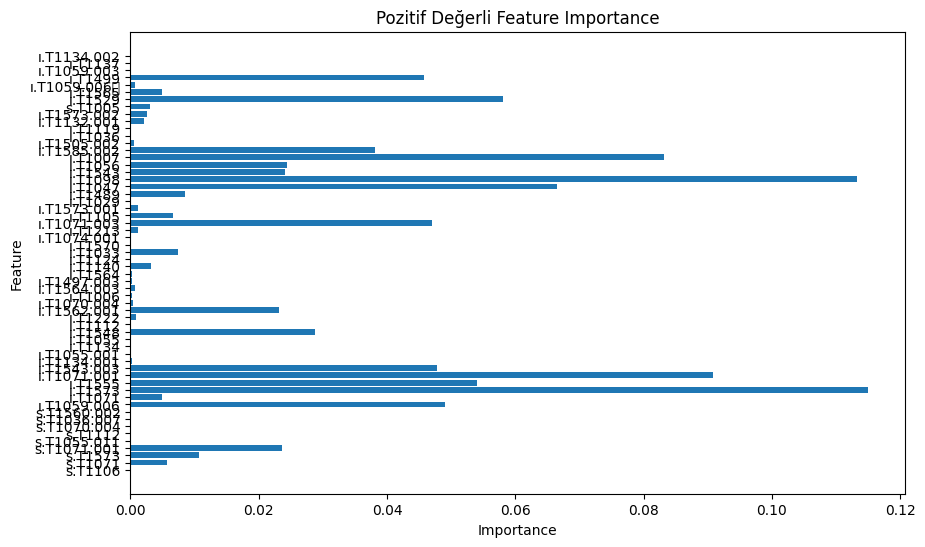

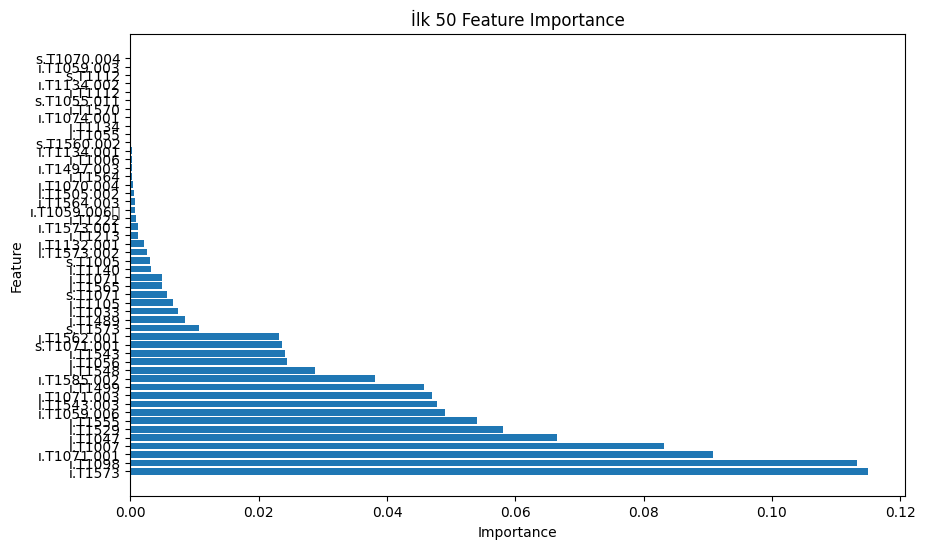

In [46]:
import pandas as pd
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Borderline-SMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


***`SMOTENC (SMOTE for Nominal and Continuous)`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50, 'subsample': 0.9}
Confusion Matrix:
[[10  7]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61        17
           1       0.22      0.25      0.24         8

    accuracy                           0.48        25
   macro avg       0.42      0.42      0.42        25
weighted avg       0.50      0.48      0.49        25

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
       

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


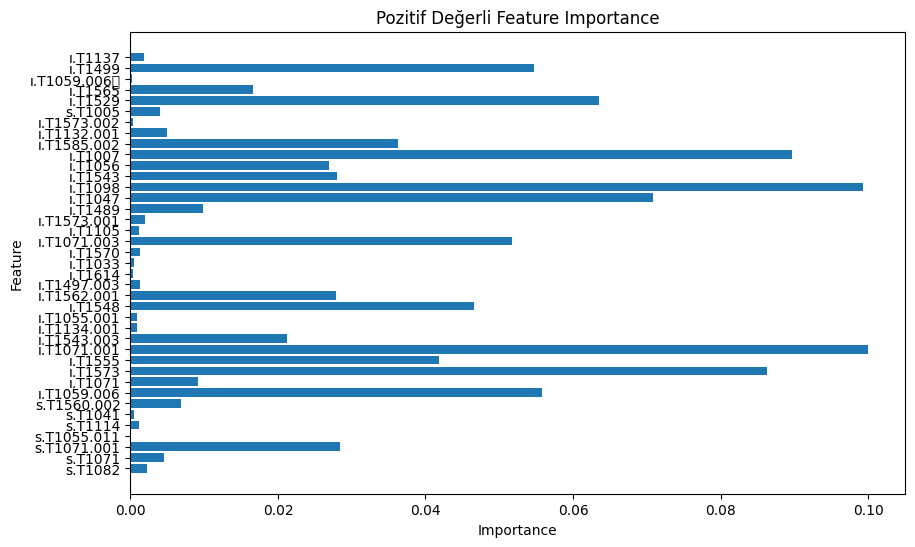

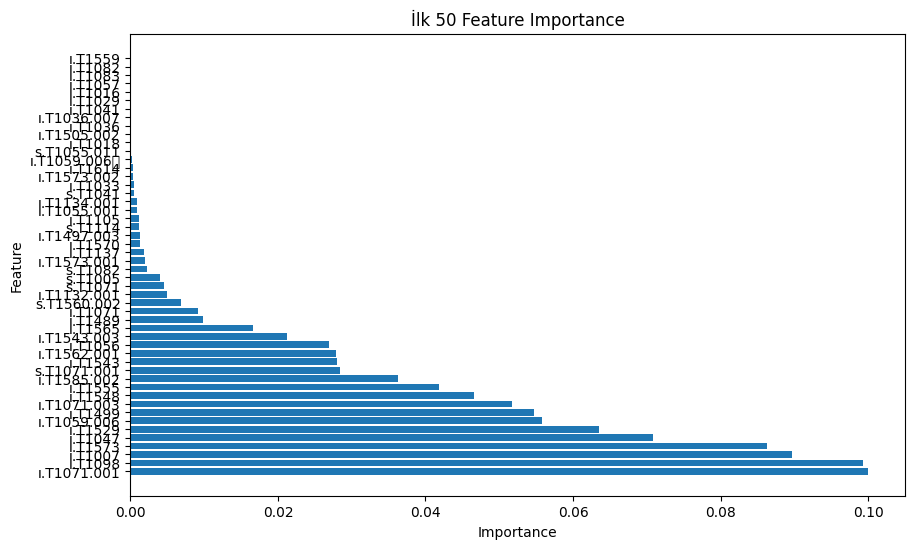

In [47]:
import pandas as pd
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Kategorik özelliklerin indekslerini belirtin
categorical_features = [0, 2]  # Bu listede kategorik olan sütunların indekslerini belirtin

# SMOTENC kullanarak veri artırma (kategorik özellikler göz önüne alınarak)
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


***`RandomOverSampler`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50, 'subsample': 0.9}
Confusion Matrix:
[[10  7]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.61        17
           1       0.22      0.25      0.24         8

    accuracy                           0.48        25
   macro avg       0.42      0.42      0.42        25
weighted avg       0.50      0.48      0.49        25

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
       

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


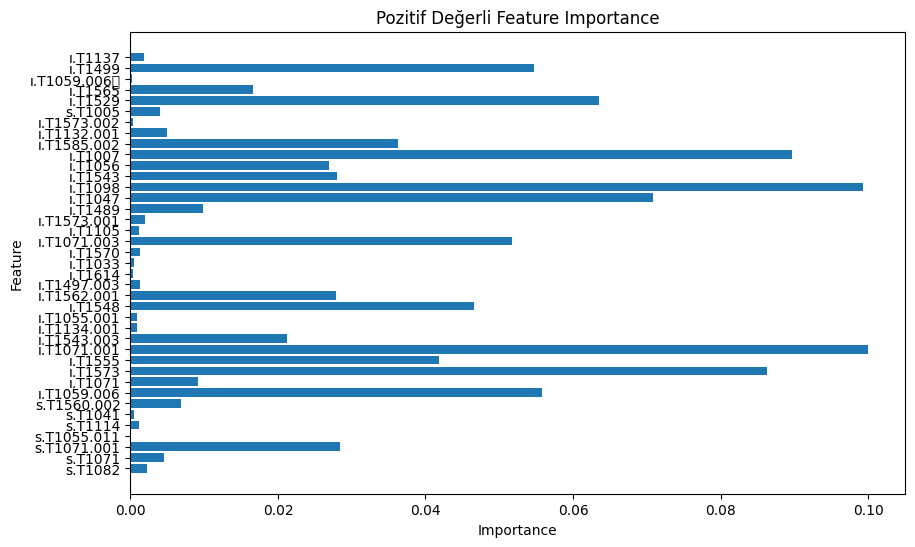

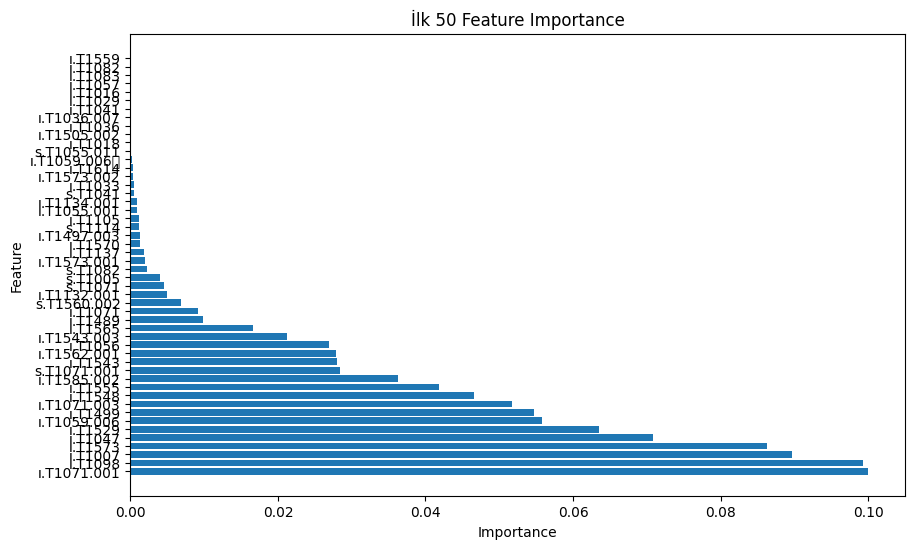

In [48]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# RandomOverSampler ile veri dengeleme
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


***`Tomek Links`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Confusion Matrix:
[[7 5]
 [9 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.38      0.25      0.30        12

    accuracy                           0.42        24
   macro avg       0.41      0.42      0.40        24
weighted avg       0.41      0.42      0.40        24

Fitting 3 folds for each of 729 candidates, totalling 2187 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (İlk 20 Özellik ile):
              precision    recall  f1-score   support

           0       0.44      0.58      0.50        12
           1       0.38      0.25      0.30        12

    accuracy                           0.42        24
   macro avg       0.41      0.42      0.40        24
weighted avg       0.41      0.42      0.40        24

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (İlk 50 Özellik ile):
              precision    recall  f1-score   support

           0    

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


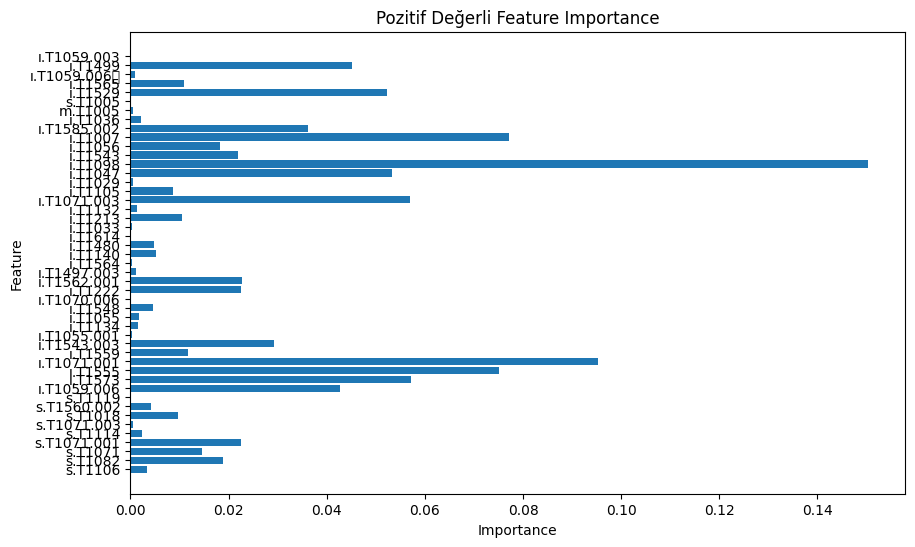

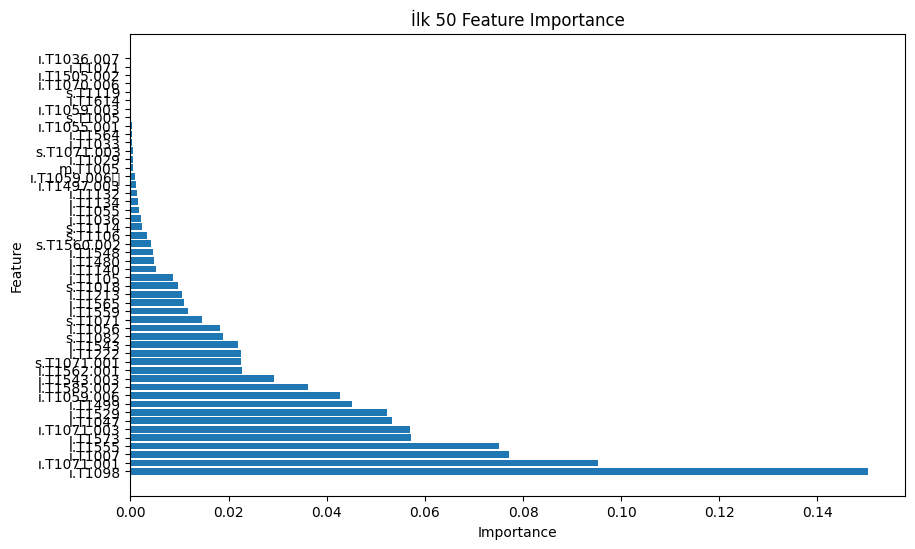

In [49]:
import pandas as pd
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links kullanarak veri azaltma (underdampling)
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Artırılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best parameters found:  {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
Confusion Matrix:
[[10  3]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Classification Report (Pozitif Değerli Özellikler ile):
              precision    recall  f1-score   support

           0       0.55      0.92      0.69        13
      

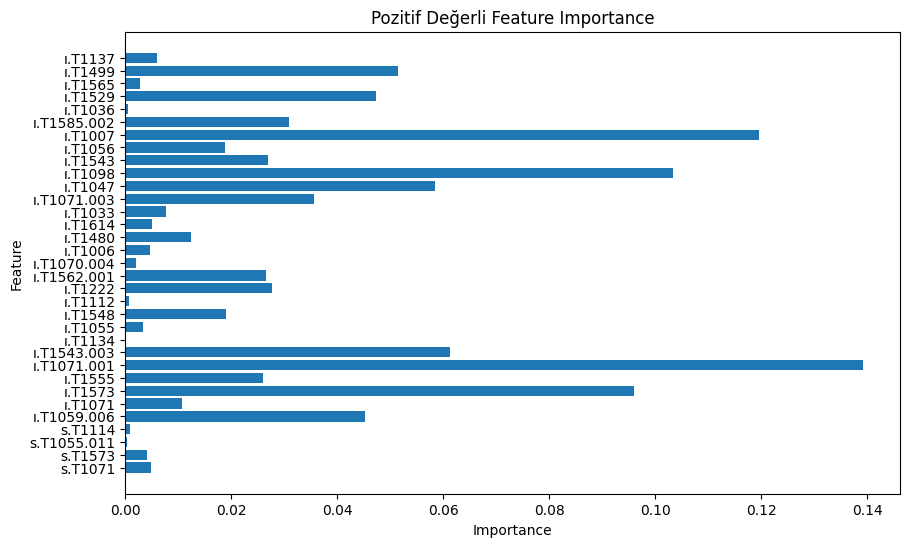

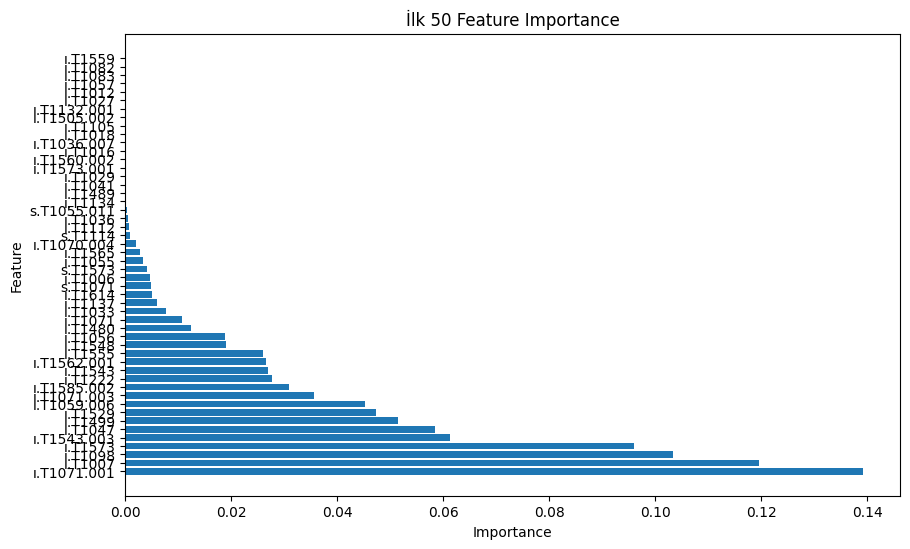

In [50]:
import pandas as pd
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTETomek kullanarak veri dengeleme
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Dengelemeyi yapılmış verileri eğitim ve test setlerine ayır
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Hiperparametre ızgarası
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Grid Search
grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance'ları al
feature_importance = grid_search.best_estimator_.feature_importances_

# Feature importance değerlerini DataFrame'e çevir
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Pozitif importance'a sahip olan özellikleri filtrele
positive_features = importance_df[importance_df['Importance'] > 0]

# Önem sırasına göre ilk 20 ve 50 özellikleri seç
top_20_features = positive_features.nlargest(20, 'Importance')['Feature']
top_50_features = positive_features.nlargest(50, 'Importance')['Feature']

# Pozitif değerlere sahip özellikler ile model tekrar çalıştırma
X_egitim_positive = X_egitim[positive_features['Feature']]
X_test_positive = X_test[positive_features['Feature']]

grid_search.fit(X_egitim_positive, y_egitim)
y_pred_positive = grid_search.predict(X_test_positive)
print("\nClassification Report (Pozitif Değerli Özellikler ile):")
print(classification_report(y_test, y_pred_positive))

# İlk 20 özellik ile model tekrar çalıştırma
X_egitim_top20 = X_egitim[top_20_features]
X_test_top20 = X_test[top_20_features]

grid_search.fit(X_egitim_top20, y_egitim)
y_pred_top20 = grid_search.predict(X_test_top20)
print("\nClassification Report (İlk 20 Özellik ile):")
print(classification_report(y_test, y_pred_top20))

# İlk 50 özellik ile model tekrar çalıştırma
X_egitim_top50 = X_egitim[top_50_features]
X_test_top50 = X_test[top_50_features]

grid_search.fit(X_egitim_top50, y_egitim)
y_pred_top50 = grid_search.predict(X_test_top50)
print("\nClassification Report (İlk 50 Özellik ile):")
print(classification_report(y_test, y_pred_top50))

# Pozitif özellikler için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Pozitif Değerli Feature Importance')
plt.show()

# Tüm özellikler için bar grafiği
importance_df_sorted = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_sorted['Feature'].head(50), importance_df_sorted['Importance'].head(50))
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('İlk 50 Feature Importance')
plt.show()


# ***`VOTING MODEL`***

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.42      0.91      0.57        11

    accuracy                           0.40        25
   macro avg       0.21      0.45      0.29        25
weighted avg       0.18      0.40      0.25        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.50      0.14      0.22        14
           1       0.43      0.82      0.56        11

    accuracy                           0.44        25
   macro avg       0.46      0.48      0.39        25
weighted avg       0.47      0.44      0.37        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.50      0.14      0.22        14
           1       0.43      0.82      0.56        11

    accuracy                           0.44        25
   macro avg       0.46      0.48      0.39        25
weighted avg       0.4

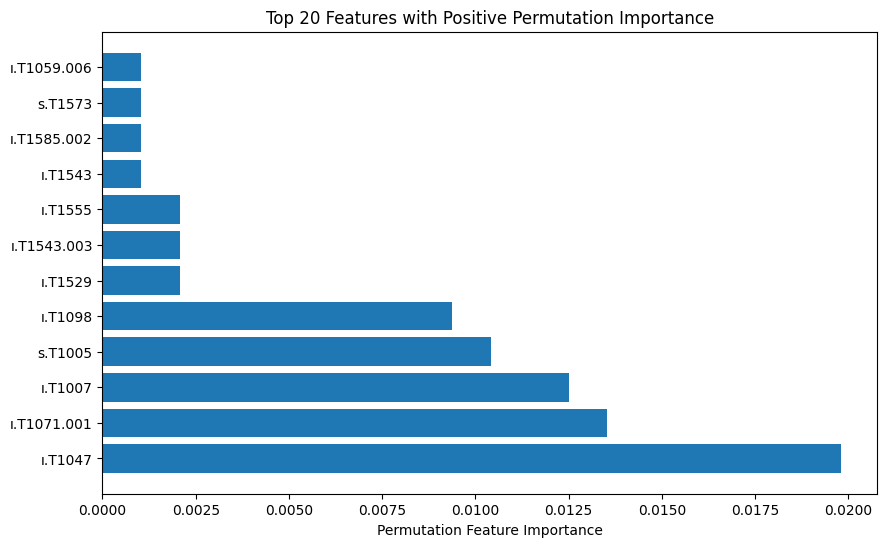

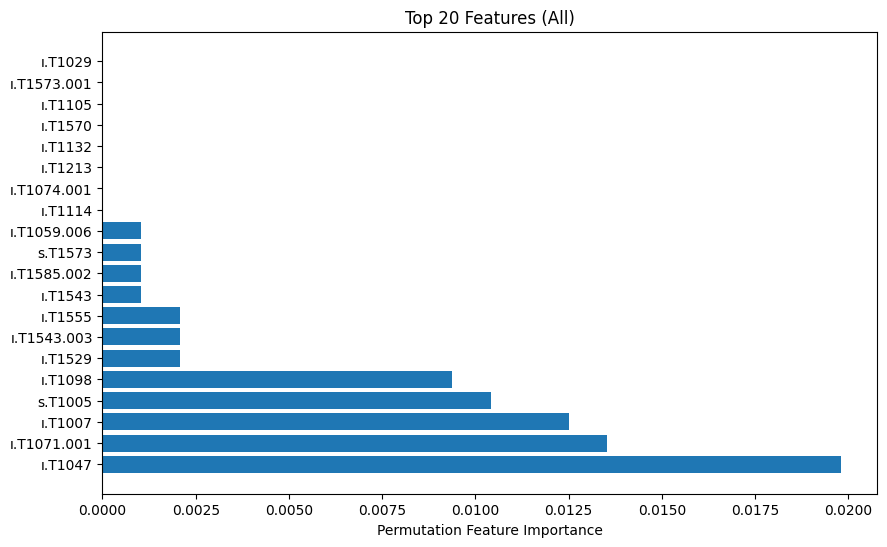

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # Hedef değişkenin adını 'Malicious' olarak kullanıyoruz
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Sert oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


# ***SMOTE***

In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report


# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Verileri bağımlı ve bağımsız değişkenlere ayırma
X = df.drop(columns=['Malicious'])
y = df['Malicious']

# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Sert oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_resampled, y_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.43      0.91      0.59        11

    accuracy                           0.44        25
   macro avg       0.47      0.49      0.36        25
weighted avg       0.47      0.44      0.33        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.4

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

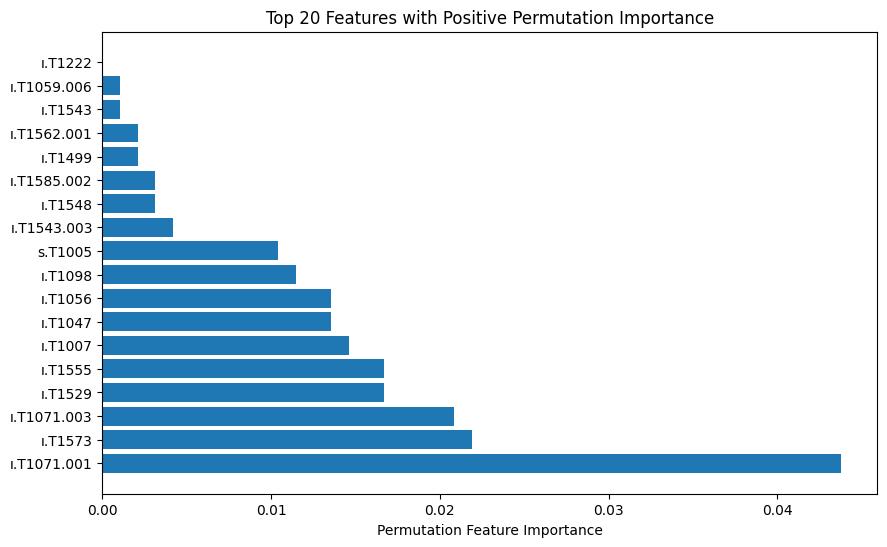

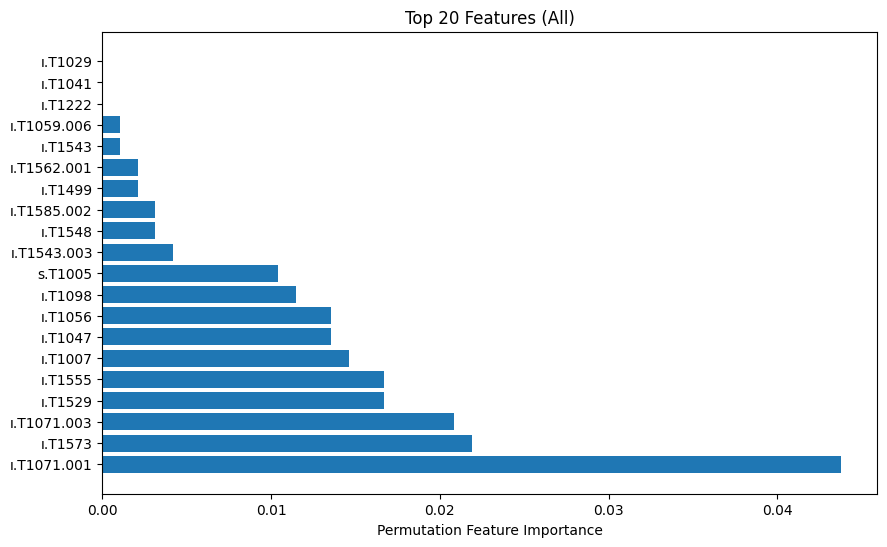

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Verileri bağımlı ve bağımsız değişkenlere ayırma
X = df.drop(columns=['Malicious'])
y = df['Malicious']

# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Sert oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_resampled, y_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Voting 2

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'hedef_sutunu' hedef değişkenin adını verin
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000)

# Verileri ölçeklendirme ve model oluşturma
voting_classifier = make_pipeline(StandardScaler(), VotingClassifier(
    estimators=[('rf', random_forest), ('lr', logistic_regression)],
    voting='hard'  # Sert oylama kullanılacak
))

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25



Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.55      0.86      0.67        14
           1       0.33      0.09      0.14        11

    accuracy                           0.52        25
   macro avg       0.44      0.47      0.40        25
weighted avg       0.45      0.52      0.44        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49   

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


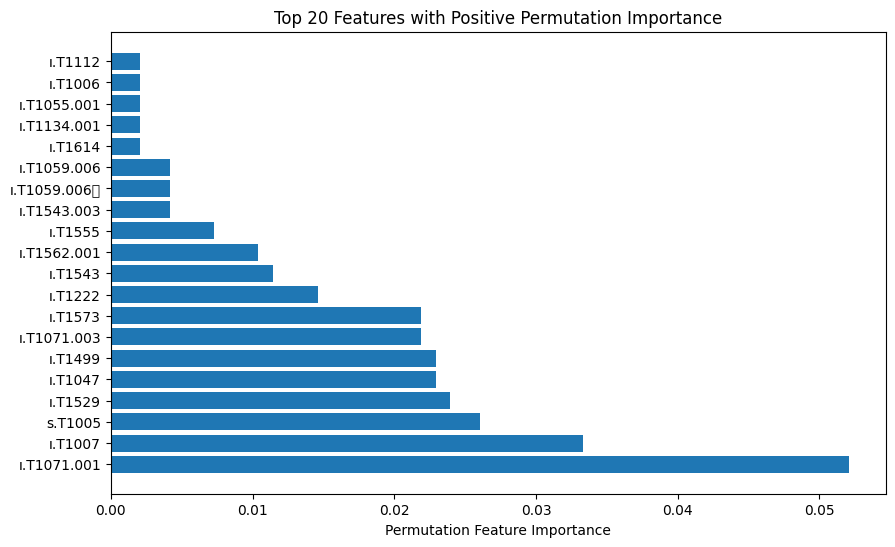

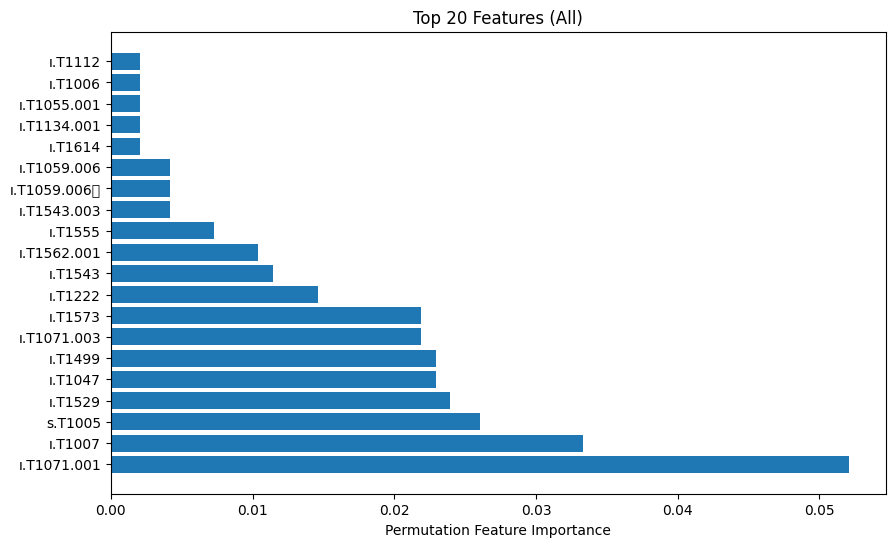

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'hedef_sutunu' hedef değişkenin adını verin
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000)

# Verileri ölçeklendirme ve model oluşturma
voting_classifier = make_pipeline(StandardScaler(), VotingClassifier(
    estimators=[('rf', random_forest), ('lr', logistic_regression)],
    voting='hard'  # Sert oylama kullanılacak
))

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


# ***SMOTE***

In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE



# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Verileri bağımlı ve bağımsız değişkenlere ayırma
X = df.drop(columns=['Malicious'])
y = df['Malicious']

# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000)

# Verileri ölçeklendirme ve model oluşturma
voting_classifier = make_pipeline(StandardScaler(), VotingClassifier(
    estimators=[('rf', random_forest), ('lr', logistic_regression)],
    voting='hard'  # Sert oylama kullanılacak
))

# Modeli eğitme
voting_classifier.fit(X_resampled, y_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       0.56      0.71      0.62        14
           1       0.43      0.27      0.33        11

    accuracy                           0.52        25
   macro avg       0.49      0.49      0.48        25
weighted avg       0.50      0.52      0.50        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.50      0.18      0.27        11

    accuracy                           0.56        25
   macro avg       0.54      0.52      0.48        25
weighted avg       0.54      0.56      0.50        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.56      0.71   

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


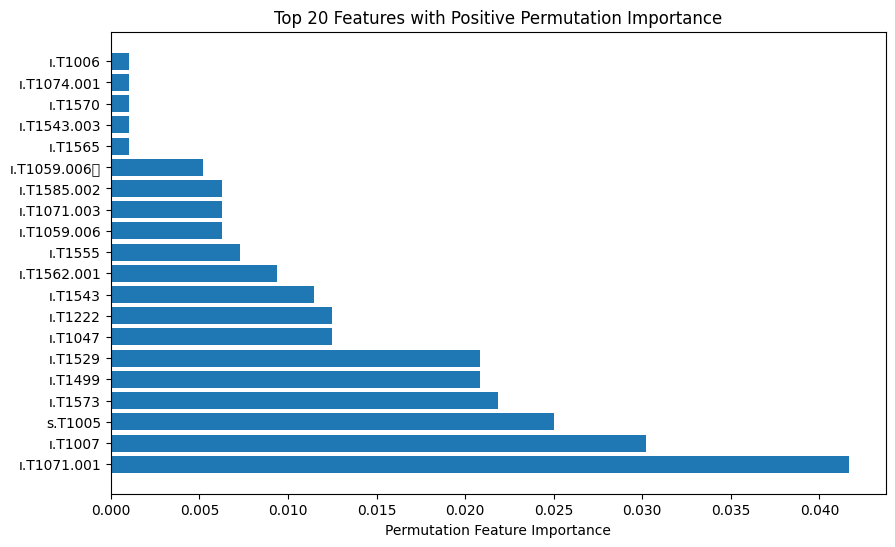

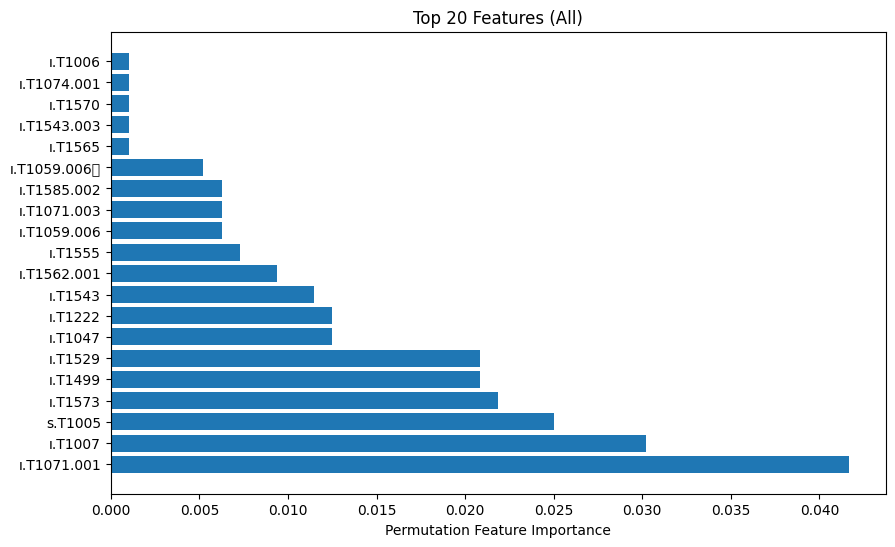

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    df = pd.read_excel(root)
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Verileri bağımlı ve bağımsız değişkenlere ayırma
X = df.drop(columns=['Malicious'])
y = df['Malicious']

# Veri setini eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE kullanarak veri artırma
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
logistic_regression = LogisticRegression(max_iter=1000)

# Verileri ölçeklendirme ve model oluşturma
voting_classifier = make_pipeline(StandardScaler(), VotingClassifier(
    estimators=[('rf', random_forest), ('lr', logistic_regression)],
    voting='hard'  # Sert oylama kullanılacak
))

# Modeli eğitme
voting_classifier.fit(X_resampled, y_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Voting SOFT

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'hedef_sutunu' hedef değişkenin adını verin
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Sert oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.43      0.91      0.59        11

    accuracy                           0.44        25
   macro avg       0.47      0.49      0.36        25
weighted avg       0.47      0.44      0.33        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.43      0.91      0.59        11

    accuracy                           0.44        25
   macro avg       0.47      0.49      0.36        25
weighted avg       0.47      0.44      0.33        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.50      0.07      0.12        14
           1       0.43      0.91      0.59        11

    accuracy                           0.44        25
   macro avg       0.47      0.49   

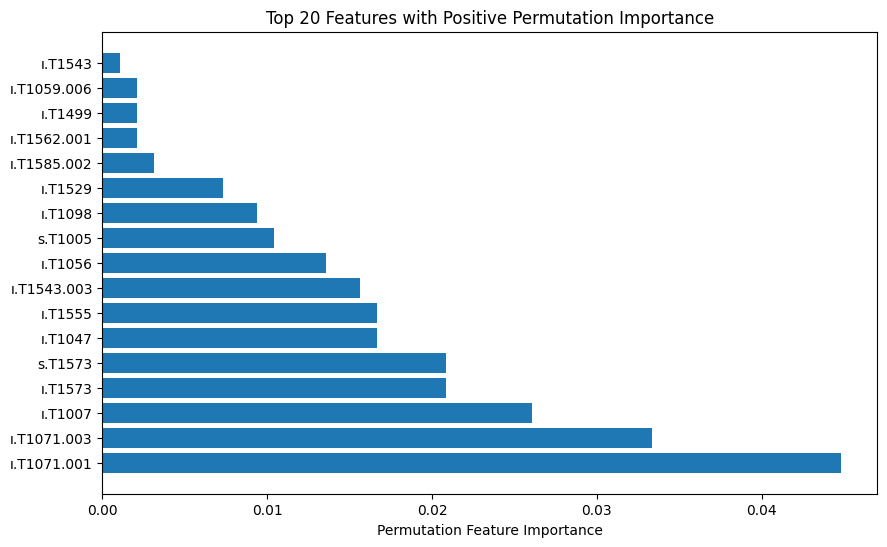

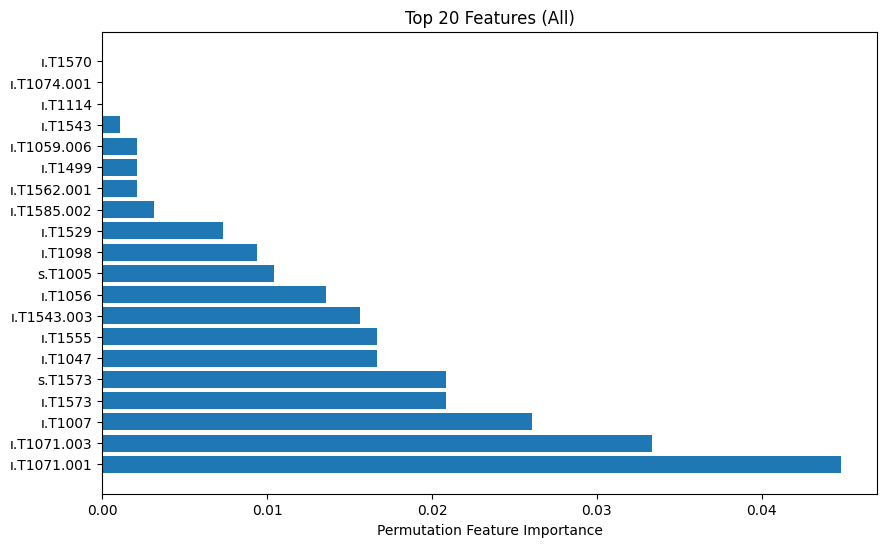

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`SMOTE`***

In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'hedef_sutunu' hedef değişkenin adını verin
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE yöntemini kullanarak veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Sert oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train_resampled, y_train_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       1.00      0.07      0.13        14
           1       0.46      1.00      0.63        11

    accuracy                           0.48        25
   macro avg       0.73      0.54      0.38        25
weighted avg       0.76      0.48      0.35        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       1.00      0.07      0.13        14
           1       0.46      1.00      0.63        11

    accuracy                           0.48        25
   macro avg       0.73      0.54      0.38        25
weighted avg       0.76      0.48      0.35        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       1.00      0.07      0.13        14
           1       0.46      1.00      0.63        11

    accuracy                           0.48        25
   macro avg       0.73      0.54   

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


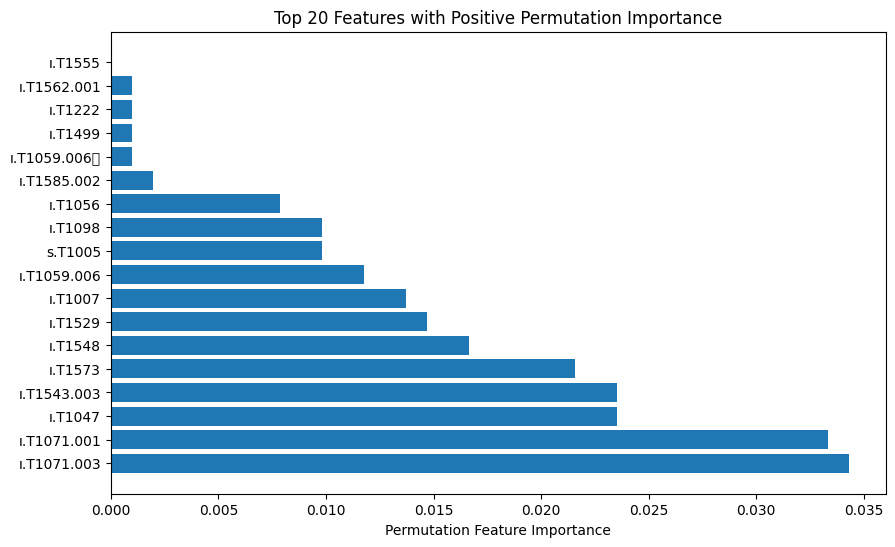

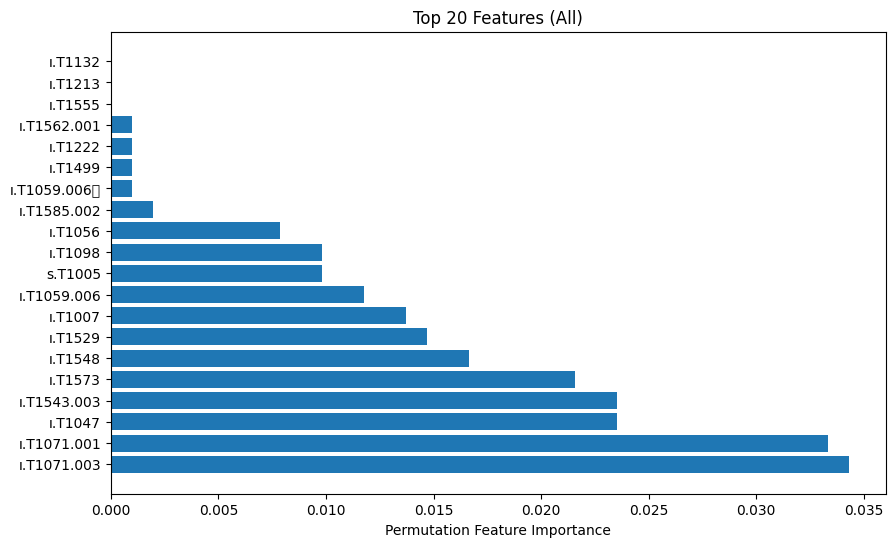

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTE yöntemini kullanarak veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train_resampled, y_train_resampled)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()



***`Borderline-SMOTE`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import BorderlineSMOTE

# Örnek veri seti oluşturma
# df = pd.read_csv('veri.csv')  # Örnek olarak veri setinizi buradan yükleyebilirsiniz

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# BorderlineSMOTE ile veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54   

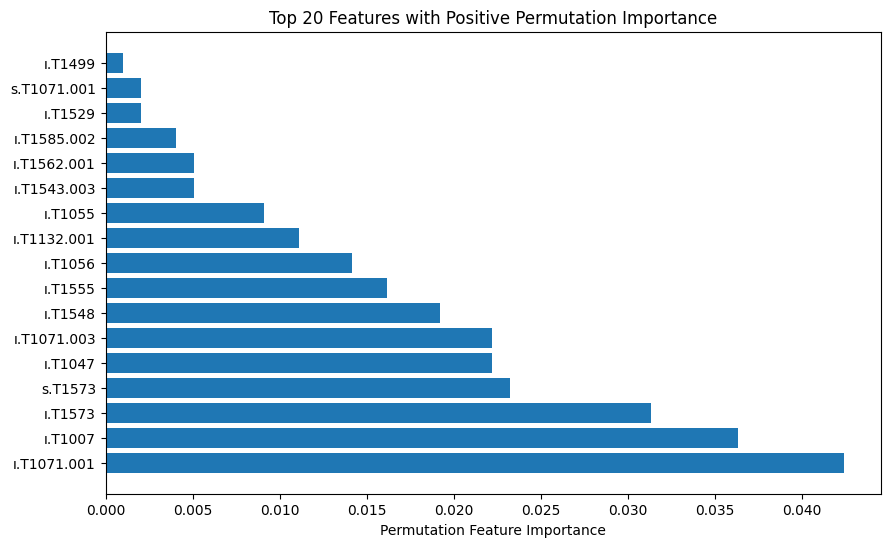

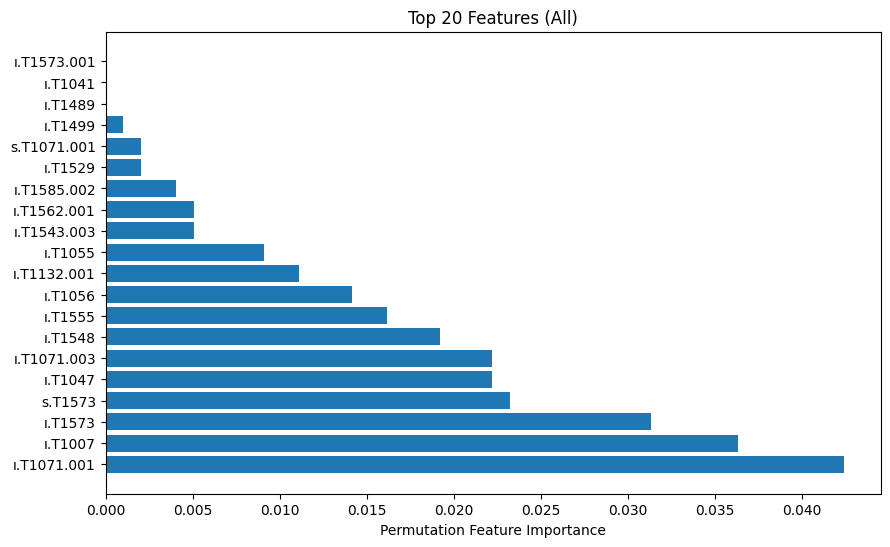

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt

# Örnek veri seti oluşturma
# df = pd.read_csv('veri.csv')  # Örnek olarak veri setinizi buradan yükleyebilirsiniz

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# BorderlineSMOTE ile veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`SMOTENC (SMOTE for Nominal and Continuous)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTENC

# Örnek veri seti oluşturma
# df = pd.read_csv('veri.csv')  # Örnek olarak veri setinizi buradan yükleyebilirsiniz

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       1.00      0.12      0.21        17
           1       0.35      1.00      0.52         8

    accuracy                           0.40        25
   macro avg       0.67      0.56      0.36        25
weighted avg       0.79      0.40      0.31        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51   

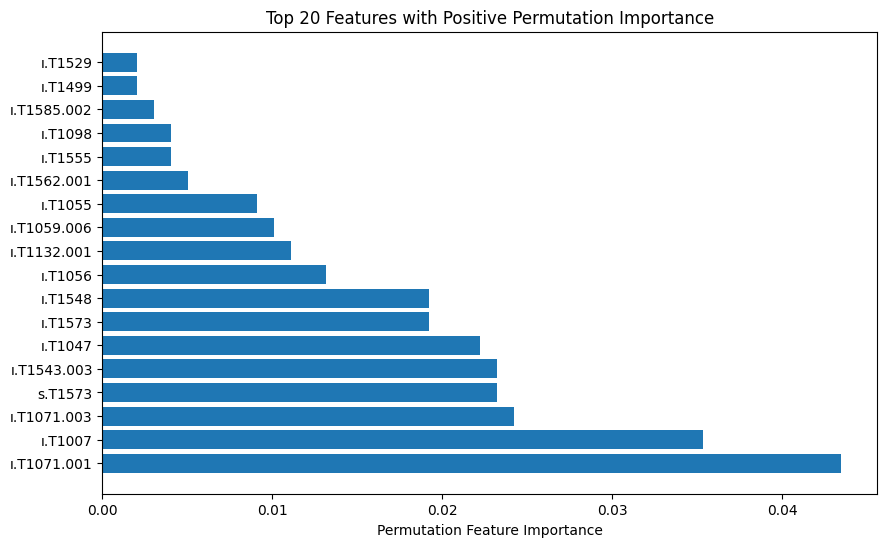

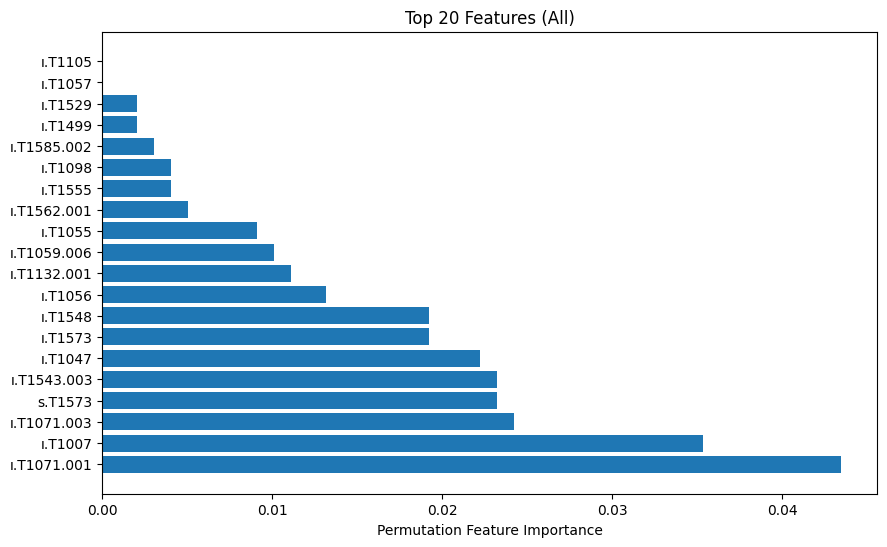

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`RandomOverSampler`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       1.00      0.24      0.38        17
           1       0.38      1.00      0.55         8

    accuracy                           0.48        25
   macro avg       0.69      0.62      0.47        25
weighted avg       0.80      0.48      0.44        25

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54      0.53        25
weighted avg       0.60      0.64      0.61        25

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        17
           1       0.40      0.25      0.31         8

    accuracy                           0.64        25
   macro avg       0.55      0.54   

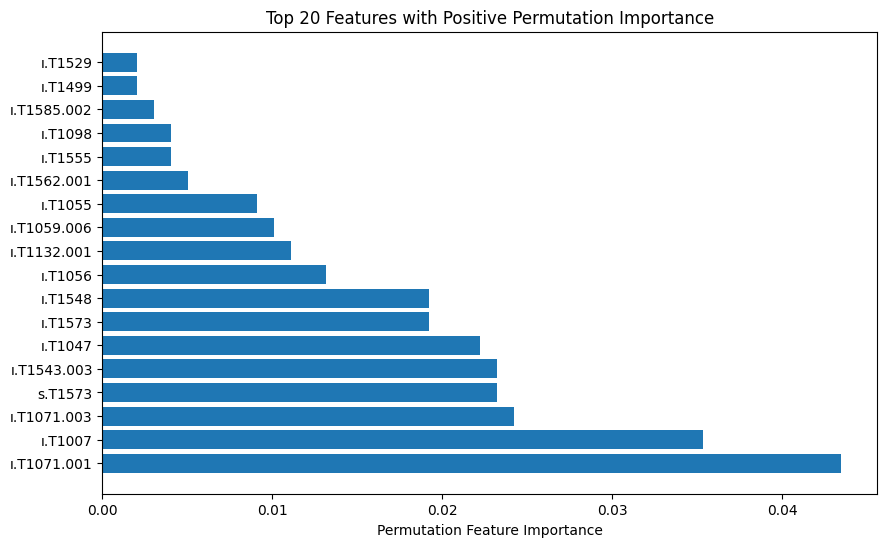

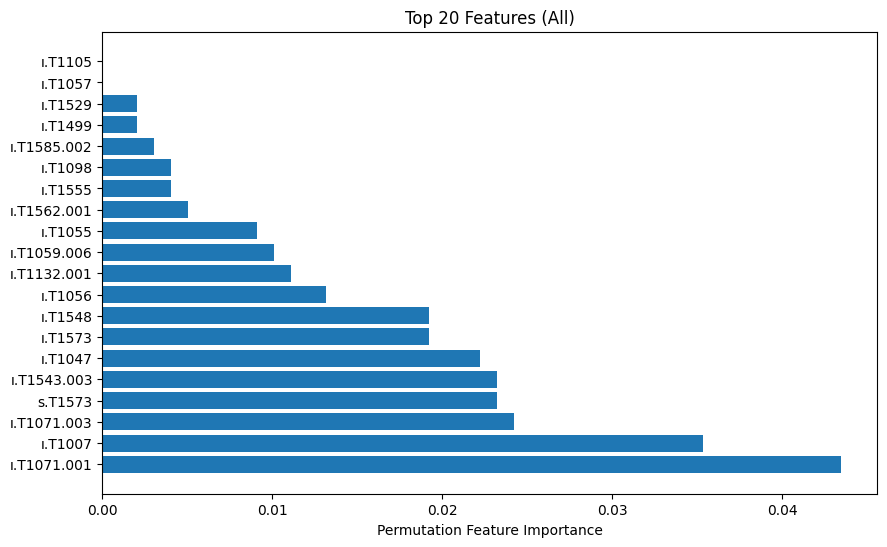

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`Tomek Links`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import TomekLinks

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# TomekLinks kullanarak veri azaltma
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        12
           1       0.29      0.17      0.21        12

    accuracy                           0.38        24
   macro avg       0.35      0.38      0.35        24
weighted avg       0.35      0.38      0.35        24

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.39      0.58      0.47        12
           1       0.17      0.08      0.11        12

    accuracy                           0.33        24
   macro avg       0.28      0.33      0.29        24
weighted avg       0.28      0.33      0.29        24

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.39      0.58      0.47        12
           1       0.17      0.08      0.11        12

    accuracy                           0.33        24
   macro avg       0.28      0.33   

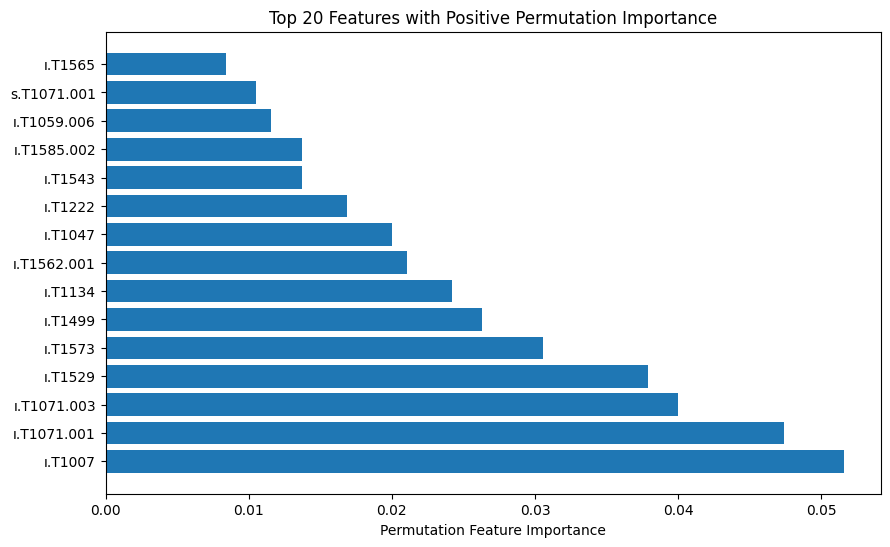

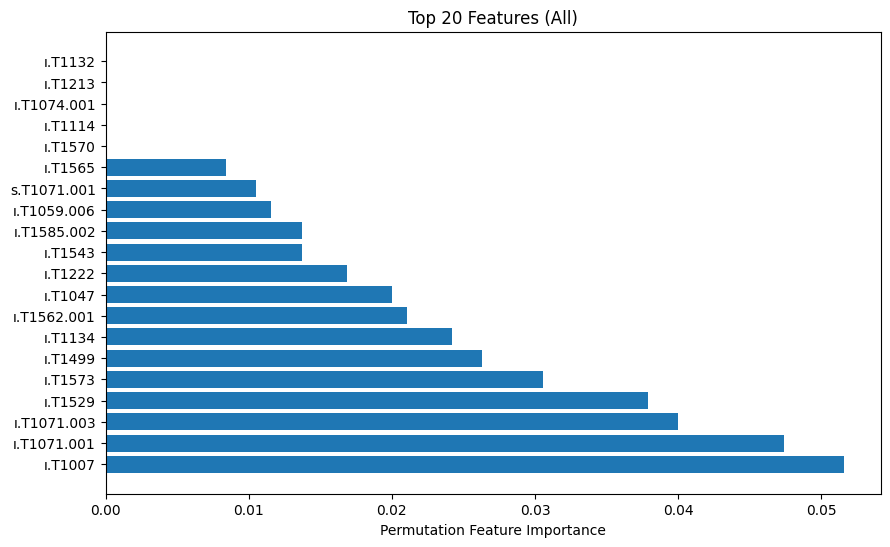

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# TomekLinks kullanarak veri azaltma
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from imblearn.combine import SMOTETomek

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adını verin
y = df['Malicious']

# SMOTETomek kullanarak veri artırma ve azaltma
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print(classification_report(y_test, y_pred))


Sınıflandırma raporu (Tüm feature'lar):
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48      0.44        24
weighted avg       0.47      0.50      0.45        24

İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.53      0.77      0.62        13
           1       0.40      0.18      0.25        11

    accuracy                           0.50        24
   macro avg       0.46      0.48   

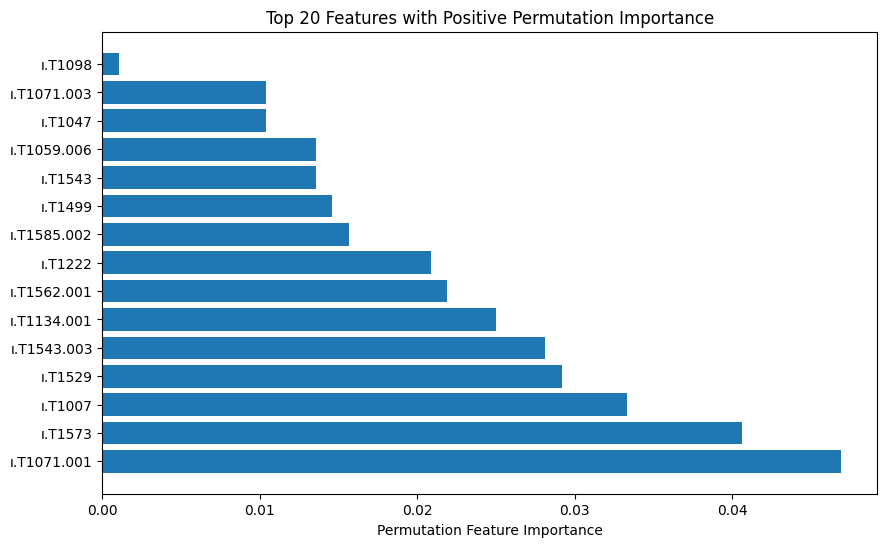

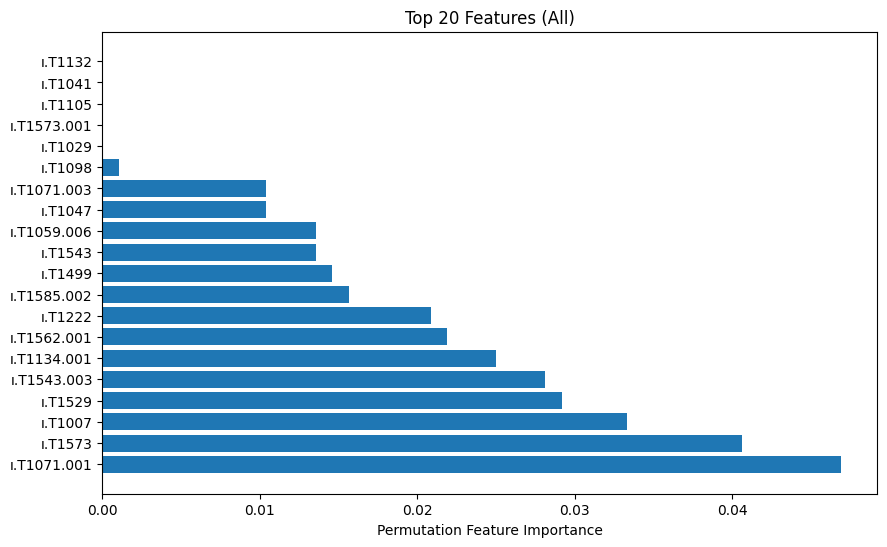

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# SMOTETomek kullanarak veri artırma ve azaltma
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Yumuşak oylama kullanılacak
)

# Modeli eğitme
voting_classifier.fit(X_train, y_train)

# Test seti üzerinde modeli değerlendirme
y_pred = voting_classifier.predict(X_test)

# Sınıflandırma raporu
print("Sınıflandırma raporu (Tüm feature'lar):")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(voting_classifier, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[top_20_features]
X_test_top_20 = X_test[top_20_features]
voting_classifier.fit(X_train_top_20, y_train)
y_pred_top_20 = voting_classifier.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[top_50_features]
X_test_top_50 = X_test[top_50_features]
voting_classifier.fit(X_train_top_50, y_train)
y_pred_top_50 = voting_classifier.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Soft oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 7, 'knn__weights': 'uniform', 'svm__C': 0.1, 'svm__gamma': 0.001}
Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/IPython/c

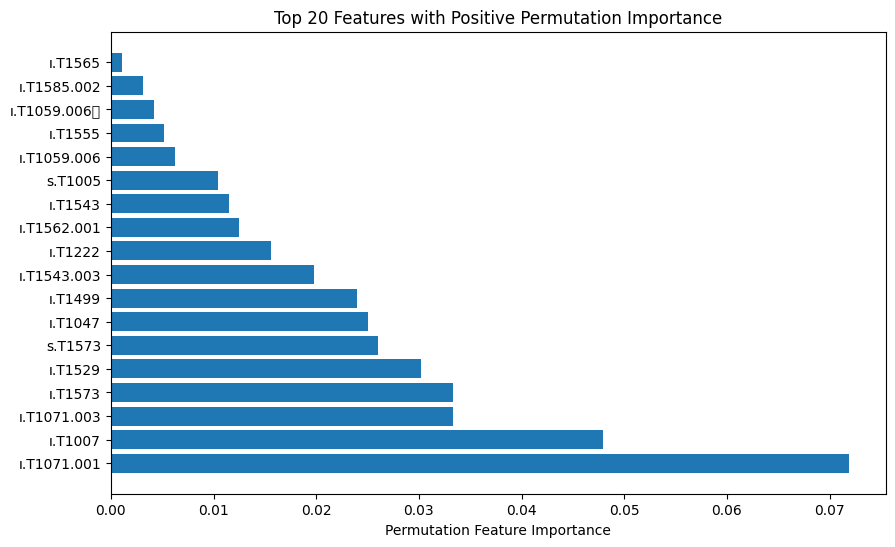

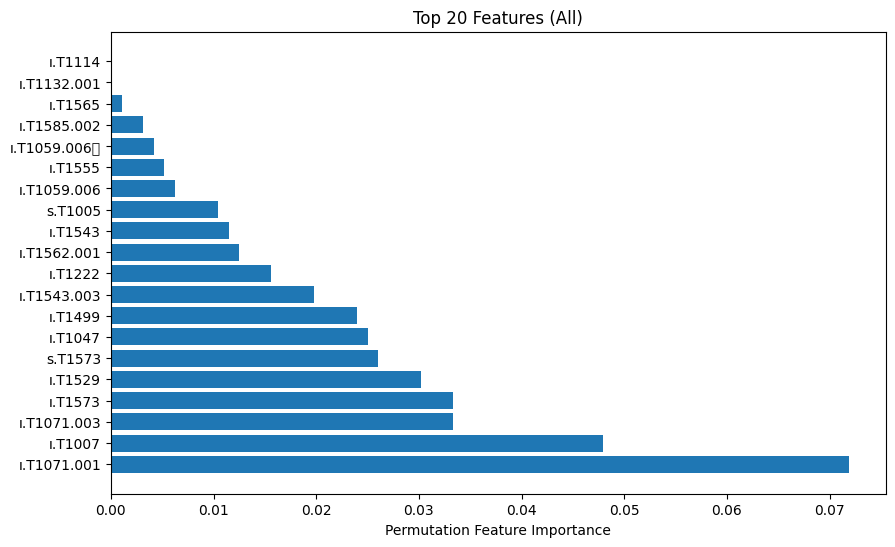

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Soft oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE ile veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Soft oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE ile veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='soft'  # Soft oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train_resampled)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train_resampled)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'svm__C': 1, 'svm__gamma': 0.1}
Confusion Matrix:
[[10  4]
 [ 6  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.71      0.67        14
           1       0.56      0.45      0.50        11

    accuracy                           0.60        25
   macro avg       0.59      0.58      0.58        25
weighted avg       0.59      0.60      0.59        25



ValueError: Found input variables with inconsistent numbers of samples: [96, 102]

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 5, 'knn__weights': 'uniform', 'svm__C': 1, 'svm__gamma': 0.1}
Confusion Matrix:
[[9 5]
 [7 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.44      0.36      0.40        11

    accuracy                           0.52        25
   macro avg       0.50      0.50      0.50        25
weighted avg       0.51      0.52      0.51        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisi

İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


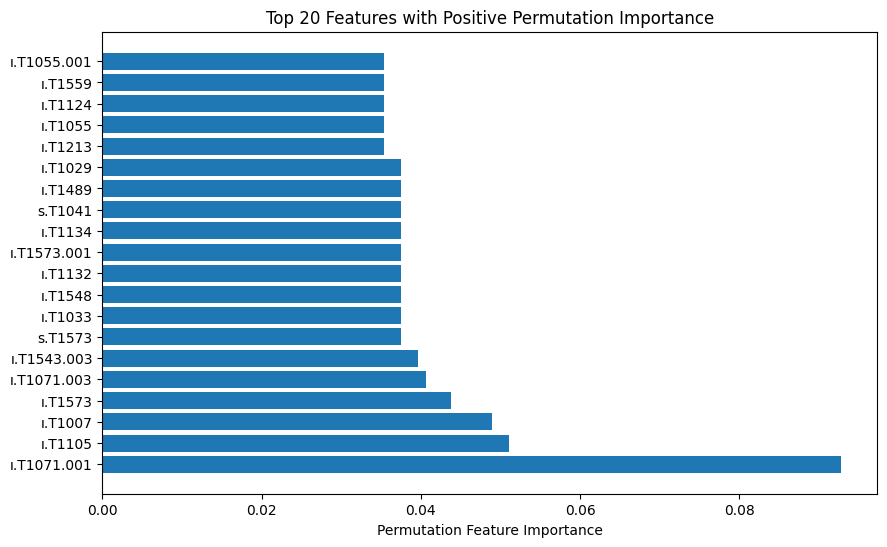

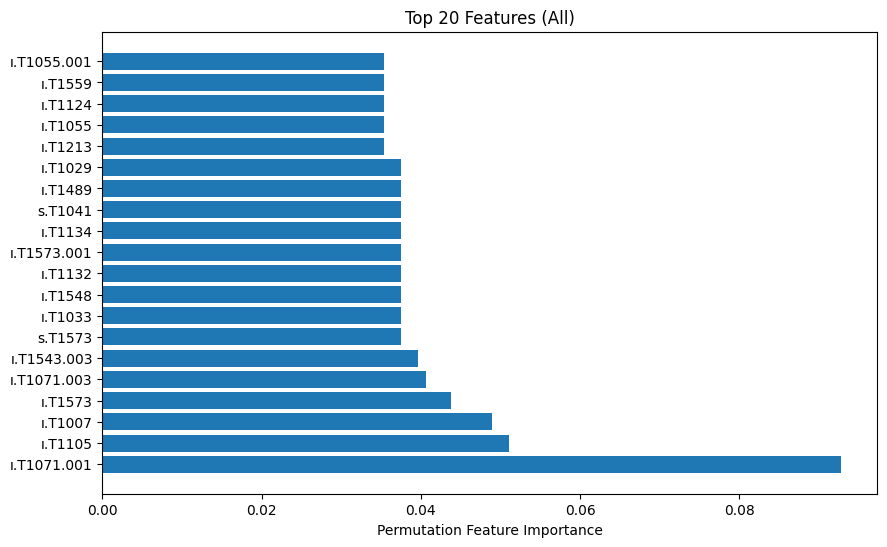

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`SMOTE`***

In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE ile veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE ile veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train_resampled)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train_resampled)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'svm__C': 0.1, 'svm__gamma': 0.01}
Confusion Matrix:
[[10  4]
 [ 6  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.71      0.67        14
           1       0.56      0.45      0.50        11

    accuracy                           0.60        25
   macro avg       0.59      0.58      0.58        25
weighted avg       0.59      0.60      0.59        25



ValueError: Found input variables with inconsistent numbers of samples: [96, 102]

***`Borderline-SMOTE`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# BorderlineSMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'svm__C': 10, 'svm__gamma': 0.001}
Confusion Matrix:
[[13  4]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.33      0.25      0.29         8

    accuracy                           0.60        25
   macro avg       0.51      0.51      0.50        25
weighted avg       0.57      0.60      0.58        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


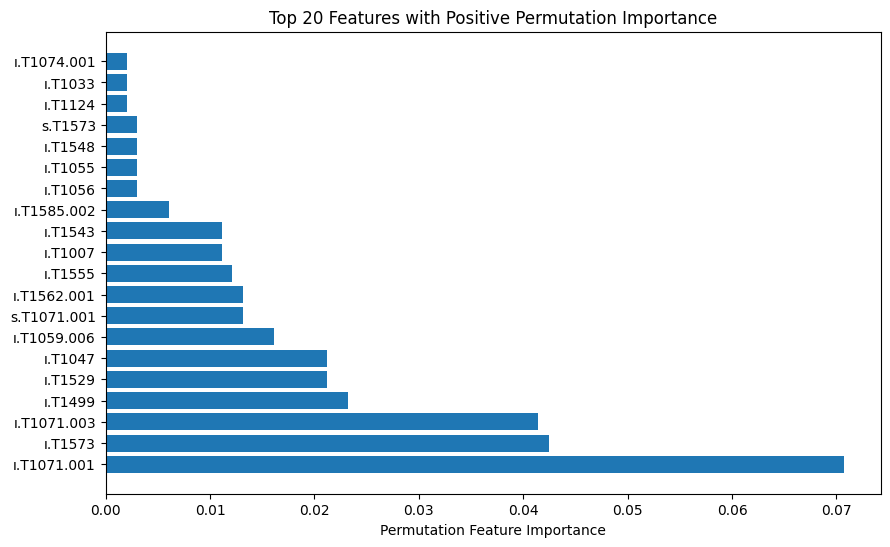

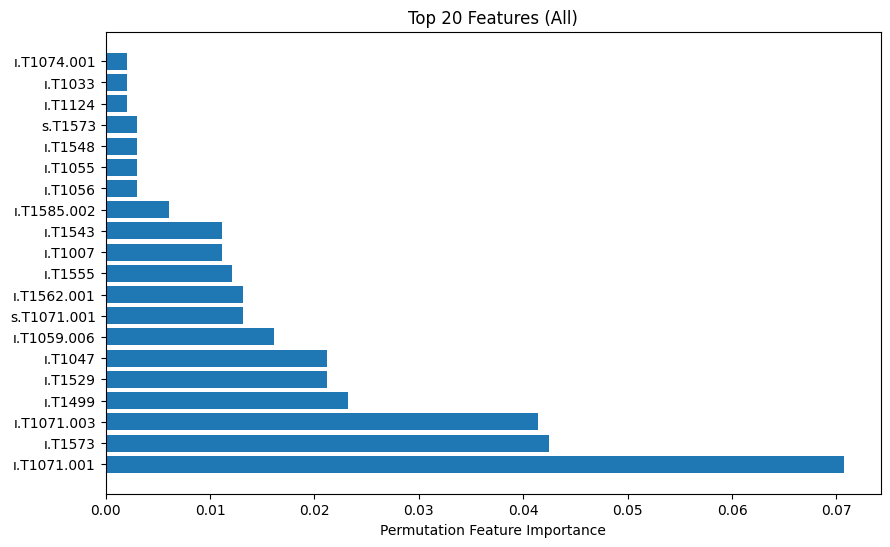

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# BorderlineSMOTE kullanarak veri artırma
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`SMOTENC (SMOTE for Nominal and Continuous)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'svm__C': 10, 'svm__gamma': 0.001}
Confusion Matrix:
[[12  5]
 [ 6  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.29      0.25      0.27         8

    accuracy                           0.56        25
   macro avg       0.48      0.48      0.48        25
weighted avg       0.54      0.56      0.55        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


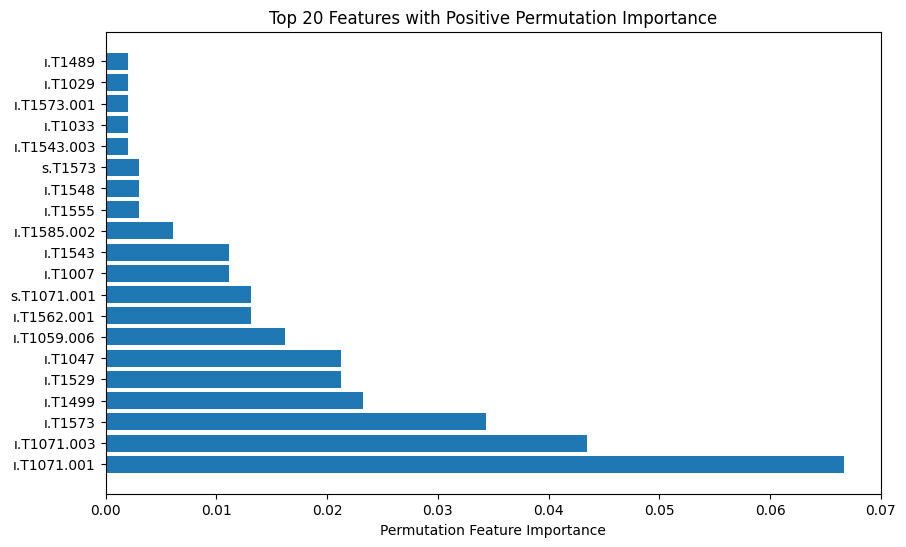

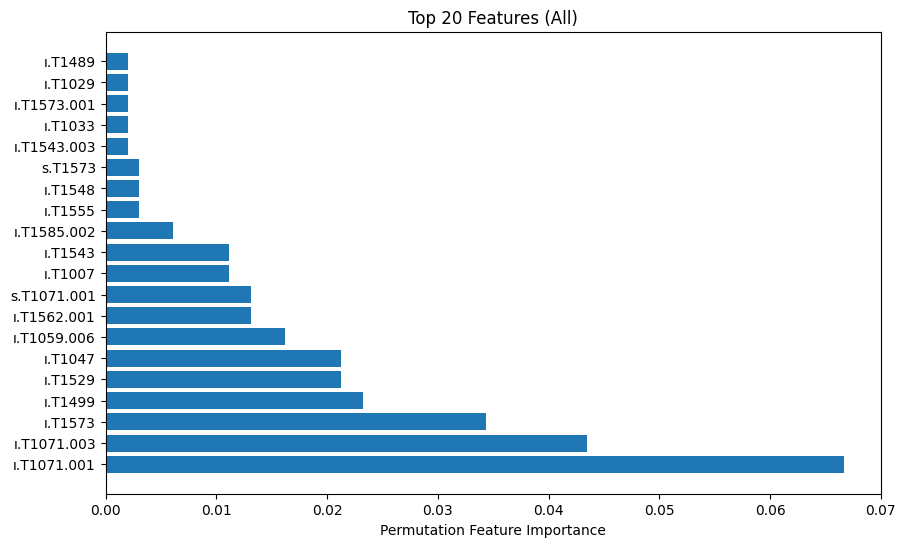

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train, y_train, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


***`RandomOverSampler`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# RandomOverSampler kullanarak veri artırma
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train_resampled)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train_resampled)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 5, 'knn__weights': 'distance', 'svm__C': 10, 'svm__gamma': 0.1}
Confusion Matrix:
[[9 5]
 [7 4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        14
           1       0.44      0.36      0.40        11

    accuracy                           0.52        25
   macro avg       0.50      0.50      0.50        25
weighted avg       0.51      0.52      0.51        25



ValueError: Found input variables with inconsistent numbers of samples: [96, 102]

***`Tomek Links`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import TomekLinks

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tomek Links işlemi
tl = TomekLinks()
X_train_resampled, y_train_resampled = tl.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tomek Links işlemi ile veri azaltma
tl = TomekLinks()
X_train_resampled, y_train_resampled = tl.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train_resampled)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train_resampled)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 5, 'knn__weights': 'uniform', 'svm__C': 1, 'svm__gamma': 0.1}
Confusion Matrix:
[[9 5]
 [8 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        14
           1       0.38      0.27      0.32        11

    accuracy                           0.48        25
   macro avg       0.45      0.46      0.45        25
weighted avg       0.46      0.48      0.46        25



ValueError: Found input variables with inconsistent numbers of samples: [96, 93]

***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' yerine gerçek hedef değişkenin adını yazmalısınız
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTETomek işlemi
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Best parameters found:  {'dt__max_depth': None, 'dt__min_samples_split': 2, 'knn__n_neighbors': 5, 'knn__weights': 'uniform', 'svm__C': 0.1, 'svm__gamma': 0.1}
Confusion Matrix:
[[9 5]
 [6 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.64      0.62        14
           1       0.50      0.45      0.48        11

    accuracy                           0.56        25
   macro avg       0.55      0.55      0.55        25
weighted avg       0.56      0.56      0.56        25

Fitting 3 folds for each of 648 candidates, totalling 1944 fits
İlk 20 feature ile model:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72        14
           1       0.00      0.00      0.00        11

    accuracy                           0.56        25
   macro avg       0.28      0.50      0.36        25
weighted avg       0.31      0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


İlk 50 feature ile model:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72        14
           1       0.00      0.00      0.00        11

    accuracy                           0.56        25
   macro avg       0.28      0.50      0.36        25
weighted avg       0.31      0.56      0.40        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/IPython/c

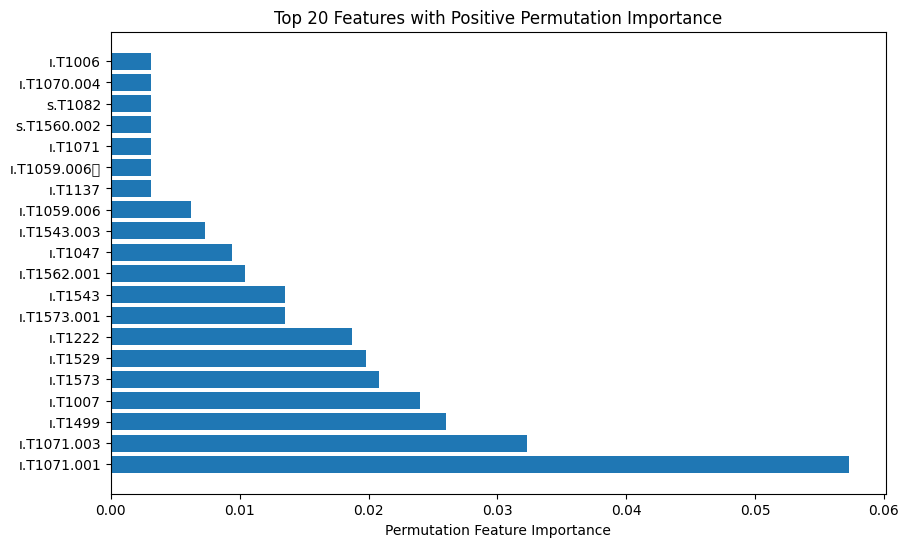

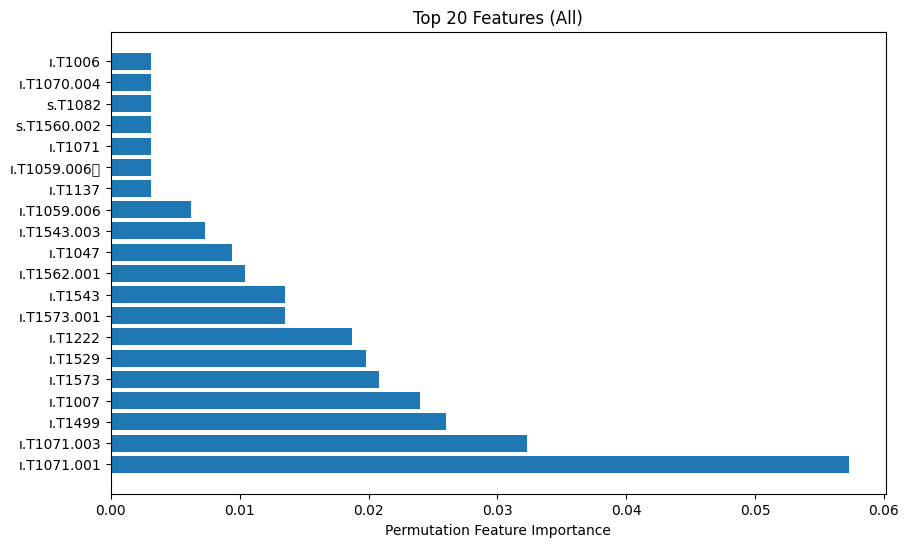

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt

# Veri kümesindeki bağımsız değişkenleri (X) ve bağımlı değişkeni (y) ayırma
X = df.drop(columns=['Malicious'])  # 'Malicious' hedef değişkenin adıdır
y = df['Malicious']

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTETomek işlemi ile veri artırma ve azaltma
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)

# Alt modelleri oluşturma
decision_tree = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
knn = KNeighborsClassifier()

# Voting classifier oluşturma
voting_classifier = VotingClassifier(
    estimators=[('dt', decision_tree), ('svm', svm), ('knn', knn)],
    voting='hard'  # Hard oylama kullanılacak
)

# Hiperparametre ızgarası
param_grid = {
    'dt__max_depth': [None, 10, 20, 30],
    'dt__min_samples_split': [2, 10, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

# Grid Search
grid_search = GridSearchCV(estimator=voting_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Permutation importance ile feature importance hesaplama
result = permutation_importance(grid_search.best_estimator_, X_train_resampled, y_train_resampled, n_repeats=10, random_state=42)

# Permutation importance sonuçlarını bir DataFrame'e dönüştürme
perm_importances = pd.DataFrame({
    'feature': df.drop(columns=['Malicious']).columns,  # Feature isimlerini alıyoruz
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Pozitif değerlere sahip feature'lar
positive_perm_features = perm_importances[perm_importances['importance'] > 0]

# İlk 20 ve ilk 50 feature'ı seçme
top_20_features = positive_perm_features.head(20)['feature'].tolist()
top_50_features = positive_perm_features.head(50)['feature'].tolist()

# İlk 20 feature ile model eğitme
X_train_top_20 = X_train_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_20 = X_test_scaled[:, :20]  # İlk 20 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_20, y_train_resampled)
y_pred_top_20 = grid_search.predict(X_test_top_20)
print("İlk 20 feature ile model:")
print(classification_report(y_test, y_pred_top_20))

# İlk 50 feature ile model eğitme
X_train_top_50 = X_train_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_train oluşturuluyor
X_test_top_50 = X_test_scaled[:, :50]  # İlk 50 feature kullanılarak yeni X_test oluşturuluyor
grid_search.fit(X_train_top_50, y_train_resampled)
y_pred_top_50 = grid_search.predict(X_test_top_50)
print("İlk 50 feature ile model:")
print(classification_report(y_test, y_pred_top_50))

# Pozitif değerlere sahip feature'lar için bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(positive_perm_features['feature'].head(20), positive_perm_features['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features with Positive Permutation Importance')
plt.show()

# Tüm feature'ların importance değerlerini bar grafiği
plt.figure(figsize=(10, 6))
plt.barh(perm_importances['feature'].head(20), perm_importances['importance'].head(20))
plt.xlabel('Permutation Feature Importance')
plt.title('Top 20 Features (All)')
plt.show()


# ***`Lojistik Regresyon (Logistic Regression) `***

# ***`shap`***

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Columns: 250 entries, m.T1059.006 to ı.T1071.004
dtypes: int64(250)
memory usage: 236.5 KB
Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 100, 'penalty': 'elasticnet', 'solver': 'saga'}
Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25



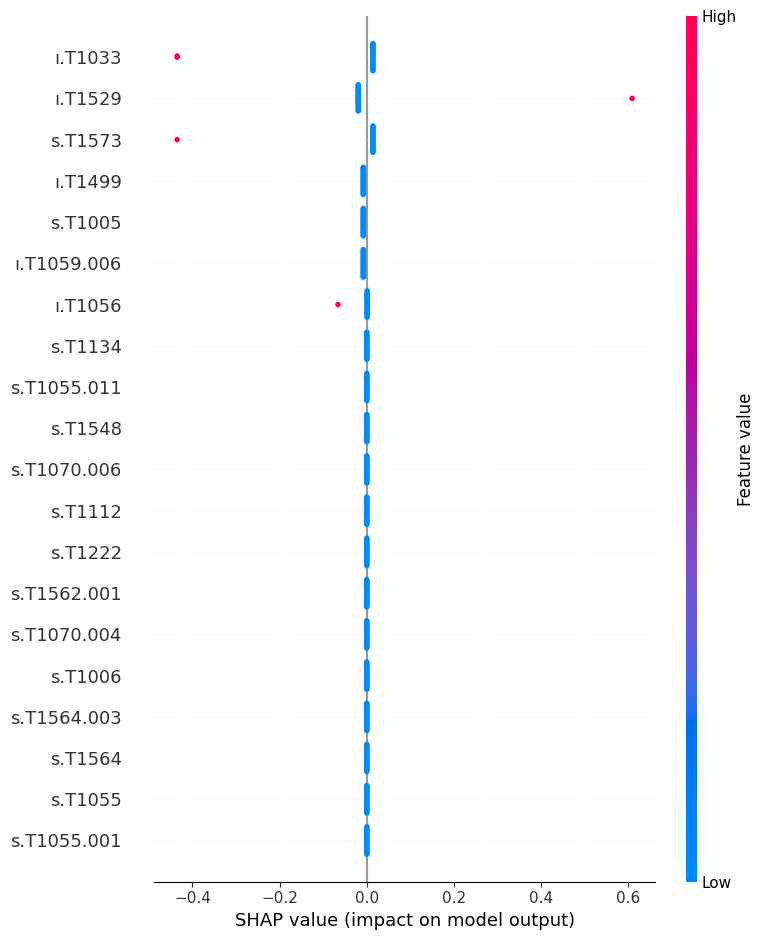

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


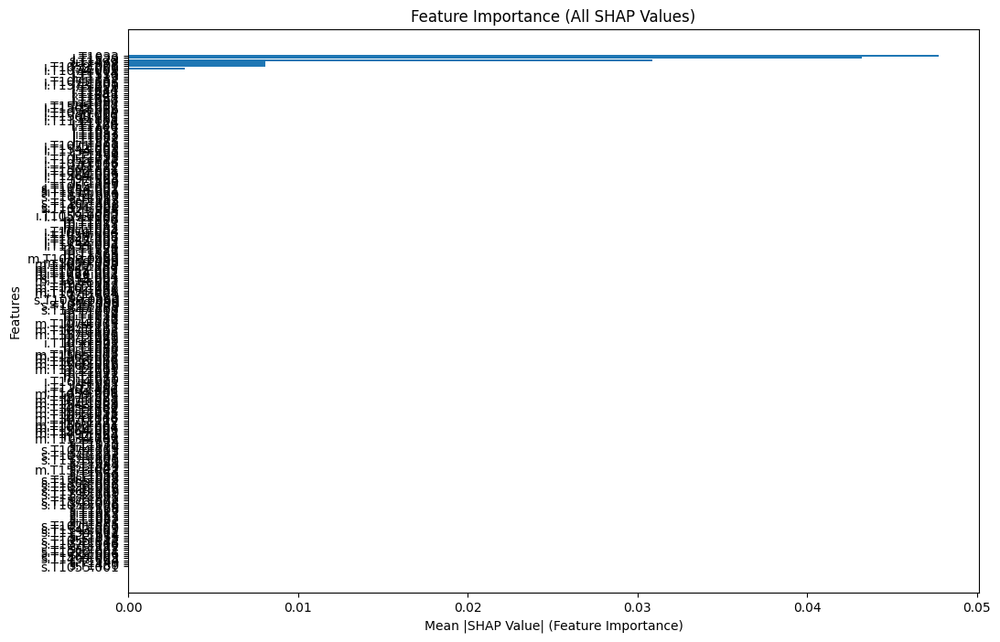

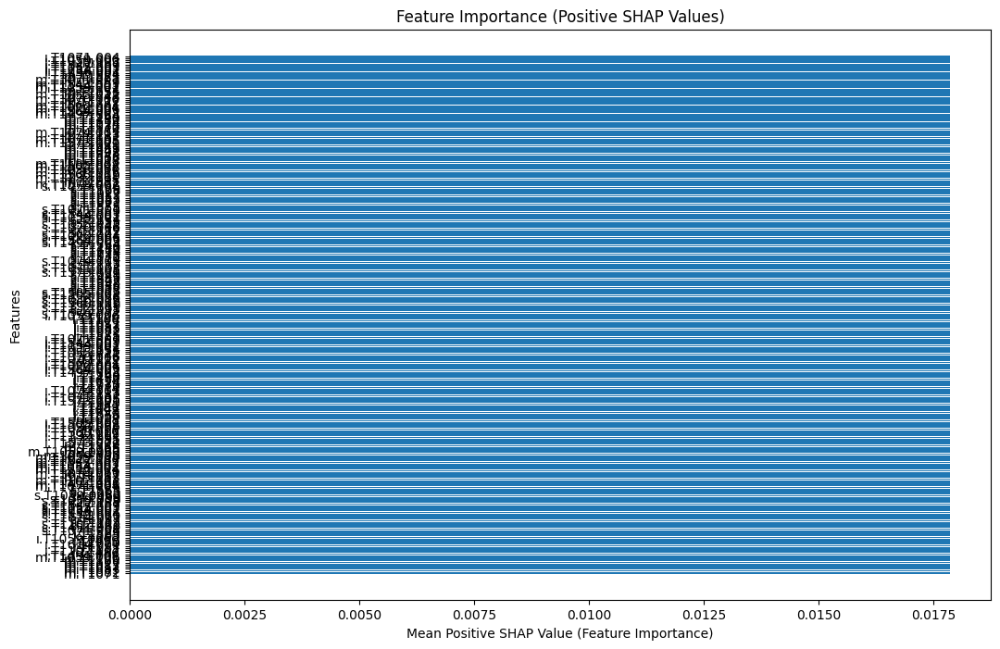


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25



In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np

# Dosya yolunu kontrol edin ve dosyayı okuyun
try:
    # DataFrame bilgilerini yazdırın
    df.info()
except FileNotFoundError:
    print("Belirtilen dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# Özellikleri ve etiketleri ayır
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

explainer = shap.LinearExplainer(best_model, X_train)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df_shap.index[:20]]
X_test_20 = X_test[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df_shap.index[:50]]
X_test_50 = X_test[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`smote+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
Confusion Matrix:
[[9 5]
 [8 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        14
           1       0.38      0.27      0.32        11

    accuracy                           0.48        25
   macro avg       0.45      0.46      0.45        25
weighted avg       0.46      0.48      0.46        25



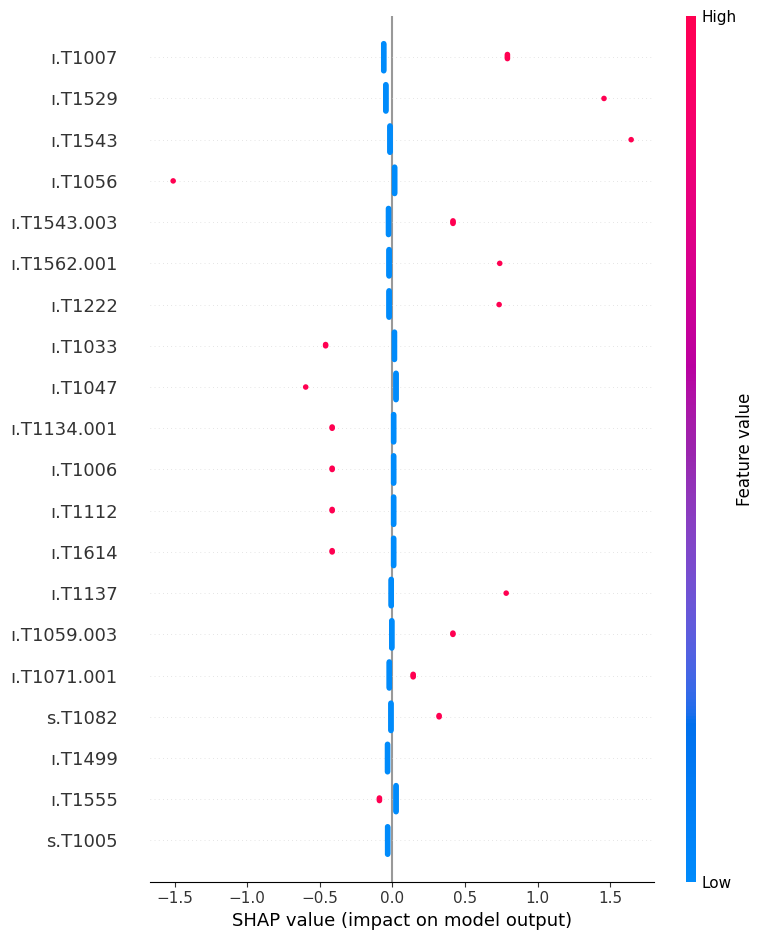

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


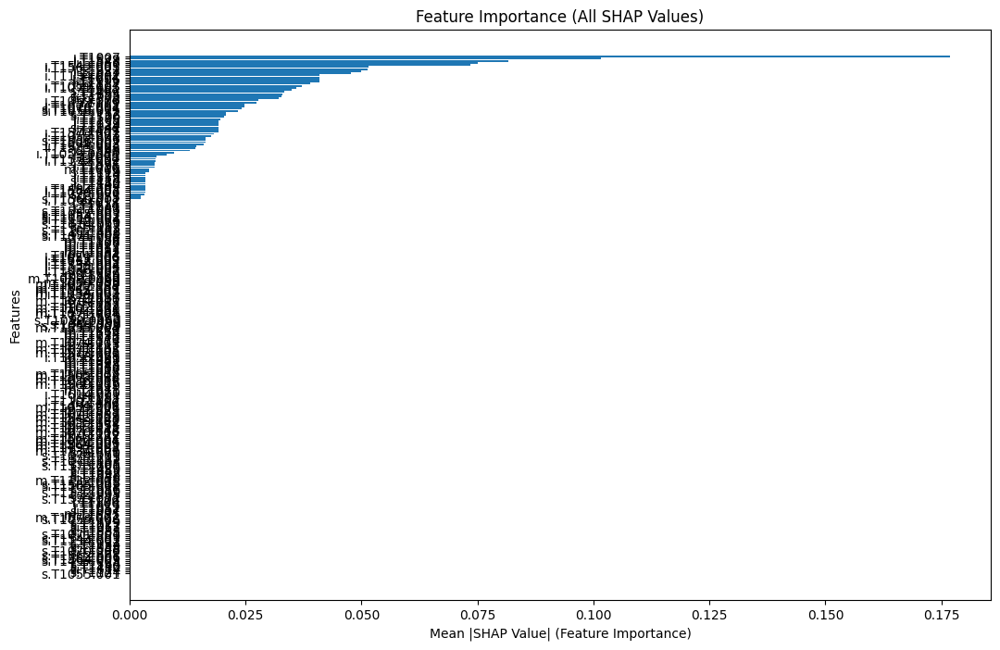

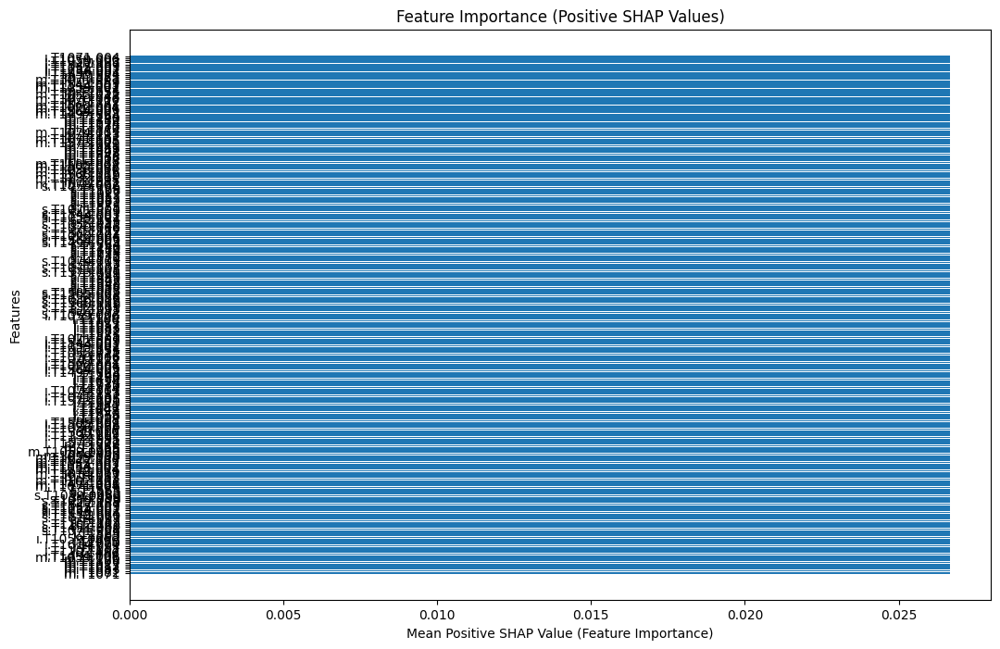


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 2 12]
 [ 3  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.14      0.21        14
           1       0.40      0.73      0.52        11

    accuracy                           0.40        25
   macro avg       0.40      0.44      0.36        25
weighted avg       0.40      0.40      0.34        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[ 1 13]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.12        14
           1       0.41      0.82      0.55        11

    accuracy                           0.40        25
   macro avg       0.37      0.44      0.33        25
weighted avg       0.37      0.40      0.31        25



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE ile veri artırma
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_train_resampled)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train[:, importance_df_shap.index[:20]]
X_test_20 = X_test[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train[:, importance_df_shap.index[:50]]
X_test_50 = X_test[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Borderline-SMOTE+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Confusion Matrix:
[[11  3]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.79      0.65        14
           1       0.40      0.18      0.25        11

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.45        25
weighted avg       0.48      0.52      0.47        25



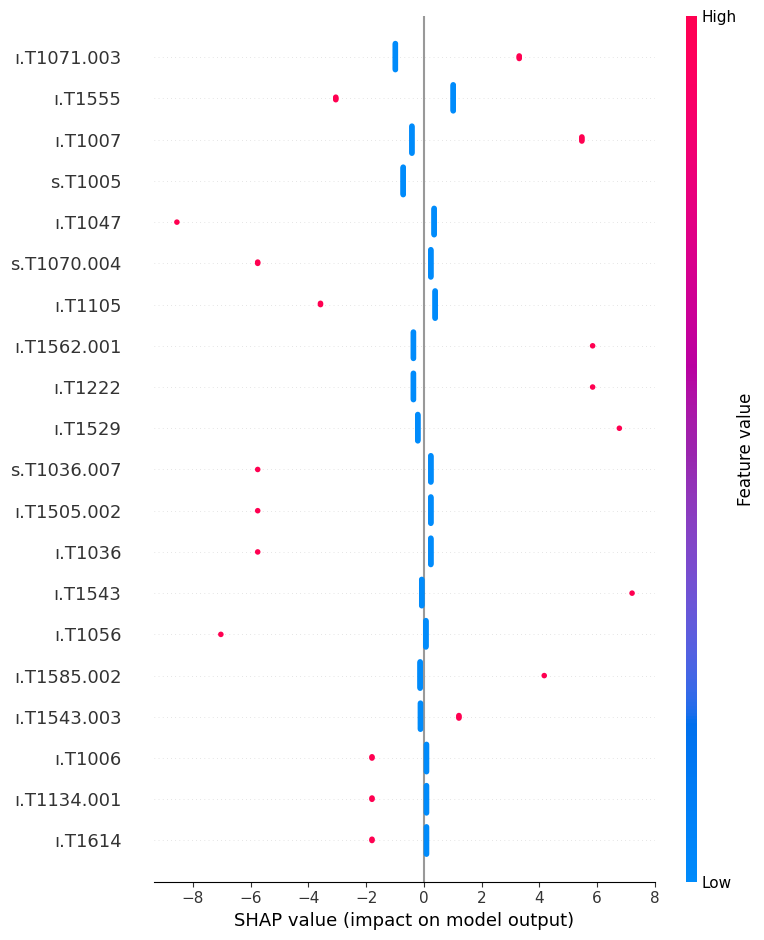

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


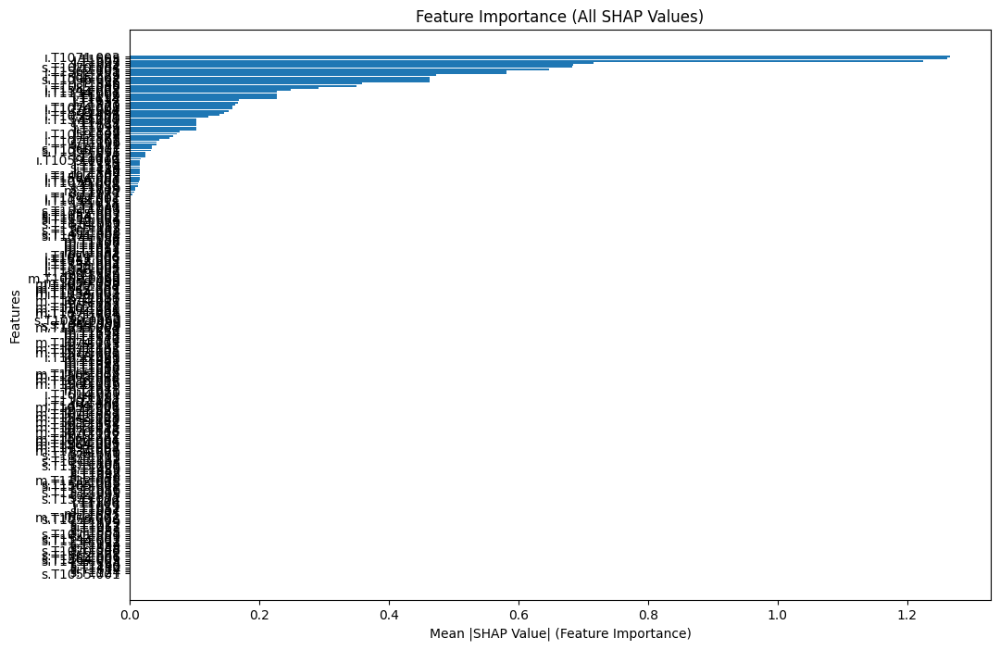

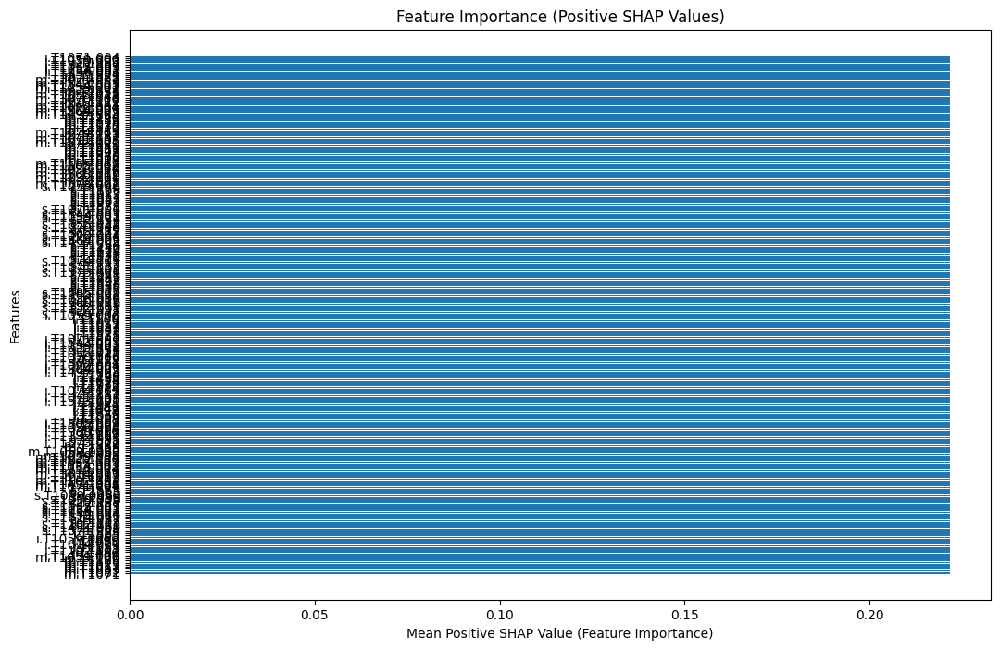


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 1 13]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.12        14
           1       0.41      0.82      0.55        11

    accuracy                           0.40        25
   macro avg       0.37      0.44      0.33        25
weighted avg       0.37      0.40      0.31        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[9 5]
 [8 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        14
           1       0.38      0.27      0.32        11

    accuracy                           0.48        25
   macro avg       0.45      0.46      0.45        25
weighted avg       0.46      0.48      0.46        25



In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# BorderlineSMOTE işlemi
borderline_smote = BorderlineSMOTE(random_state=42)
X_train_resampled, y_train_resampled = borderline_smote.fit_resample(X_train_scaled, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_resampled, y_train_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_train_resampled)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train_scaled[:, importance_df_shap.index[:20]]
X_test_20 = X_test_scaled[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train_scaled[:, importance_df_shap.index[:50]]
X_test_50 = X_test_scaled[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTENC+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
Confusion Matrix:
[[9 5]
 [8 3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.64      0.58        14
           1       0.38      0.27      0.32        11

    accuracy                           0.48        25
   macro avg       0.45      0.46      0.45        25
weighted avg       0.46      0.48      0.46        25



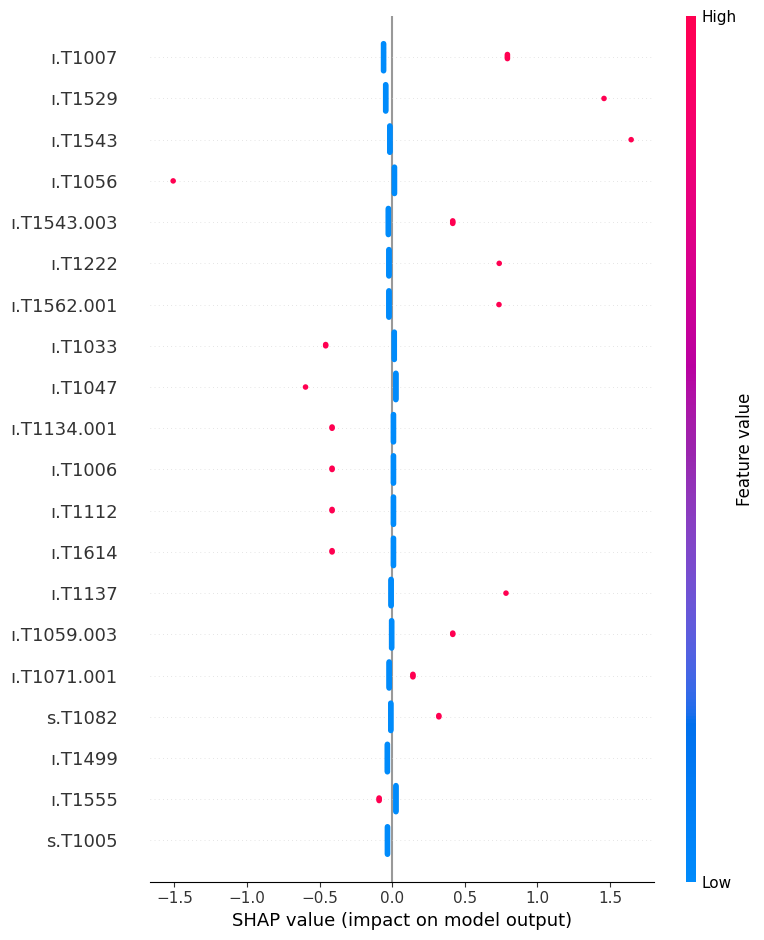

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


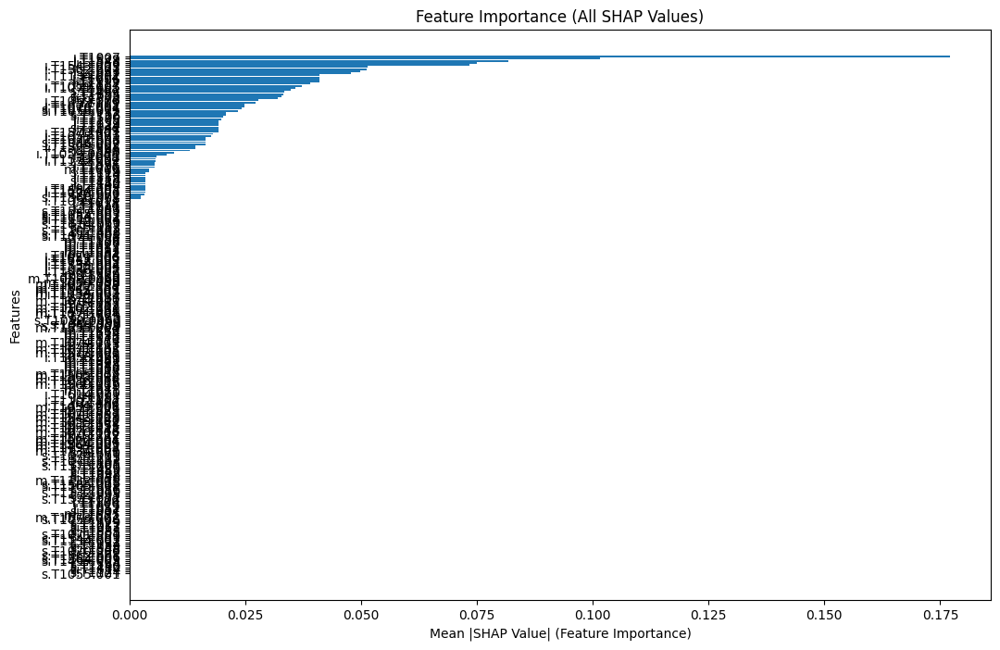

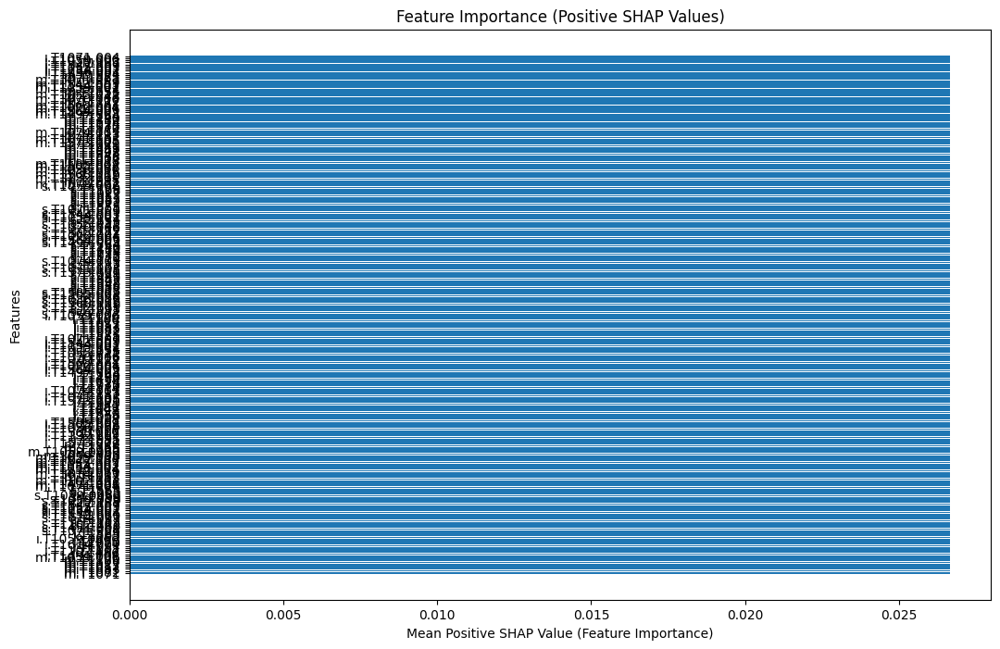


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 2 12]
 [ 3  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.14      0.21        14
           1       0.40      0.73      0.52        11

    accuracy                           0.40        25
   macro avg       0.40      0.44      0.36        25
weighted avg       0.40      0.40      0.34        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[ 1 13]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.07      0.12        14
           1       0.41      0.82      0.55        11

    accuracy                           0.40        25
   macro avg       0.37      0.44      0.33        25
weighted avg       0.37      0.40      0.31        25



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X_train_scaled, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_resampled)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train_scaled[:, importance_df_shap.index[:20]]
X_test_20 = X_test_scaled[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train_scaled[:, importance_df_shap.index[:50]]
X_test_50 = X_test_scaled[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`RandomOverSampler+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
19 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 1, 'l1_ratio': 0.5, 'max_iter': 100, 'penalty': 'elasticnet', 'solver': 'saga'}
Confusion Matrix:
[[11  3]
 [10  1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.79      0.63        14
           1       0.25      0.09      0.13        11

    accuracy                           0.48        25
   macro avg       0.39      0.44      0.38        25
weighted avg       0.40      0.48      0.41        25



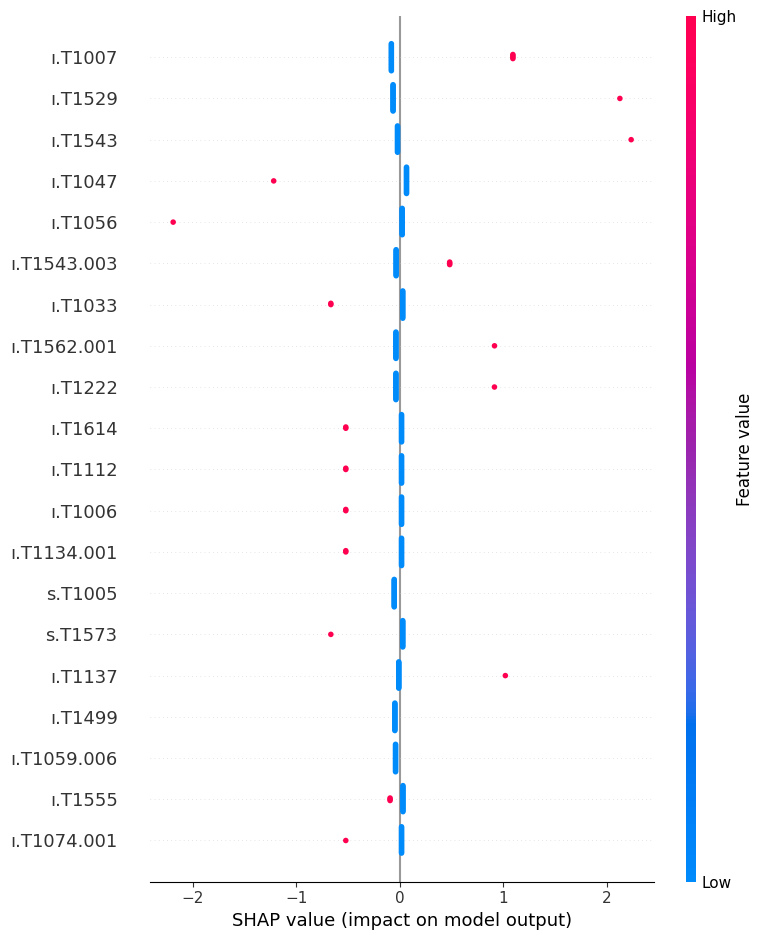

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


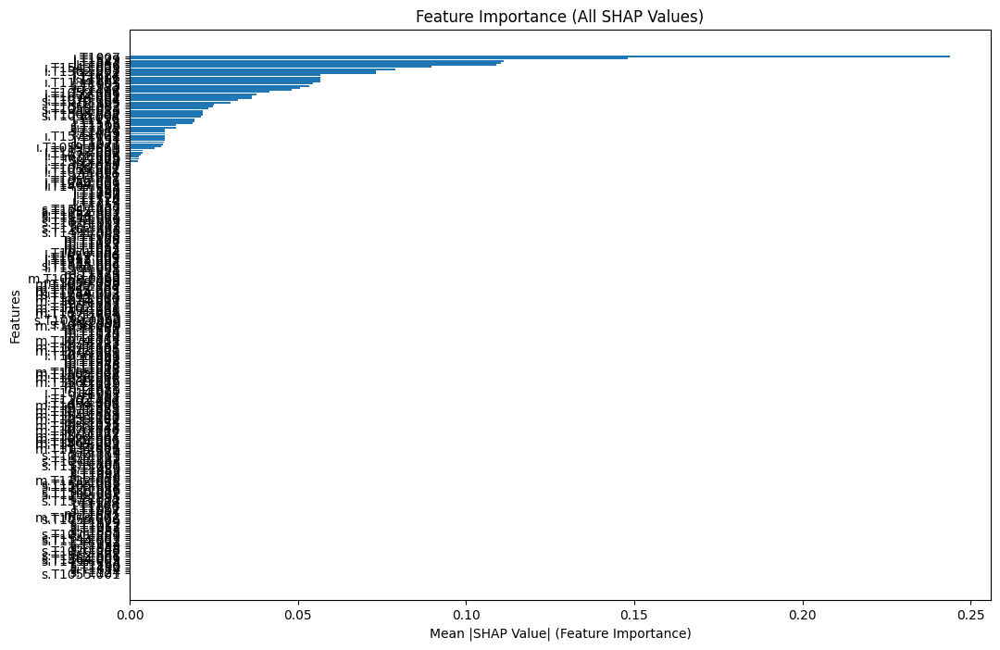

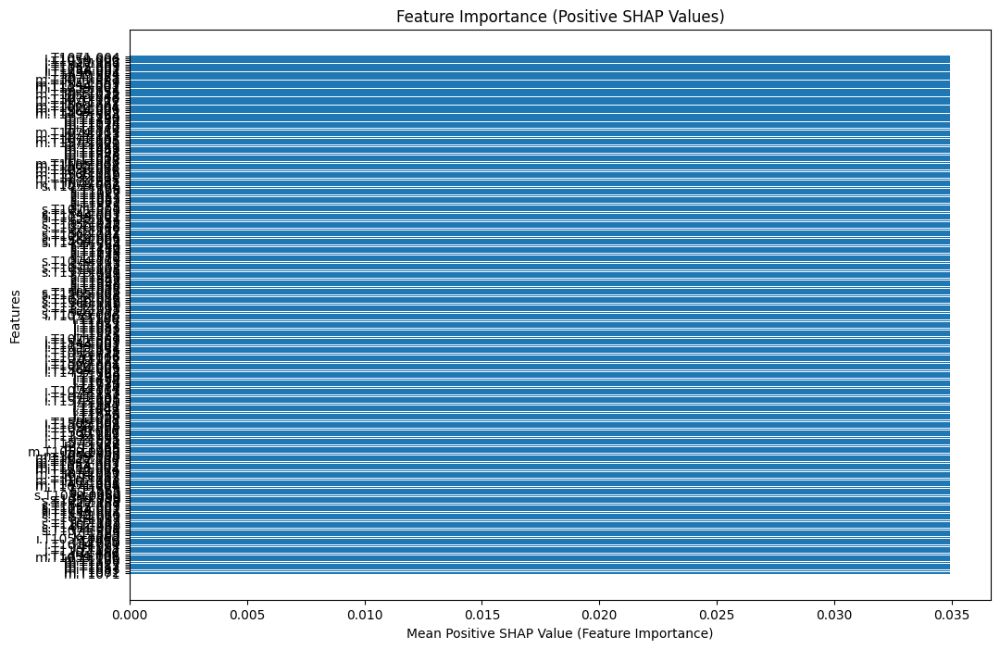


Model with Top 20 SHAP Features - Confusion Matrix:
[[12  2]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.50      0.18      0.27        11

    accuracy                           0.56        25
   macro avg       0.54      0.52      0.48        25
weighted avg       0.54      0.56      0.50        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[11  3]
 [ 9  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.79      0.65        14
           1       0.40      0.18      0.25        11

    accuracy                           0.52        25
   macro avg       0.48      0.48      0.45        25
weighted avg       0.48      0.52      0.47        25



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Over Sampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_scaled, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_resampled)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train_scaled[:, importance_df_shap.index[:20]]
X_test_20 = X_test_scaled[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train_scaled[:, importance_df_shap.index[:50]]
X_test_50 = X_test_scaled[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`Tomek Links+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
23 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 200, 'penalty': 'elasticnet', 'solver': 'saga'}
Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25



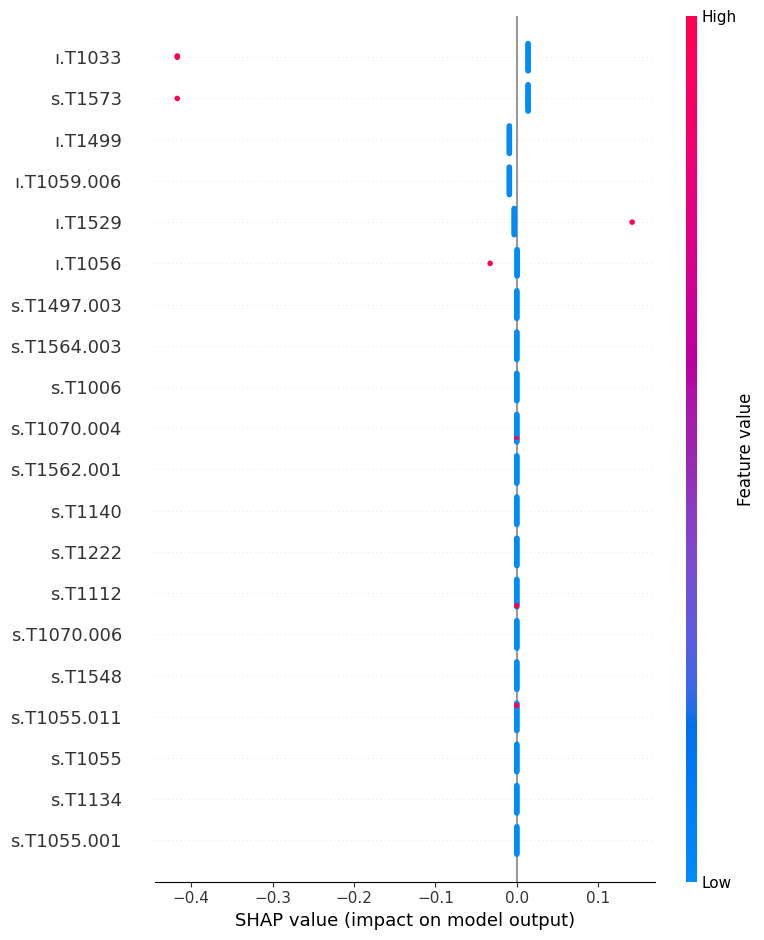

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


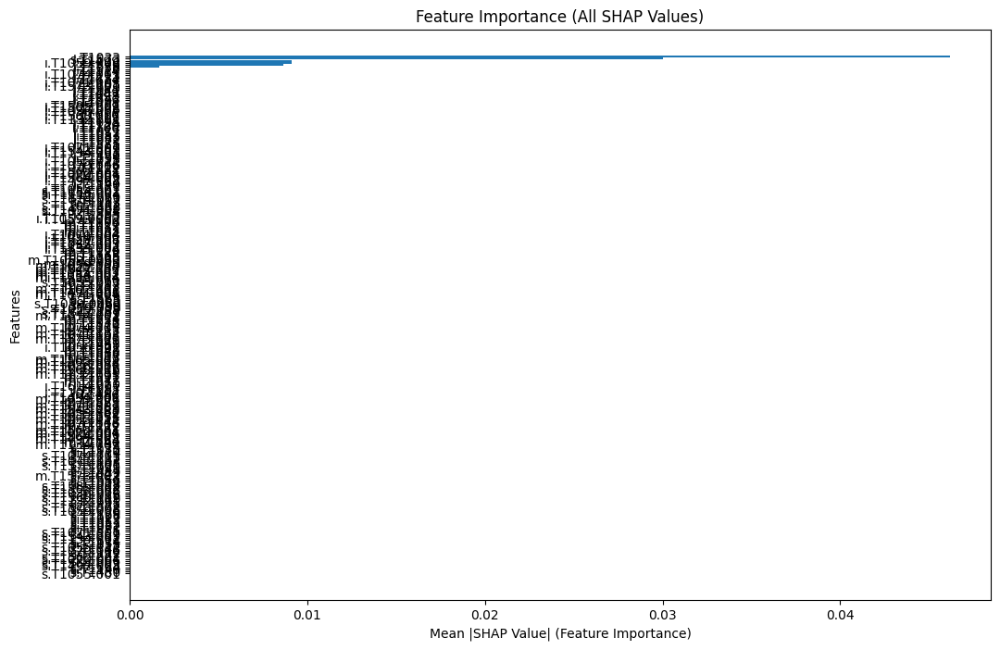

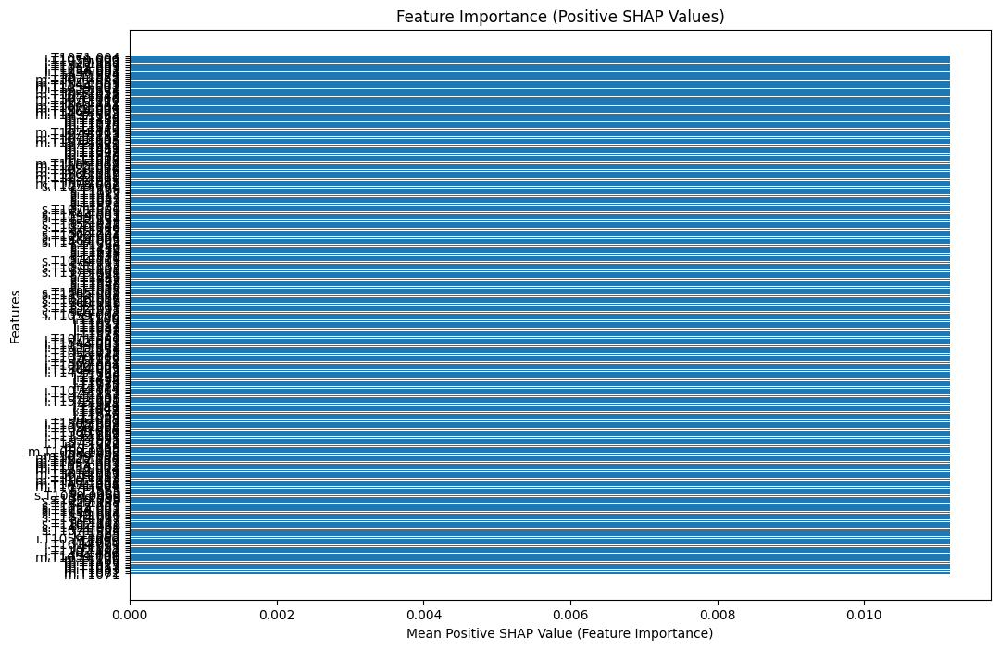


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25



In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tomek Links ile veri dengesizliğini düzeltme
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X_train_scaled, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_resampled)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train_scaled[:, importance_df_shap.index[:20]]
X_test_20 = X_test_scaled[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train_scaled[:, importance_df_shap.index[:50]]
X_test_50 = X_test_scaled[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`SMOTETomek+shap`***

Fitting 3 folds for each of 117 candidates, totalling 351 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
36 fits failed out of a total of 351.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
17 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

Best parameters found:  {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
Confusion Matrix:
[[9 5]
 [9 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.64      0.56        14
           1       0.29      0.18      0.22        11

    accuracy                           0.44        25
   macro avg       0.39      0.41      0.39        25
weighted avg       0.41      0.44      0.41        25



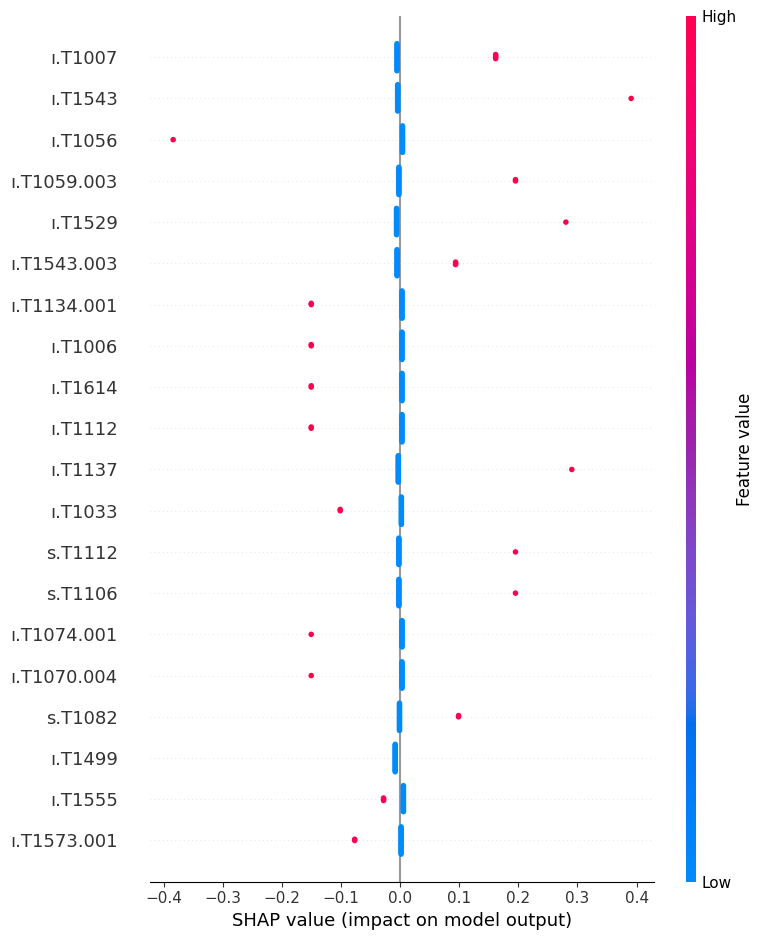

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


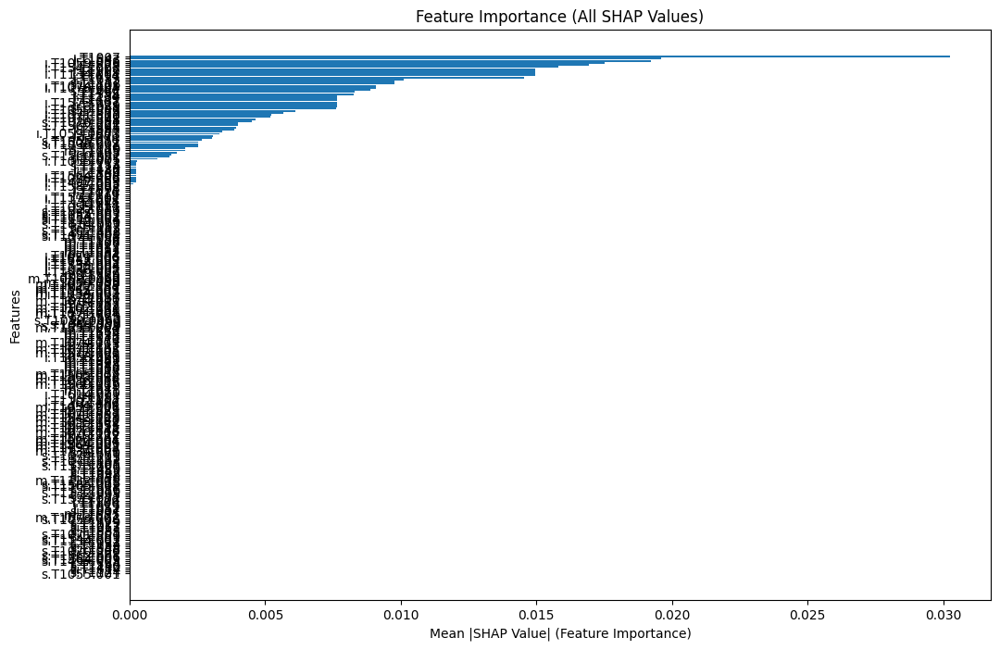

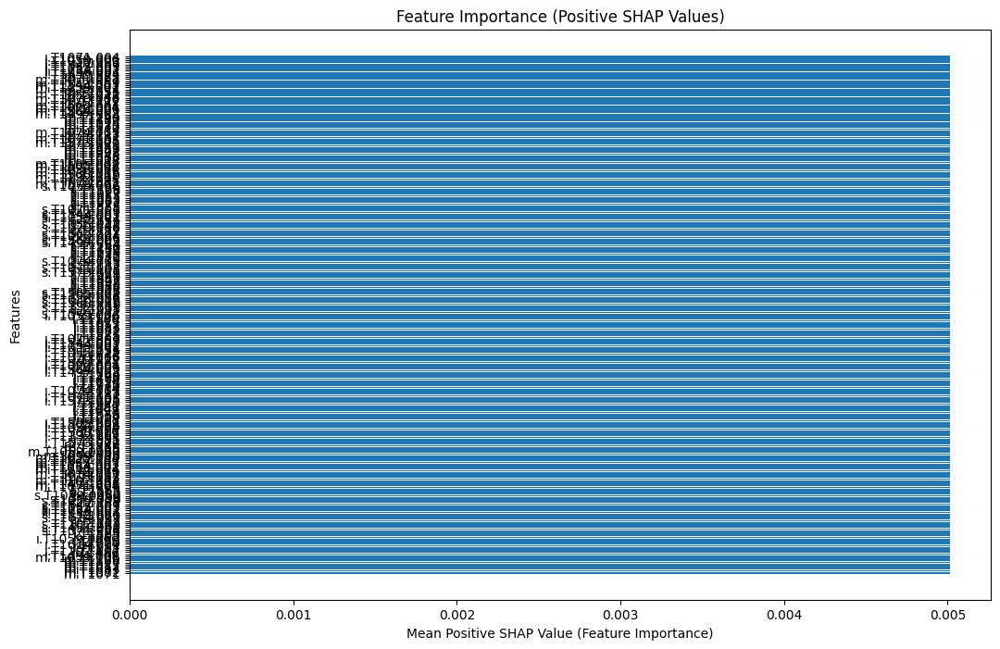


Model with Top 20 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25


Model with Top 50 SHAP Features - Confusion Matrix:
[[ 0 14]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25



In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
import shap
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE-Tomek örnekleme
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train_scaled, y_train)

# Hiperparametre ızgarası
param_grid = [
    {'penalty': ['l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['saga'], 'l1_ratio': [0.5], 'max_iter': [100, 200, 300]},
    {'penalty': ['none'], 'solver': ['newton-cg', 'lbfgs', 'sag', 'saga'], 'max_iter': [100, 200, 300]}
]

# Grid Search
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# SHAP ile Feature Importance
best_model = grid_search.best_estimator_

# SHAP LinearExplainer kullanıyoruz
explainer = shap.LinearExplainer(best_model, X_resampled)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# Tüm SHAP değerlerini hesaplayalım
shap_values_abs = np.abs(shap_values)
mean_shap_values = np.mean(shap_values_abs, axis=0)

# SHAP feature importance dataframe (Tüm feature'lar)
importance_df_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_shap_values})
importance_df_shap = importance_df_shap.sort_values(by='Importance', ascending=False)

# Pozitif SHAP değerlerini hesaplayalım
positive_shap_values = shap_values[shap_values > 0]  # Pozitif SHAP değerleri
mean_positive_shap_values = np.mean(np.abs(positive_shap_values), axis=0)

# Pozitif SHAP değerli feature importance dataframe
importance_df_positive_shap = pd.DataFrame({'Feature': X.columns, 'Importance': mean_positive_shap_values})
importance_df_positive_shap = importance_df_positive_shap.sort_values(by='Importance', ascending=False)

# Tüm SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_shap['Feature'], importance_df_shap['Importance'])
plt.xlabel("Mean |SHAP Value| (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (All SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# Pozitif SHAP değerli feature'lar için bar grafiği
plt.figure(figsize=(12, 8))
plt.barh(importance_df_positive_shap['Feature'], importance_df_positive_shap['Importance'])
plt.xlabel("Mean Positive SHAP Value (Feature Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Positive SHAP Values)")
plt.gca().invert_yaxis()  # En önemli öznitelikler üstte olsun
plt.show()

# En önemli 20 ve 50 özellikleri seçme
top_20_features_shap = importance_df_shap['Feature'].iloc[:20]
top_50_features_shap = importance_df_shap['Feature'].iloc[:50]

# En önemli 20 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_20 = X_train_scaled[:, importance_df_shap.index[:20]]
X_test_20 = X_test_scaled[:, importance_df_shap.index[:20]]

best_model_20 = LogisticRegression(**best_params)
best_model_20.fit(X_train_20, y_train)
y_pred_20 = best_model_20.predict(X_test_20)

print("\nModel with Top 20 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_20))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_20))

# En önemli 50 pozitif SHAP değeri ile modeli yeniden eğitme
X_train_50 = X_train_scaled[:, importance_df_shap.index[:50]]
X_test_50 = X_test_scaled[:, importance_df_shap.index[:50]]

best_model_50 = LogisticRegression(**best_params)
best_model_50.fit(X_train_50, y_train)
y_pred_50 = best_model_50.predict(X_test_50)

print("\nModel with Top 50 SHAP Features - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_50))


# ***`XGBoost (Extreme Gradient Boosting)`***

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Modeli eğitin
xgb_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendirin
y_pred = xgb_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 0 14]
 [ 0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 0 14]
 [ 0 11]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25


İlk 20 özellik ile sonuçlar:
[[ 0 14]
 [ 0 11]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.44      1.00      0.61        11

    accuracy                           0.44        25
   macro avg       0.22      0.50      0.31        25
weighted avg       0.19      0.44      0.27        25


İlk 50 özellik ile sonuçlar:
[[ 0 14]
 [ 0 11]]
              precision    recall  f1-score   suppo

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

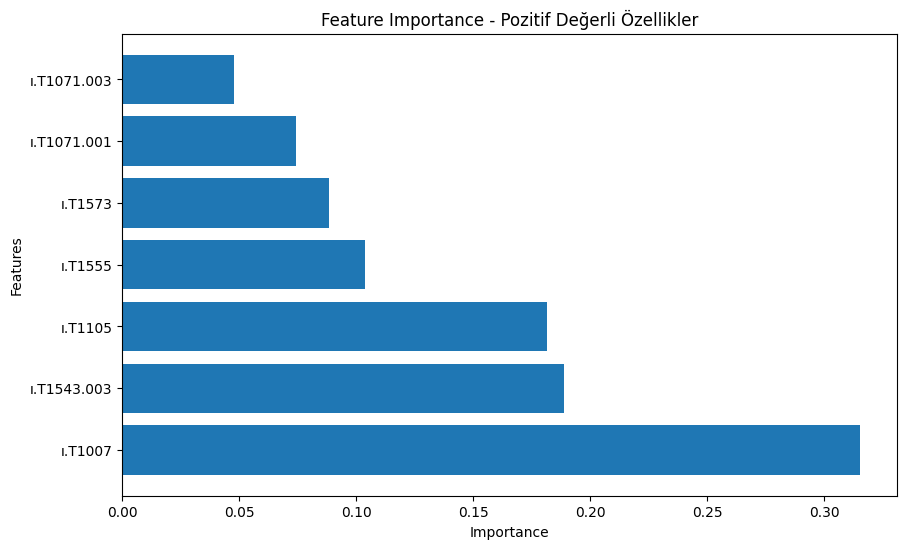

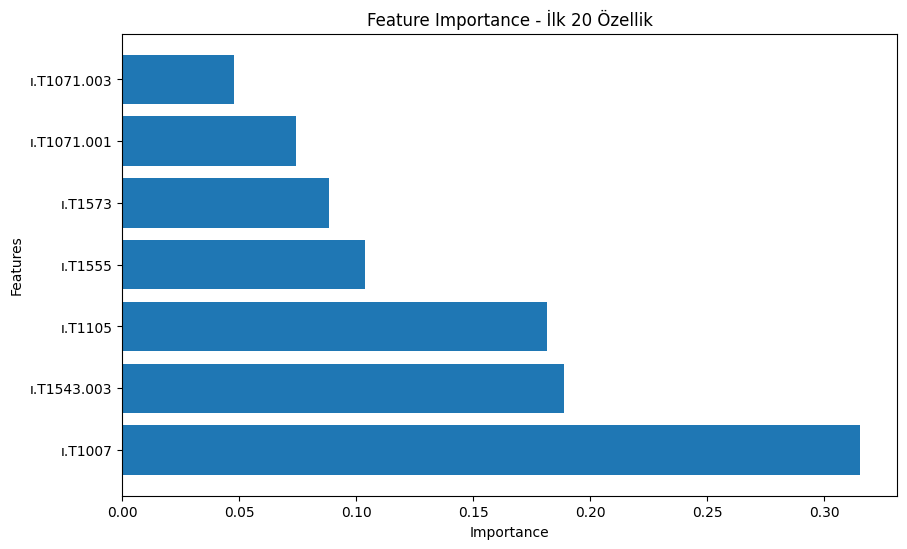

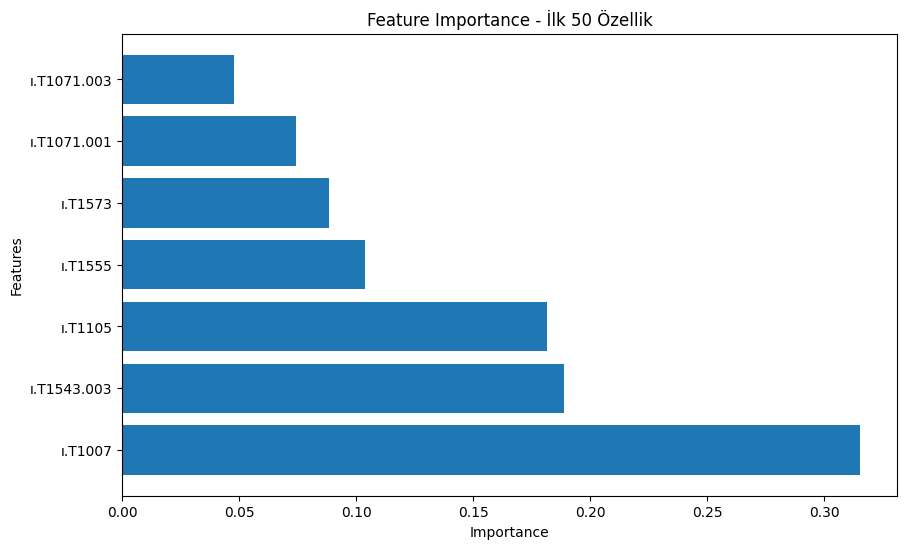

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`SMOTE`***

Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25


İlk 20 özellik ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


İlk 50 özellik ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
<ipython-input-60-5d3a45e3fe86>:87: SettingWithCo

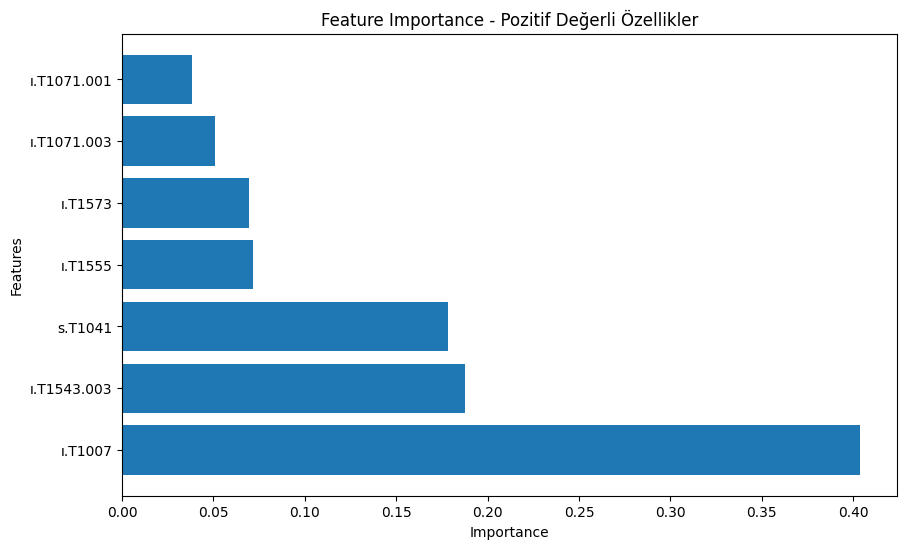

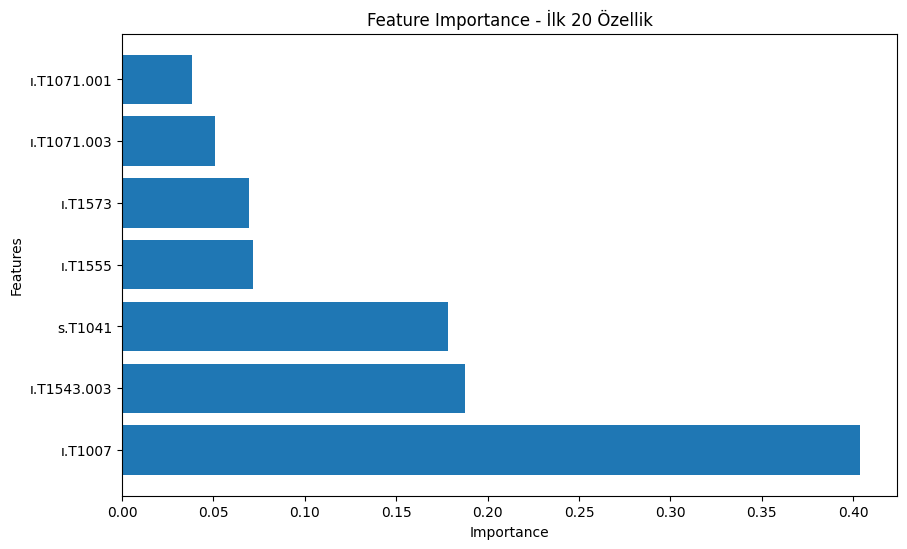

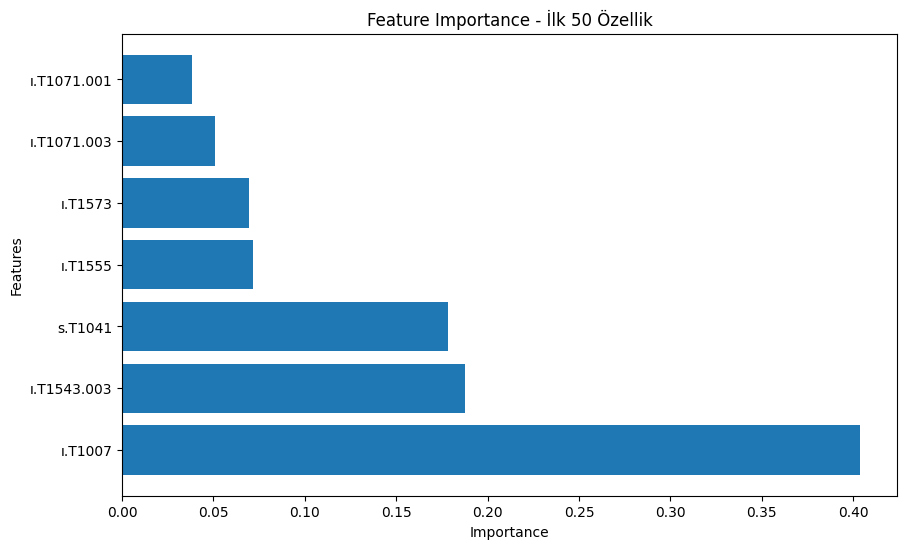

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Veri artırma işlemi
smote = SMOTE(random_state=42)
X_artirilmis, y_artirilmis = smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_artirilmis, y_artirilmis, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`Borderline-SMOTE`***

Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



İlk 20 özellik ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25


İlk 50 özellik ile sonuçlar:
[[ 0 17]
 [ 0  8]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

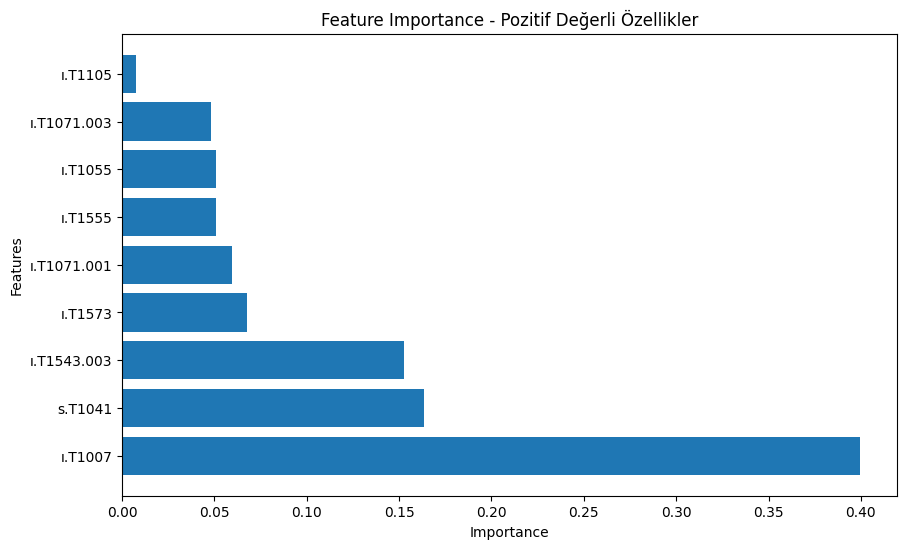

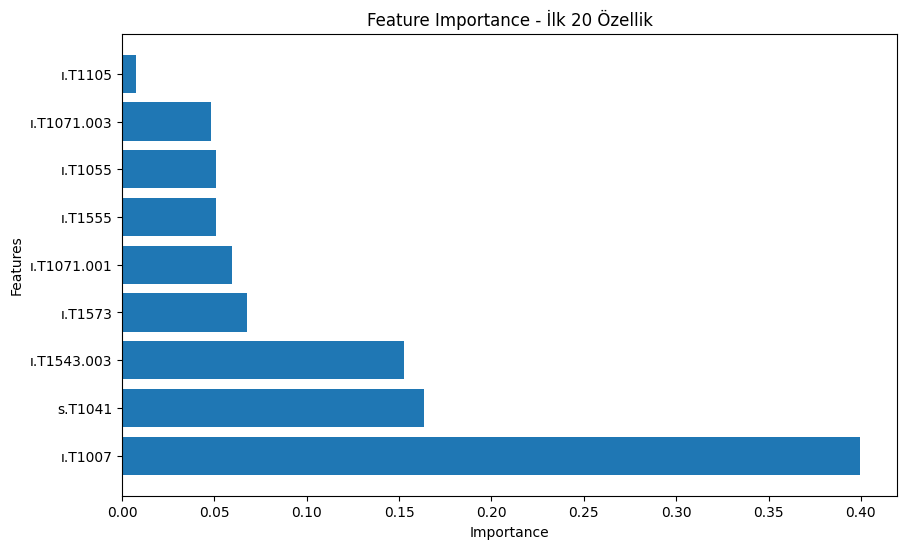

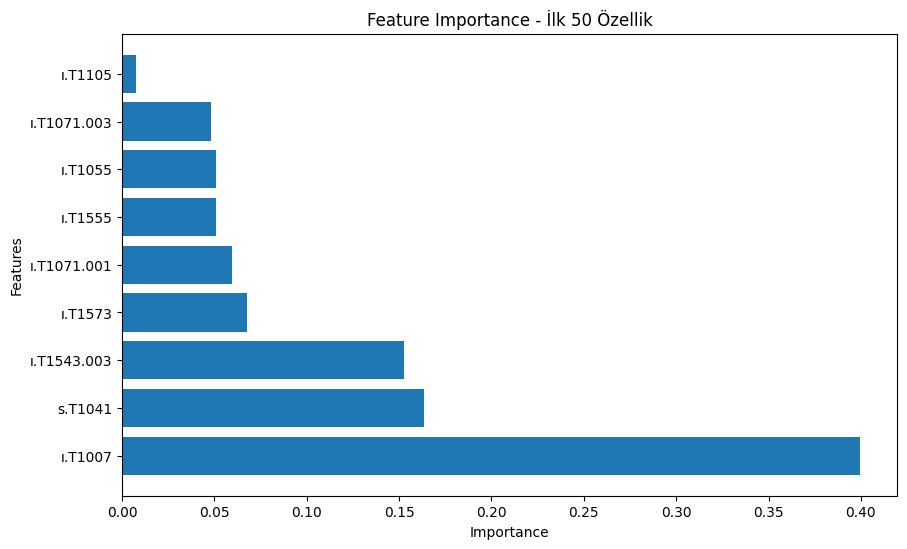

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# BorderlineSMOTE ile veri kümesini artırın
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Artırılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`SMOTENC (SMOTE for Nominal and Continuous)`***

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Artırılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Karmaşıklık Matrisi:
[[ 0 17]
 [ 0  8]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Karmaşıklık Matrisi:
[[ 0 17]
 [ 0  8]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


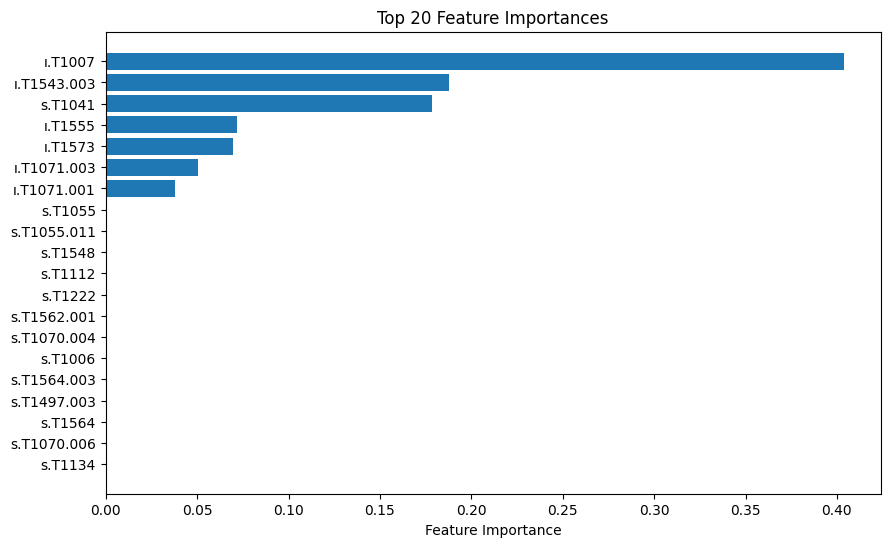

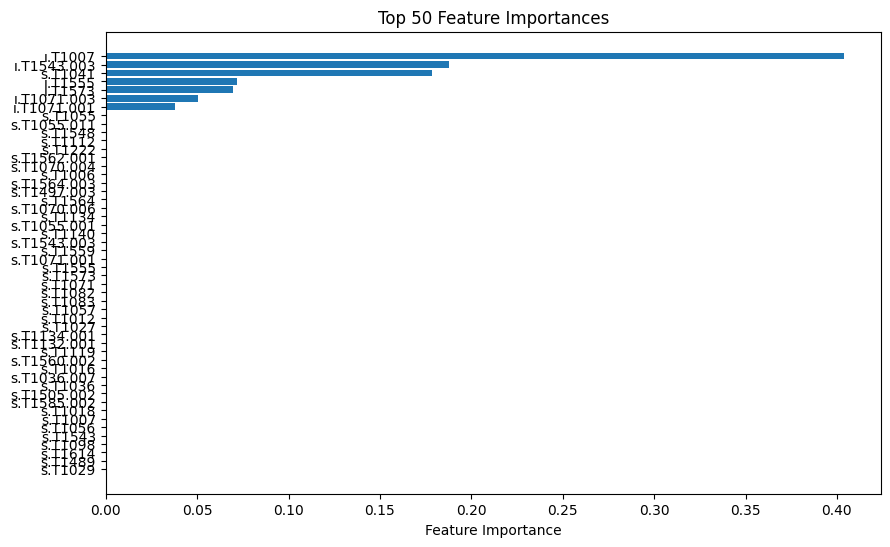

Fitting 3 folds for each of 80 candidates, totalling 240 fits
Pozitif Feature'lar ile Karmaşıklık Matrisi:
[[ 0 17]
 [ 0  8]]

Pozitif Feature'lar ile Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.32      1.00      0.48         8

    accuracy                           0.32        25
   macro avg       0.16      0.50      0.24        25
weighted avg       0.10      0.32      0.16        25



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)
y = df['Malicious']

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Artırılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesapla
feature_importances = grid_search.best_estimator_.feature_importances_
feature_names = X.columns

# Pozitif feature importances seçin
positive_features = feature_names[feature_importances > 0]
positive_importances = feature_importances[feature_importances > 0]

# İlk 20 ve ilk 50 feature'ı seç
top_20_features = np.argsort(feature_importances)[-20:]
top_50_features = np.argsort(feature_importances)[-50:]

# İlk 20 ve 50'yi bar grafiği ile göster
def plot_feature_importance(indices, importances, names, title):
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), names[indices])
    plt.xlabel("Feature Importance")
    plt.title(title)
    plt.show()

# Pozitif feature'lar ve tüm feature'lar için görselleştirme
plot_feature_importance(top_20_features, feature_importances, feature_names, "Top 20 Feature Importances")
plot_feature_importance(top_50_features, feature_importances, feature_names, "Top 50 Feature Importances")

# Sadece pozitif feature'lar ile modeli tekrar çalıştır
X_pos = X[positive_features]
X_egitim_pos, X_test_pos, y_egitim_pos, y_test_pos = train_test_split(X_resampled[positive_features], y_resampled, test_size=0.2, random_state=42)

# Modeli pozitif feature'larla yeniden eğit
grid_search_pos = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search_pos.fit(X_egitim_pos, y_egitim_pos)

# Pozitif feature'larla tahminler
y_pred_pos = grid_search_pos.predict(X_test_pos)

# Sonuçları göster
print("Pozitif Feature'lar ile Karmaşıklık Matrisi:")
print(confusion_matrix(y_test_pos, y_pred_pos))
print("\nPozitif Feature'lar ile Sınıflandırma Raporu:")
print(classification_report(y_test_pos, y_pred_pos))


***`RandomOverSampler`***

Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 1 16]
 [ 0  8]]
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


İlk 20 özellik ile sonuçlar:
[[ 1 16]
 [ 0  8]]
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        17
           1       0.33      1.00      0.50         8

    accuracy                           0.36        25
   macro avg       0.67      0.53      0.31        25
weighted avg       0.79      0.36      0.24        25


İlk 50 özellik ile sonuçlar:
[[ 1 16]
 [ 0  8]]
              precision    recall  f1-score   suppo

<ipython-input-64-9b89fbdc363b>:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


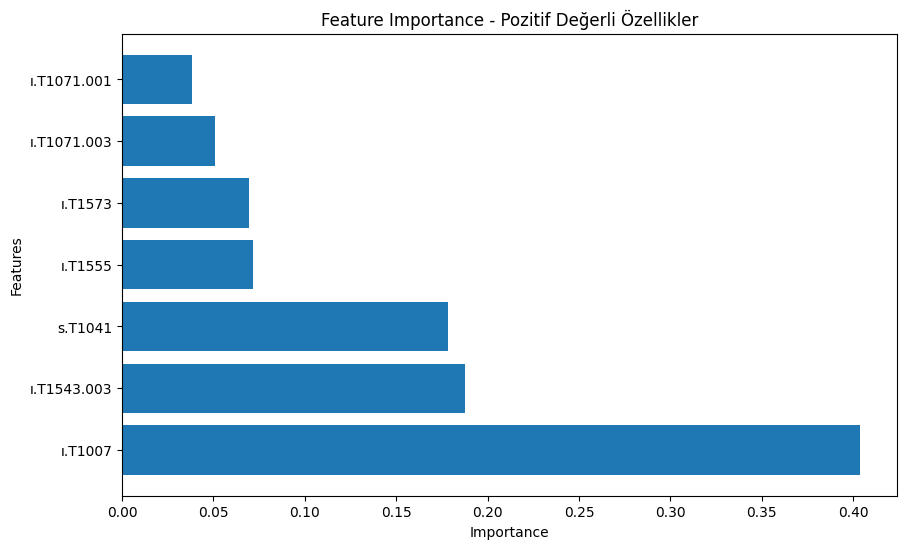

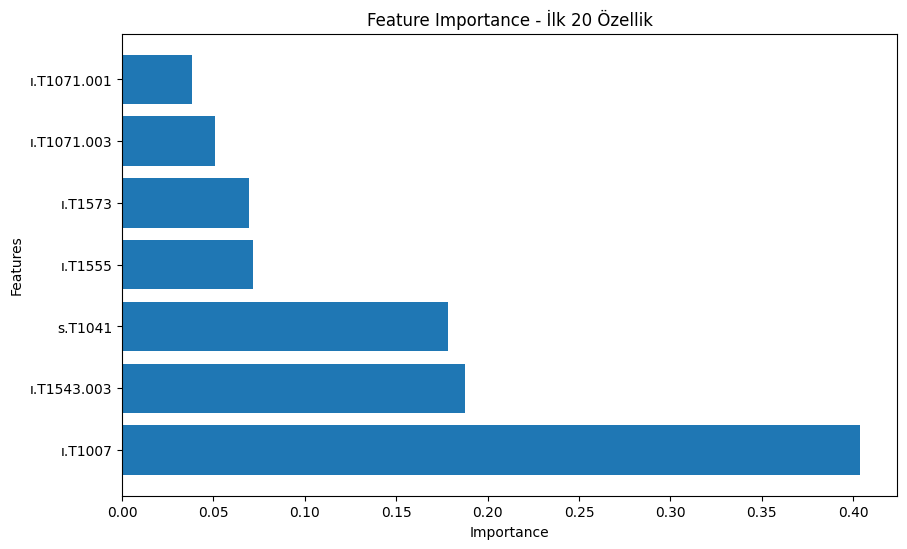

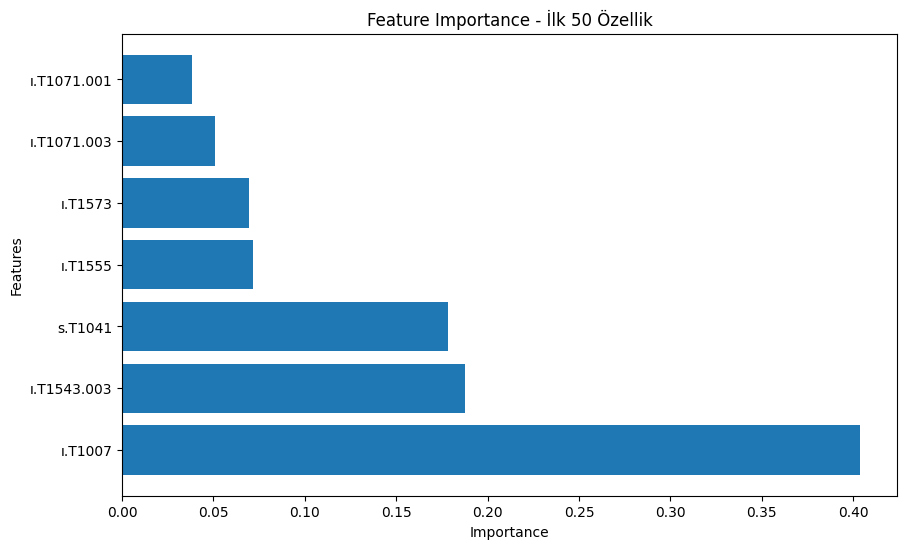

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# RandomOverSampler ile veri kümesini artırın
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Artırılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`Tomek Links`***

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)
y = df['Malicious']

tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Azaltılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.0001, 'max_depth': 3, 'n_estimators': 100}
Karmaşıklık Matrisi:
[[ 0 12]
 [ 0 12]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.50      1.00      0.67        12

    accuracy                           0.50        24
   macro avg       0.25      0.50      0.33        24
weighted avg       0.25      0.50      0.33        24



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.0001, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 0 12]
 [ 0 12]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.50      1.00      0.67        12

    accuracy                           0.50        24
   macro avg       0.25      0.50      0.33        24
weighted avg       0.25      0.50      0.33        24


İlk 20 özellik ile sonuçlar:
[[ 0 12]
 [ 0 12]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.50      1.00      0.67        12

    accuracy                           0.50        24
   macro avg       0.25      0.50      0.33        24
weighted avg       0.25      0.50      0.33        24


İlk 50 özellik ile sonuçlar:
[[ 0 12]
 [ 0 12]]
              precision    recall  f1-score   su

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

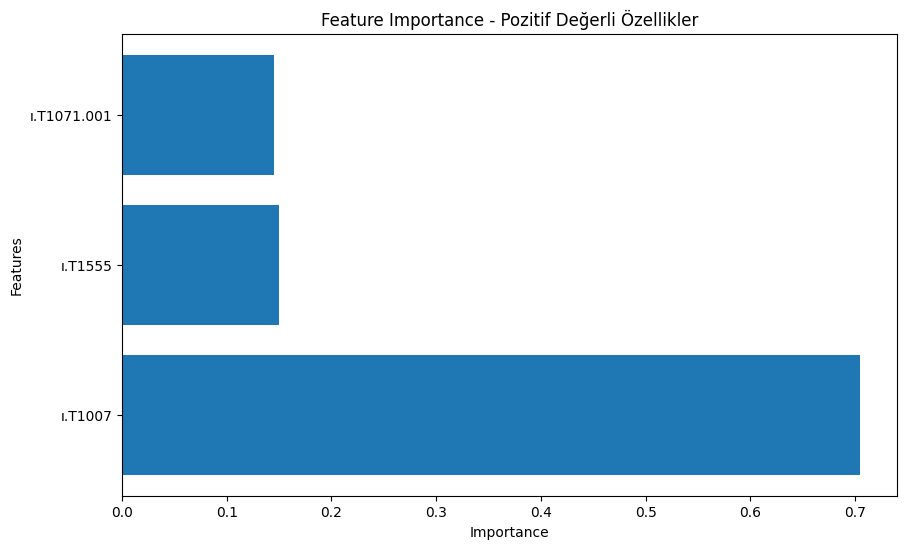

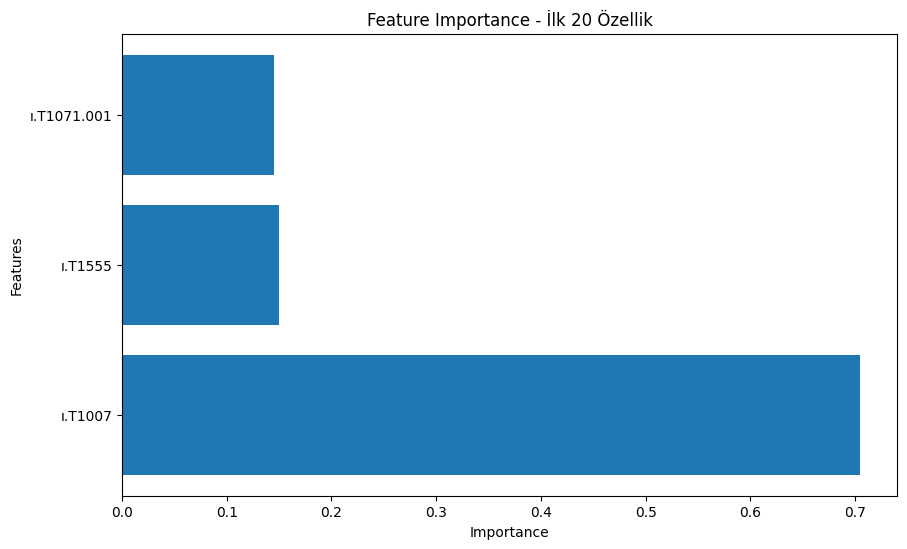

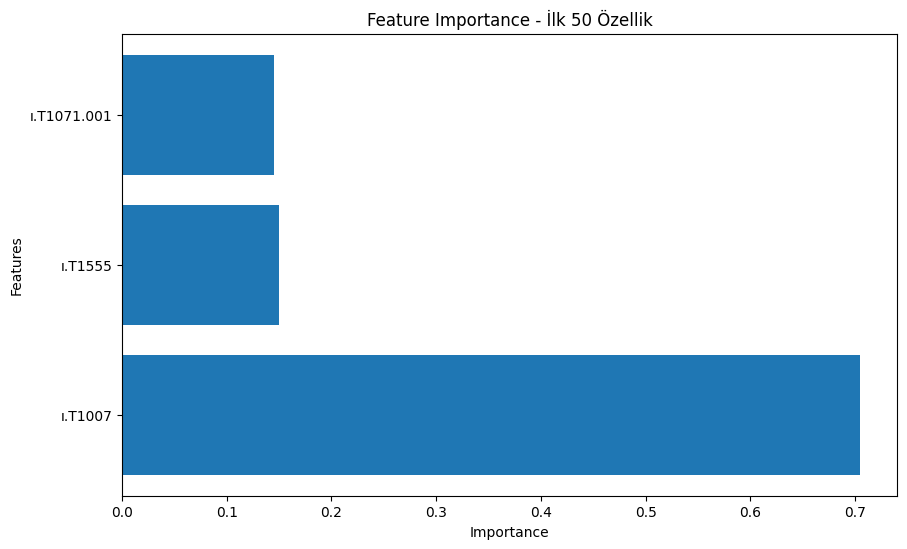

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Tomek Links ile veri kümesini azaltın
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Azaltılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


**`*Combination of Over- and Under-Sampling (SMOTE + Tomek Links)*`**

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)
y = df['Malicious']

smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırın (Azaltılmış veriyi kullanın)
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100}
Karmaşıklık Matrisi:
[[ 0 13]
 [ 0 11]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.46      1.00      0.63        11

    accuracy                           0.46        24
   macro avg       0.23      0.50      0.31        24
weighted avg       0.21      0.46      0.29        24



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Fitting 3 folds for each of 80 candidates, totalling 240 fits
En iyi parametreler:  {'learning_rate': 0.001, 'max_depth': 3, 'n_estimators': 100}

Pozitif özellikler ile sonuçlar:
[[ 0 13]
 [ 0 11]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.46      1.00      0.63        11

    accuracy                           0.46        24
   macro avg       0.23      0.50      0.31        24
weighted avg       0.21      0.46      0.29        24



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m


İlk 20 özellik ile sonuçlar:
[[ 0 13]
 [ 0 11]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.46      1.00      0.63        11

    accuracy                           0.46        24
   macro avg       0.23      0.50      0.31        24
weighted avg       0.21      0.46      0.29        24


İlk 50 özellik ile sonuçlar:
[[ 0 13]
 [ 0 11]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.46      1.00      0.63        11

    accuracy                           0.46        24
   macro avg       0.23      0.50      0.31        24
weighted avg       0.21      0.46      0.29        24



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
<ipython-input-68-b8cc5a35c0bb>:86: SettingWithCo

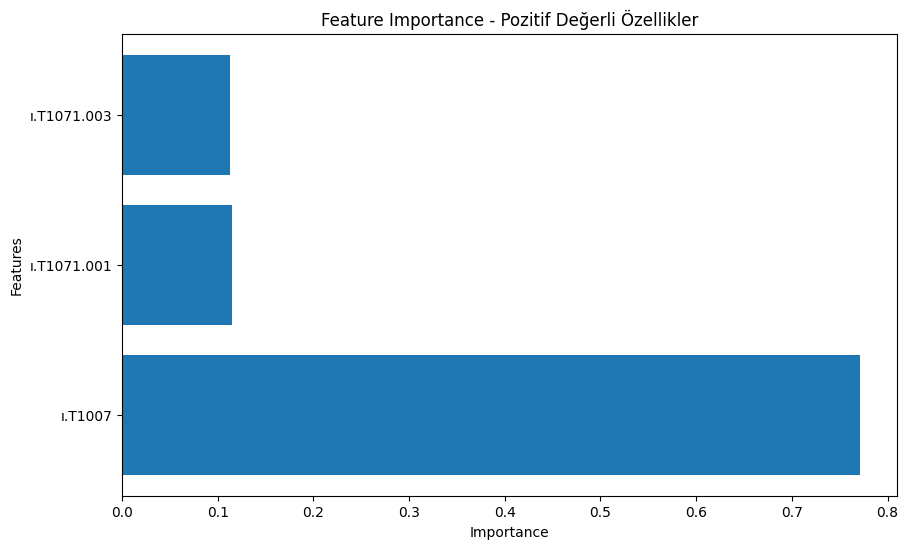

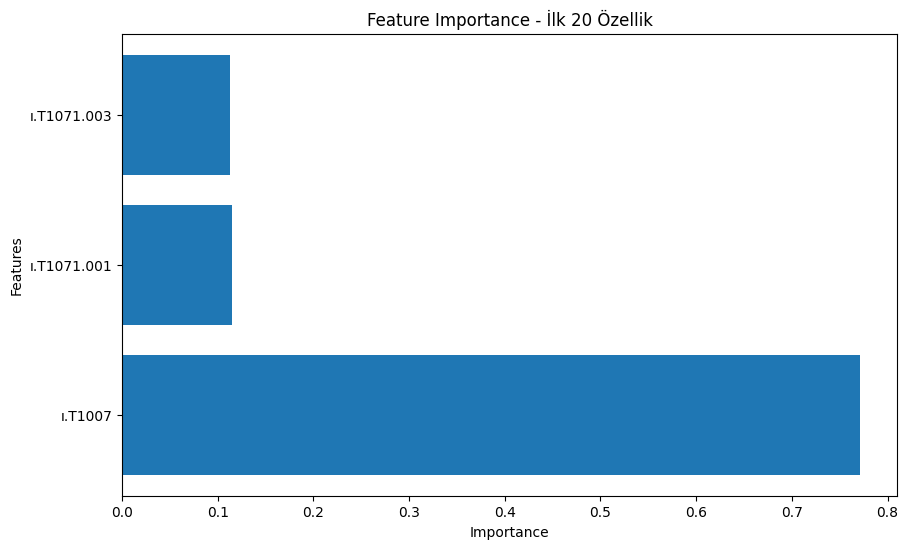

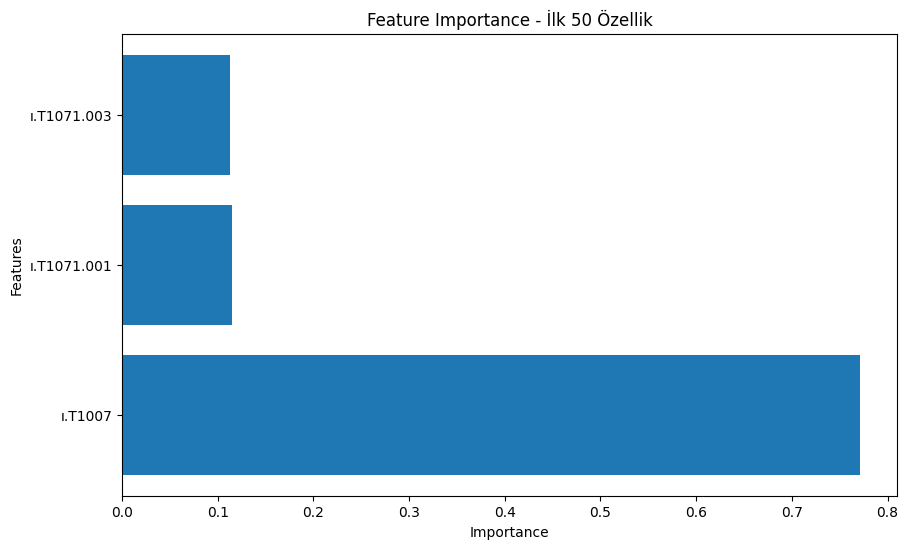

In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# SMOTETomek ile veri kümesini dengeleyin
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# XGBoost modelini oluşturun
xgb_model = XGBClassifier()

# Grid Search için parametre ızgarası
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.1, 0.01, 0.001, 0.0001],
    'n_estimators': [100, 200, 300, 400, 500]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi modeli al
best_model = grid_search.best_estimator_

# Feature importance hesaplama
importances = best_model.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
best_model.fit(X_egitim_pos, y_egitim)
y_pred_pos = best_model.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
best_model.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = best_model.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
best_model.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = best_model.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


# ***`AdaBoost (Adaptive Boosting)`***

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# AdaBoost modelini oluşturun
adaboost_model = AdaBoostClassifier()

# Modeli eğitin
adaboost_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendirin
y_pred = adaboost_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix

# DataFrame'i tanımla (Bu kısmı kendi veri setinize göre güncellemelisin)
# Örneğin:
# df = pd.read_csv('veriseti.csv')

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42],  # İstediğiniz bir rastgele durum seçilebilir
    # Diğer parametreleri buraya ekleyebilirsiniz
}

# Grid Search
grid_search = GridSearchCV(AdaBoostClassifier(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters found:  {'algorithm': 'SAMME.R', 'learning_rate': 1, 'n_estimators': 50, 'random_state': 42}
Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters found:  {'algorithm': 'SAMME.R', 'learning_rate': 1, 'n_estimators': 50, 'random_state': 42}
Confusion Matrix:
[[10  4]
 [ 7  4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25


Pozitif özellikler ile sonuçlar:
[[10  4]
 [ 7  4]]
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



İlk 20 özellik ile sonuçlar:
[[10  4]
 [ 7  4]]
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25


İlk 50 özellik ile sonuçlar:
[[10  4]
 [ 7  4]]
              precision    recall  f1-score   support

           0       0.59      0.71      0.65        14
           1       0.50      0.36      0.42        11

    accuracy                           0.56        25
   macro avg       0.54      0.54      0.53        25
weighted avg       0.55      0.56      0.55        25



<ipython-input-71-b4fc8afee4c3>:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


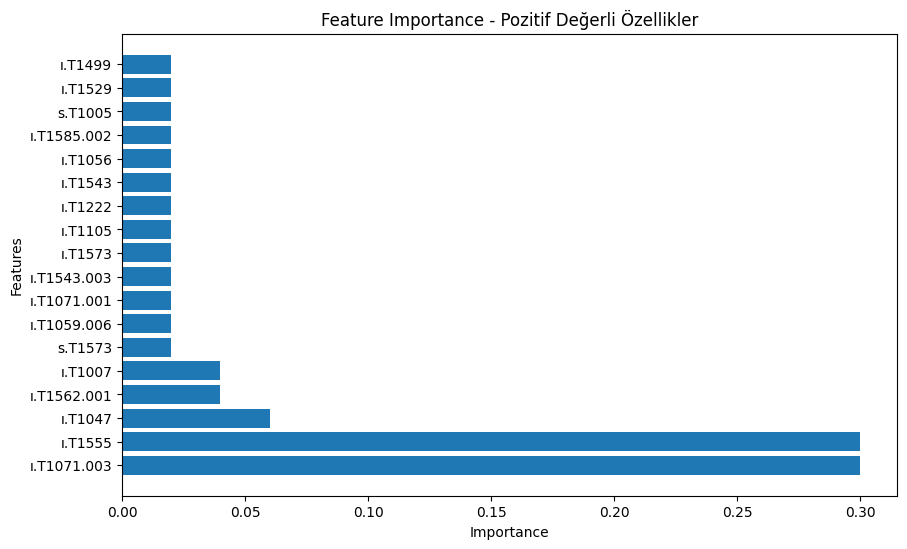

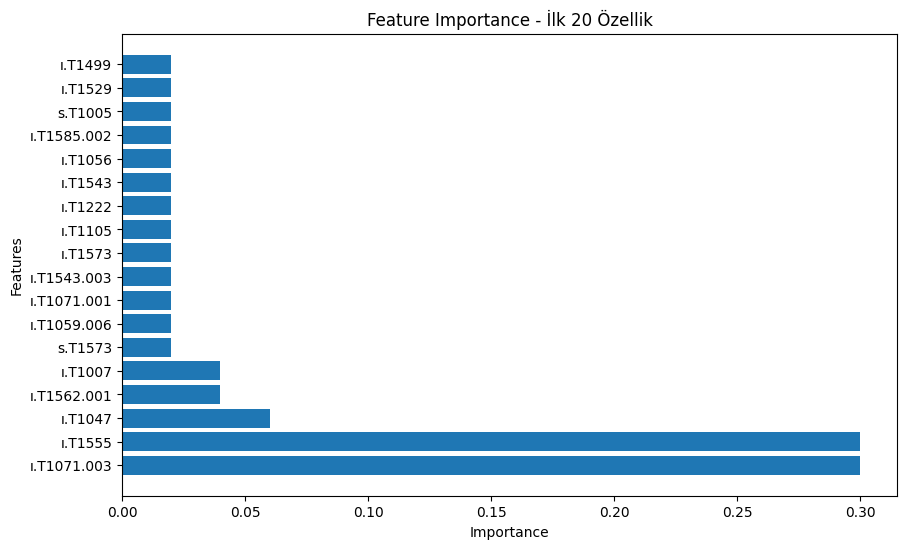

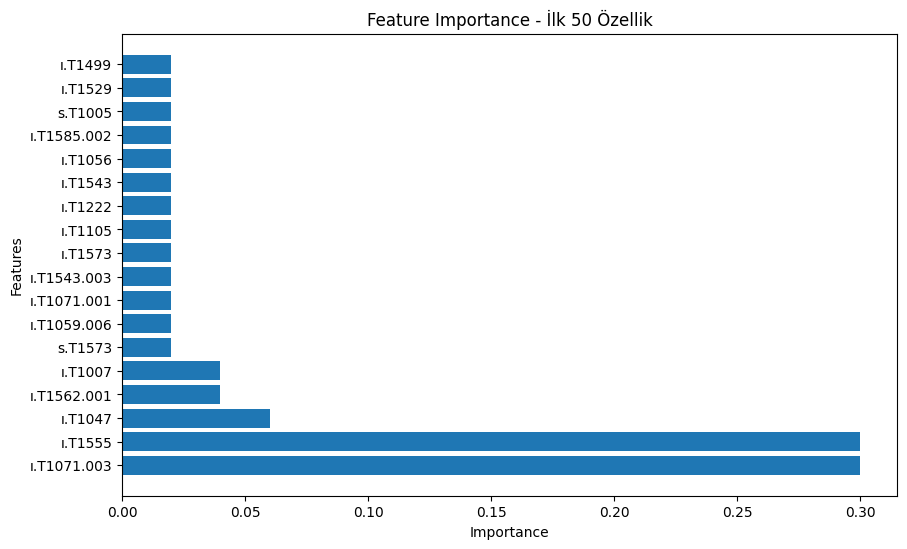

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)  # Burada 'estimator' kullanılıyor

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
# AdaBoost içinde kullanılan DecisionTree zayıf öğrenicilerinin feature importance değerlerini toplarız
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`SMOTE`***

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[12  2]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Pozitif özellikler ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 20 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 50 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



<ipython-input-72-47862064de6f>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


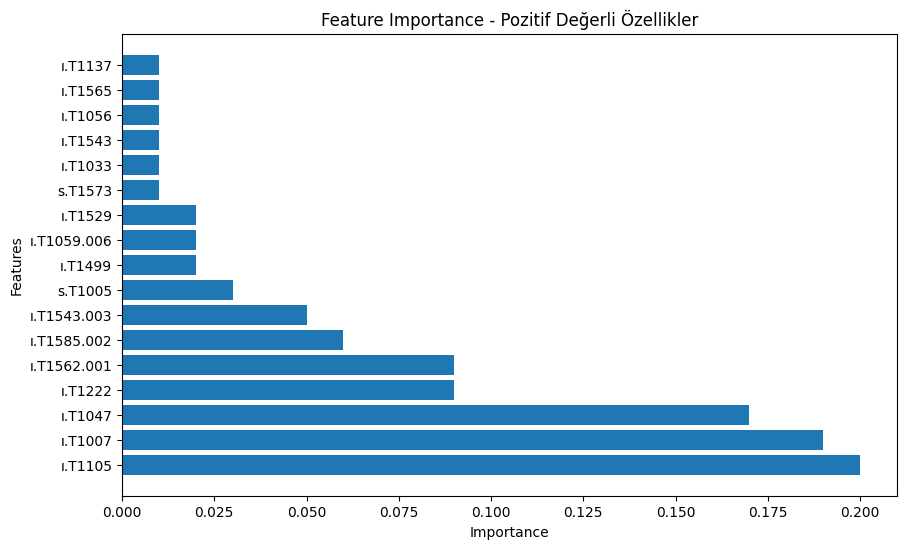

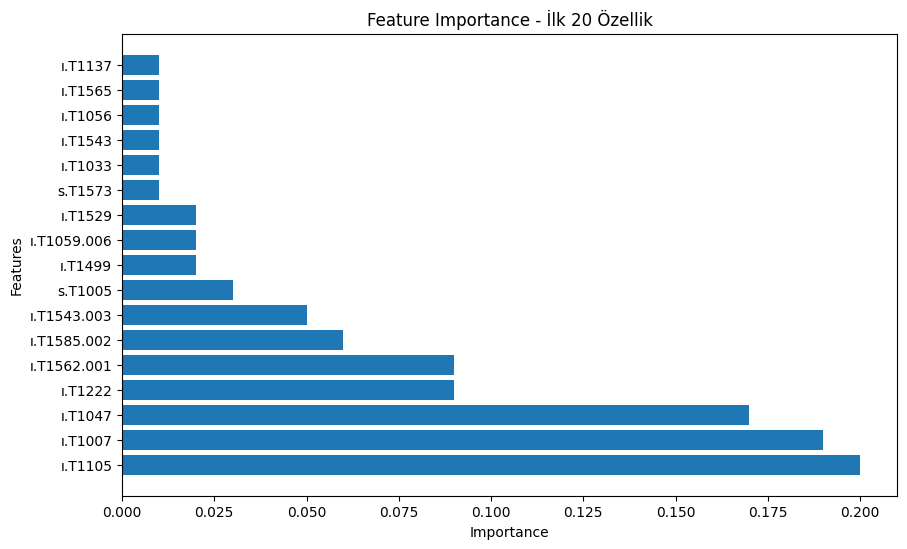

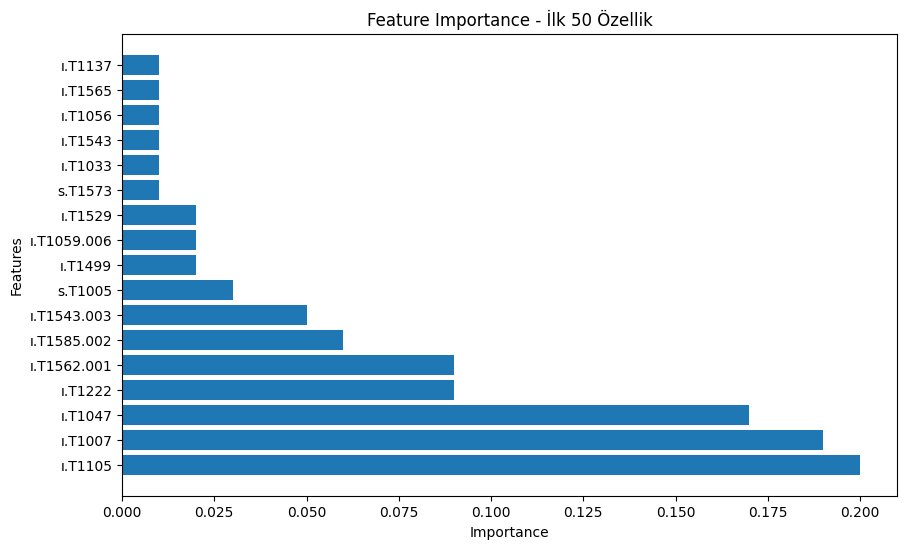

In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veri artırma (SMOTE)
smote = SMOTE(random_state=42)
X_egitim_smote, y_egitim_smote = smote.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)  # Burada 'estimator' kullanılıyor

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim_smote, y_egitim_smote)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`Borderline-SMOTE`***

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[12  2]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Pozitif özellikler ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 20 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 50 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



<ipython-input-73-7808b45eeaa1>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


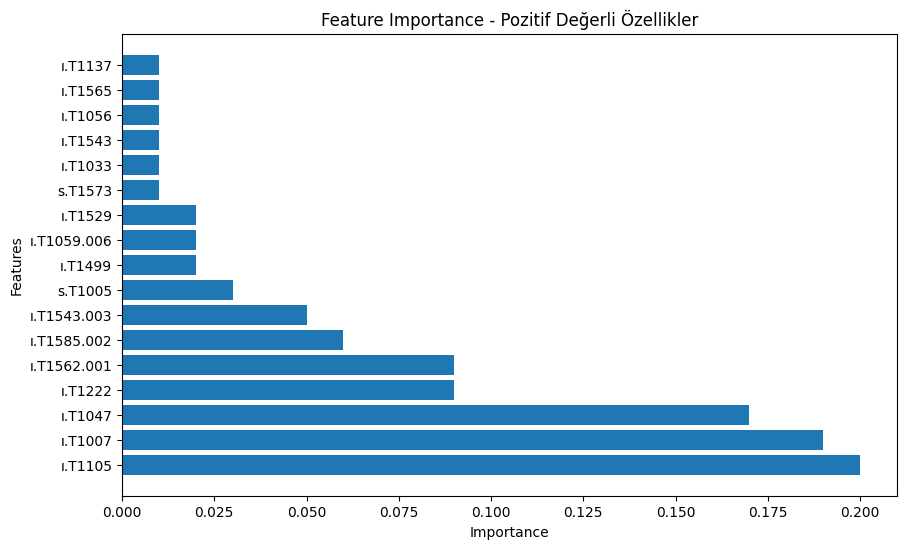

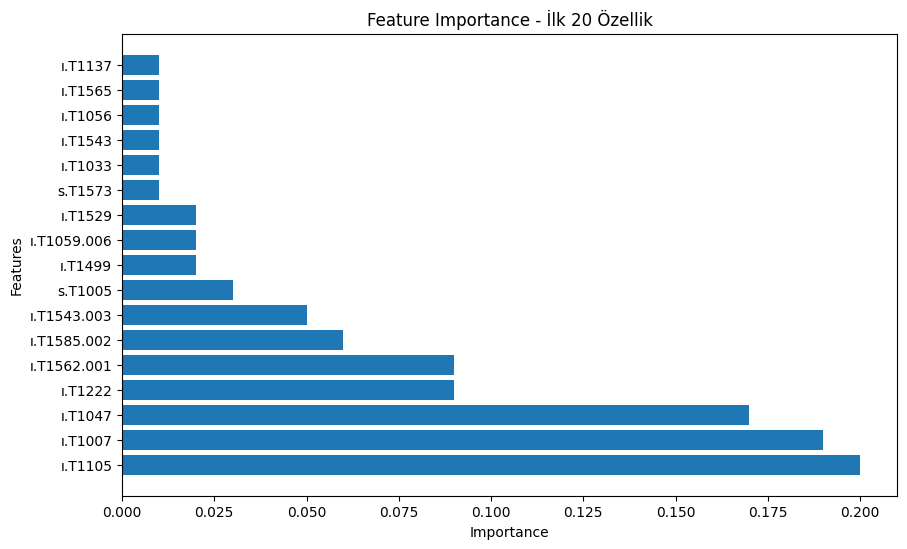

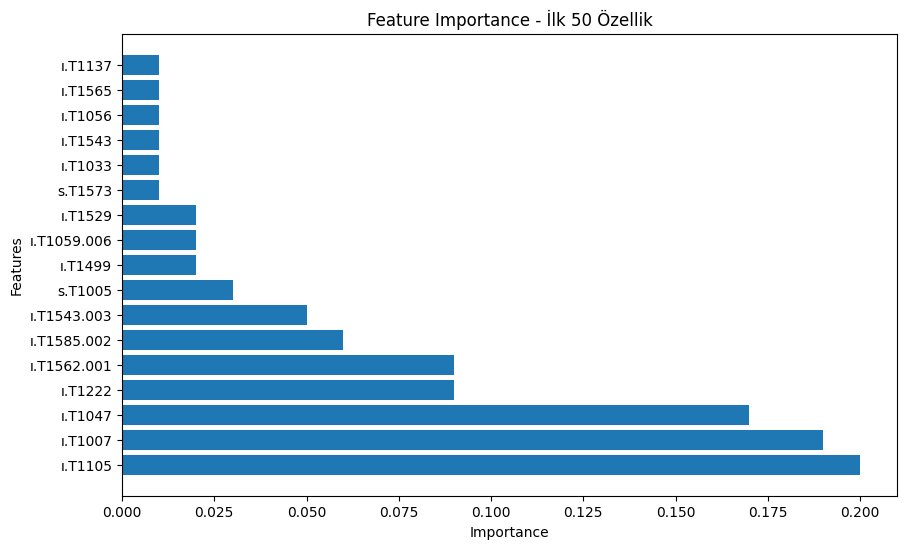

In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import BorderlineSMOTE
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BorderlineSMOTE ile veri dengesizliğini giderin
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`SMOTENC (SMOTE for Nominal and Continuous)`***

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[12  2]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Pozitif özellikler ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 20 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 50 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
<ipython-input-74-d1698ebd04d2>:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



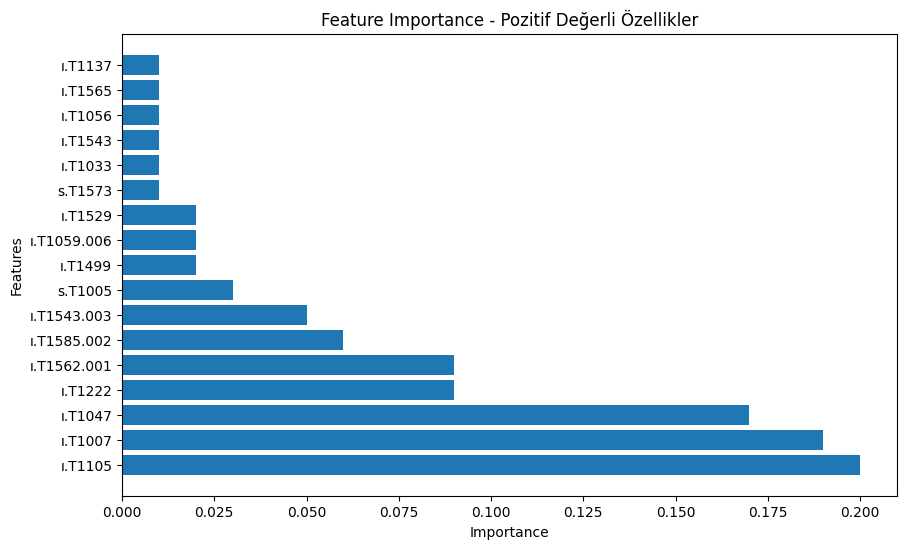

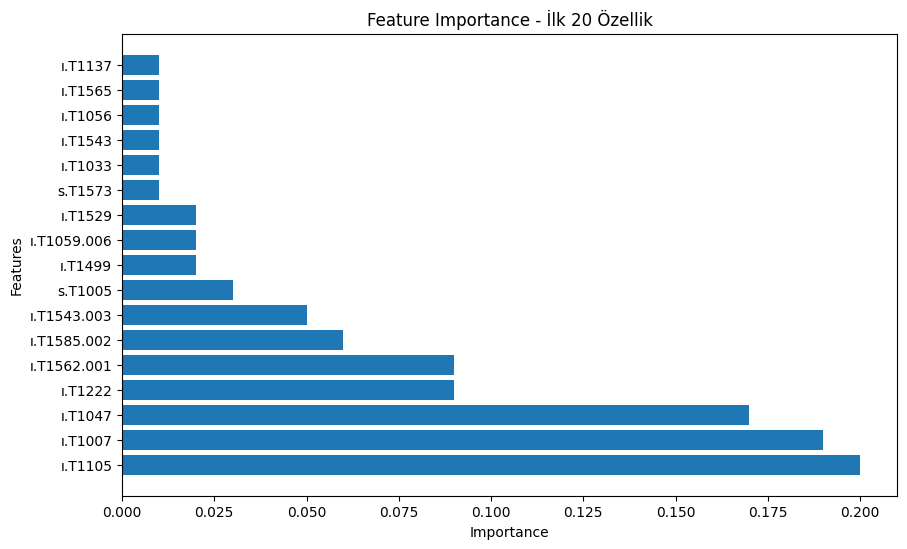

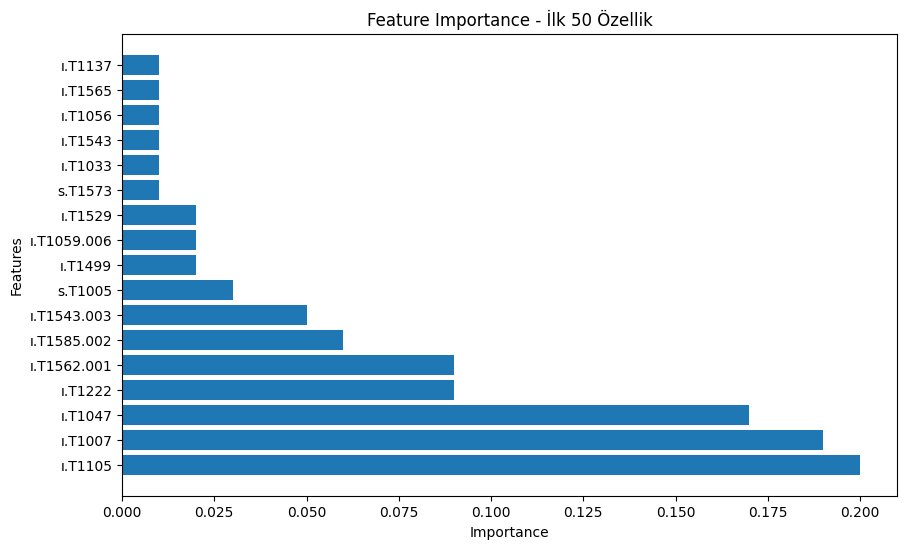

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`RandomOverSampler`***

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[12  2]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Pozitif özellikler ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 20 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25


İlk 50 özellik ile sonuçlar:
[[12  2]
 [ 8  3]]
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                   

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
<ipython-input-75-5bd50f5e28ca>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


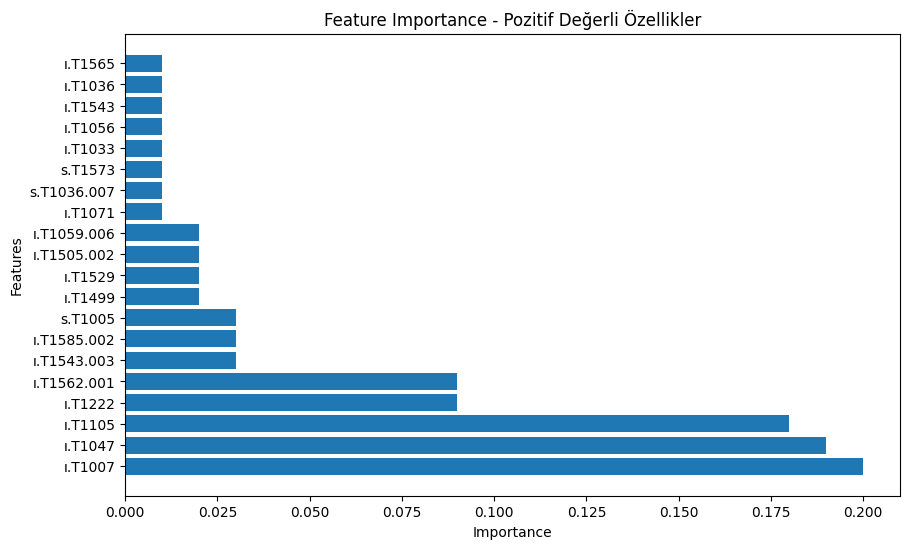

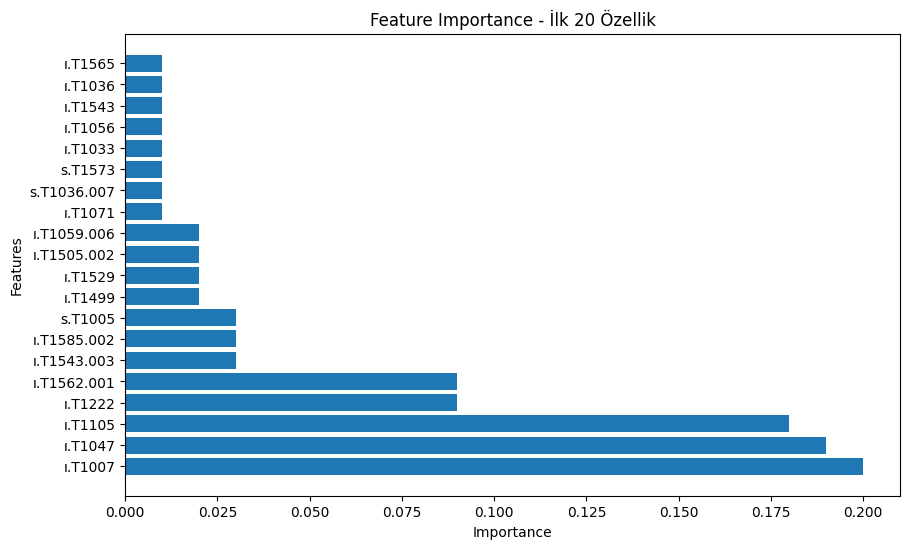

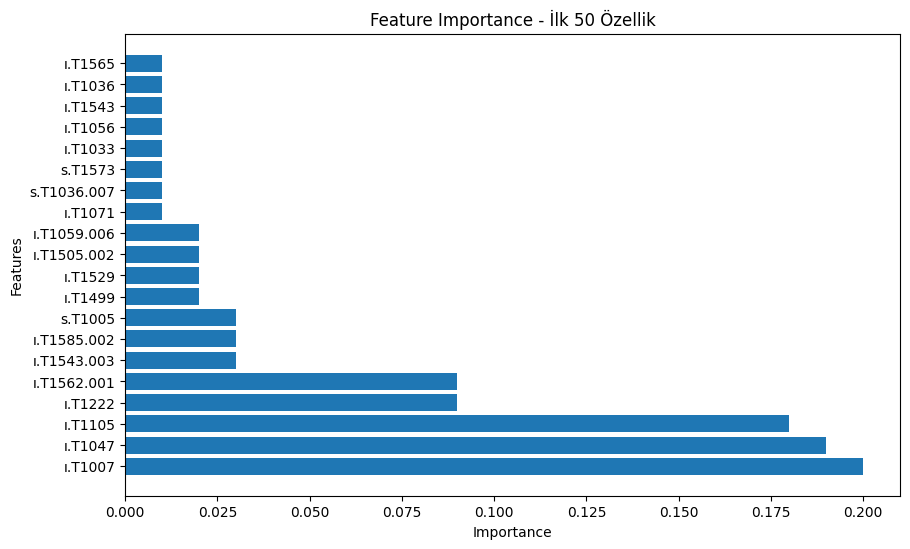

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomOverSampler kullanarak veri setini dengeleyin
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***` Tomek Links`***

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks

# DataFrame'i tanımla (Bu kısmı kendi veri setinize göre güncellemelisiniz)
# Örneğin:
# df = pd.read_csv('veriseti.csv')

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TomekLinks kullanarak veriyi örneklendirin
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42],  # İstediğiniz bir rastgele durum seçilebilir
    # Diğer parametreleri buraya ekleyebilirsiniz
}

# Grid Search
grid_search = GridSearchCV(AdaBoostClassifier(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 50, 'random_state': 42}
Karmaşıklık Matrisi:
[[14  0]
 [ 6  5]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        14
           1       1.00      0.45      0.62        11

    accuracy                           0.76        25
   macro avg       0.85      0.73      0.72        25
weighted avg       0.83      0.76      0.74        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Fitting 3 folds for each of 18 candidates, totalling 54 fits
En iyi parametreler:  {'algorithm': 'SAMME', 'learning_rate': 0.01, 'n_estimators': 50, 'random_state': 42}
Karmaşıklık Matrisi:
[[ 0 14]
 [ 2  9]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.39      0.82      0.53        11

    accuracy                           0.36        25
   macro avg       0.20      0.41      0.26        25
weighted avg       0.17      0.36      0.23        25


Pozitif özellikler ile sonuçlar:
[[ 0 14]
 [ 1 10]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.42      0.91      0.57        11

    accuracy                           0.40        25
   macro avg       0.21      0.45      0.29        25
weighted avg       0.18      0.40      0.25        25


İlk 20 özellik ile sonuçlar:
[[ 0 14]
 [ 1 10]]
            

<ipython-input-77-d25865f815cf>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


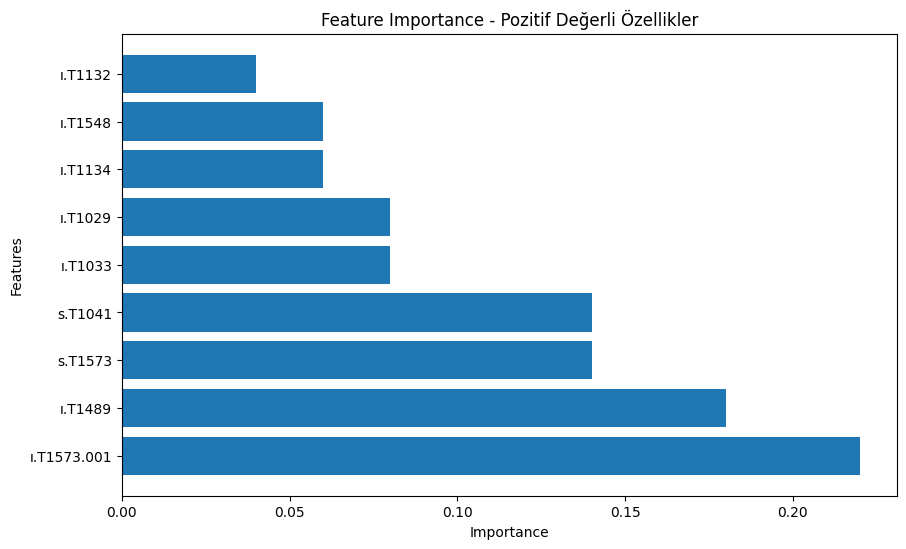

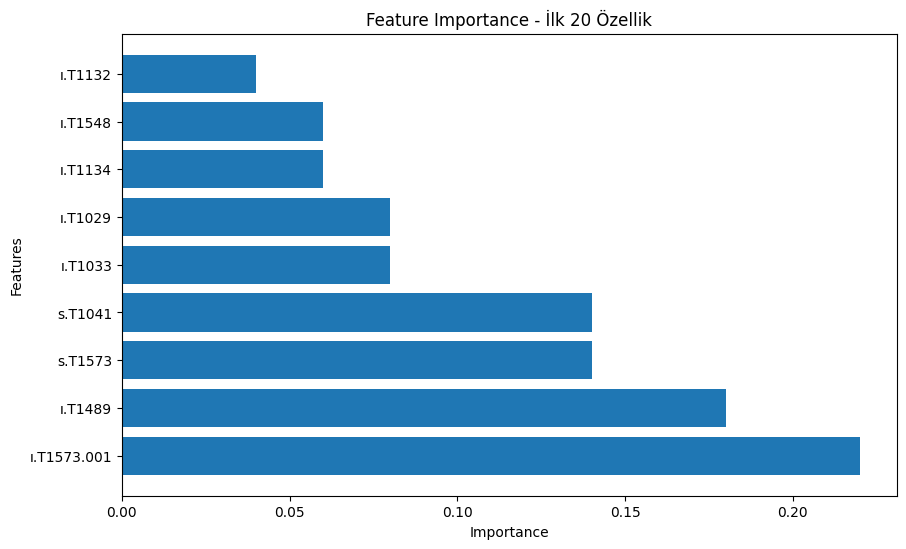

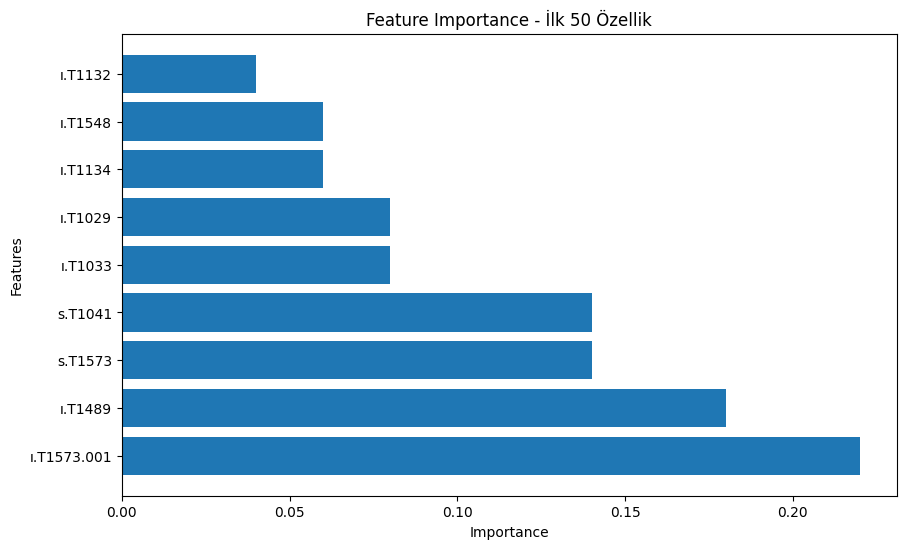

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TomekLinks kullanarak veriyi dengeleyin
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek

# DataFrame'i tanımla (Bu kısmı kendi veri setinize göre güncellemelisin)
# Örneğin:
# df = pd.read_csv('veriseti.csv')

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTETomek kullanarak veriyi örneklendirin
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42],  # İstediğiniz bir rastgele durum seçilebilir
    # Diğer parametreleri buraya ekleyebilirsiniz
}

# Grid Search
grid_search = GridSearchCV(AdaBoostClassifier(), param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
En iyi parametreler:  {'algorithm': 'SAMME', 'learning_rate': 1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[13  1]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.62      0.93      0.74        14
           1       0.75      0.27      0.40        11

    accuracy                           0.64        25
   macro avg       0.68      0.60      0.57        25
weighted avg       0.68      0.64      0.59        25



Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


En iyi parametreler:  {'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 100, 'random_state': 42}
Karmaşıklık Matrisi:
[[12  2]
 [ 8  3]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.60      0.27      0.38        11

    accuracy                           0.60        25
   macro avg       0.60      0.56      0.54        25
weighted avg       0.60      0.60      0.56        25



/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Pozitif özellikler ile sonuçlar:
[[12  2]
 [ 9  2]]
              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.50      0.18      0.27        11

    accuracy                           0.56        25
   macro avg       0.54      0.52      0.48        25
weighted avg       0.54      0.56      0.50        25


İlk 20 özellik ile sonuçlar:
[[12  2]
 [ 9  2]]
              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.50      0.18      0.27        11

    accuracy                           0.56        25
   macro avg       0.54      0.52      0.48        25
weighted avg       0.54      0.56      0.50        25


İlk 50 özellik ile sonuçlar:
[[12  2]
 [ 9  2]]


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.57      0.86      0.69        14
           1       0.50      0.18      0.27        11

    accuracy                           0.56        25
   macro avg       0.54      0.52      0.48        25
weighted avg       0.54      0.56      0.50        25



<ipython-input-79-a3b2f1ec2795>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  positive_features.sort_values(by='Importance', ascending=False, inplace=True)


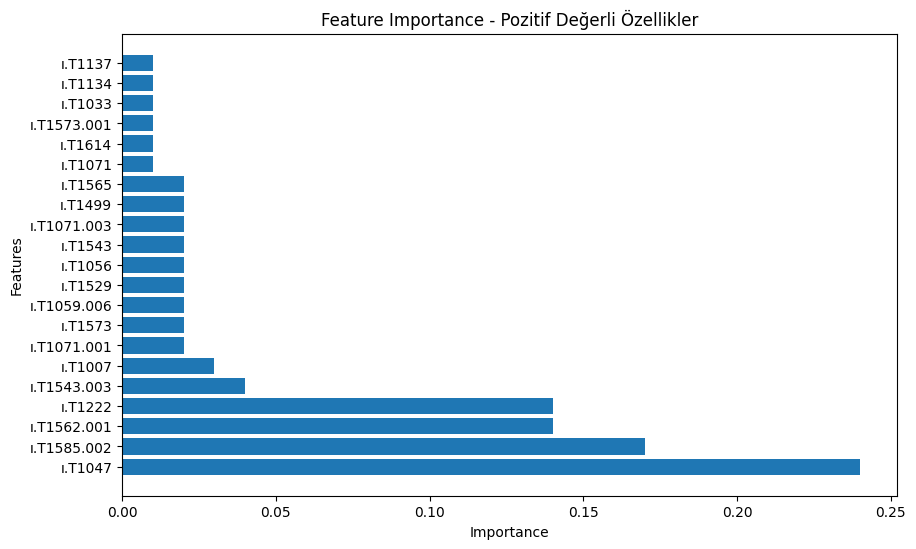

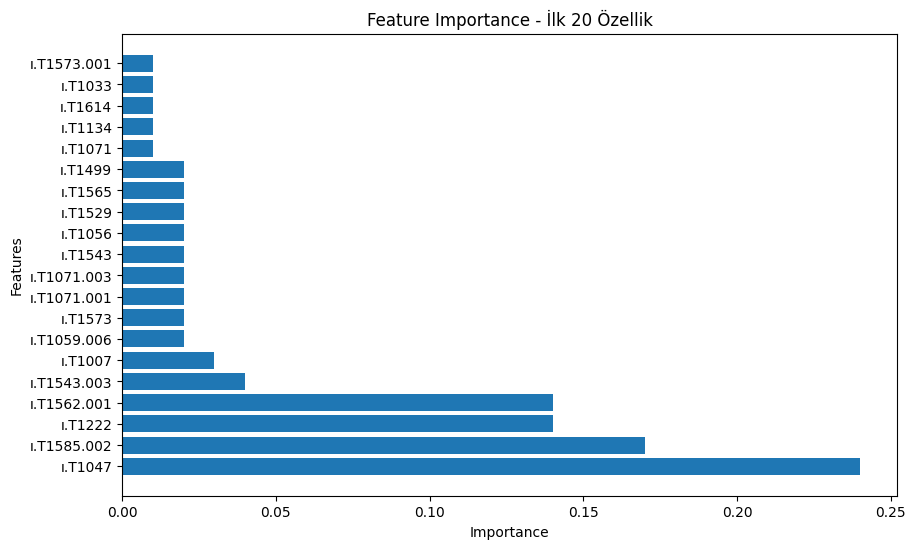

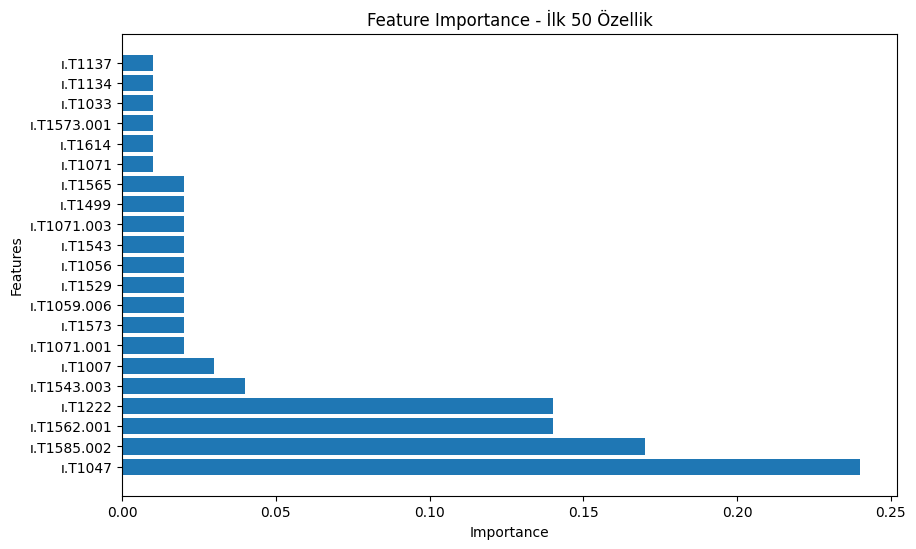

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTETomek kullanarak veri kümesini dengeleyin
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_egitim, y_egitim)

# Grid Search için parametreler
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [42]
}

# DecisionTree tabanlı AdaBoost modelini tanımlayın
base_estimator = DecisionTreeClassifier(max_depth=1)  # Zayıf öğrenici olarak kullanılır
ada_boost = AdaBoostClassifier(estimator=base_estimator)

# Grid Search
grid_search = GridSearchCV(ada_boost, param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled, y_resampled)

# En iyi parametreleri göster
print("En iyi parametreler: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.best_estimator_.predict(X_test)

# Sonuçları göster
print("Karmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

# Feature importance hesaplama
importances = np.mean([
    tree.feature_importances_ for tree in grid_search.best_estimator_.estimators_], axis=0)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Pozitif önem değerine sahip olan özellikler
positive_features = feature_importances[feature_importances['Importance'] > 0]

# İlk 20 ve ilk 50 önemli özellikleri al
top_20_features = positive_features.nlargest(20, 'Importance')
top_50_features = positive_features.nlargest(50, 'Importance')

# Pozitif önem değerine sahip olan özelliklerle model tekrar çalıştır
X_egitim_pos = X_egitim[positive_features['Feature']]
X_test_pos = X_test[positive_features['Feature']]

# İlk 20 özellik ile model çalıştırma
X_egitim_top_20 = X_egitim[top_20_features['Feature']]
X_test_top_20 = X_test[top_20_features['Feature']]

# İlk 50 özellik ile model çalıştırma
X_egitim_top_50 = X_egitim[top_50_features['Feature']]
X_test_top_50 = X_test[top_50_features['Feature']]

# Pozitif özelliklerle model eğitimi
grid_search.best_estimator_.fit(X_egitim_pos, y_egitim)
y_pred_pos = grid_search.best_estimator_.predict(X_test_pos)
print("\nPozitif özellikler ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_pos))
print(classification_report(y_test, y_pred_pos))

# İlk 20 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_20, y_egitim)
y_pred_top_20 = grid_search.best_estimator_.predict(X_test_top_20)
print("\nİlk 20 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_20))
print(classification_report(y_test, y_pred_top_20))

# İlk 50 özellik ile model eğitimi
grid_search.best_estimator_.fit(X_egitim_top_50, y_egitim)
y_pred_top_50 = grid_search.best_estimator_.predict(X_test_top_50)
print("\nİlk 50 özellik ile sonuçlar:")
print(confusion_matrix(y_test, y_pred_top_50))
print(classification_report(y_test, y_pred_top_50))

# Pozitif özellikler için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
positive_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(positive_features['Feature'], positive_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Pozitif Değerli Özellikler')
plt.show()

# İlk 20 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_20_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 20 Özellik')
plt.show()

# İlk 50 önemli özellik için çubuk grafiği çizdir
plt.figure(figsize=(10, 6))
top_50_features.sort_values(by='Importance', ascending=False, inplace=True)
plt.barh(top_50_features['Feature'], top_50_features['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - İlk 50 Özellik')
plt.show()


# ***`Yapay Sinir Ağları (Neural Networks)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Yapay Sinir Ağları modelini oluşturun
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)  # İstenilen katman ve nöron sayısını belirleyebilirsiniz

# Modeli eğitin
mlp_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendirin
y_pred = mlp_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veri artırma (SMOTE)
smote = SMOTE(random_state=42)
X_egitim_smote, y_egitim_smote = smote.fit_resample(X_egitim, y_egitim)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim_smote = scaler.fit_transform(X_egitim_smote)
X_test = scaler.transform(X_test)

# Yapay Sinir Ağları modelini oluşturun
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)  # İstenilen katman ve nöron sayısını belirleyebilirsiniz

# Modeli eğitin
mlp_model.fit(X_egitim_smote, y_egitim_smote)

# Test seti üzerinde modeli değerlendirin
y_pred = mlp_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Yapay Sinir Ağları modelini oluşturun ve parametreleri ayarlayın
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='tanh', max_iter=500, learning_rate='adaptive', alpha=0.001, momentum=0.2)


# Modeli eğitin
mlp_model.fit(X_egitim, y_egitim)

# Test seti üzerinde modeli değerlendirin
y_pred = mlp_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Veri setini yükleyin veya oluşturun
# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veri artırma (SMOTE)
smote = SMOTE(random_state=42)
X_egitim_smote, y_egitim_smote = smote.fit_resample(X_egitim, y_egitim)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim_smote = scaler.fit_transform(X_egitim_smote)
X_test = scaler.transform(X_test)

# Yapay Sinir Ağları modelini oluşturun ve parametreleri ayarlayın
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='tanh', max_iter=500, learning_rate='adaptive', alpha=0.001, momentum=0.2)

# Modeli eğitin
mlp_model.fit(X_egitim_smote, y_egitim_smote)

# Test seti üzerinde modeli değerlendirin
y_pred = mlp_model.predict(X_test)

# Sonuçları gösterin
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim = scaler.fit_transform(X_egitim)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim, y_egitim)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


In [ ]:
#veri artırmalı
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Veri artırma (SMOTE)
smote = SMOTE(random_state=42)
X_egitim_smote, y_egitim_smote = smote.fit_resample(X_egitim, y_egitim)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim_smote = scaler.fit_transform(X_egitim_smote)
X_test = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim_smote, y_egitim_smote)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`ADASYN (Adaptive Synthetic Sampling)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import ADASYN

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ADASYN kullanarak veriyi örneklendirin
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim_resampled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim_resampled, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`Borderline-SMOTE`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import BorderlineSMOTE

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# BorderlineSMOTE kullanarak veriyi örneklendirin
borderline_smote = BorderlineSMOTE(random_state=42)
X_resampled, y_resampled = borderline_smote.fit_resample(X, y)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_egitim_smote = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_egitim_smote, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`SMOTENC (SMOTE for Nominal and Continuous)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Kategorik özelliklerin indekslerini belirtin (örneğin, 0 ve 2. sütunlar kategorik olsun)
categorical_features = [0, 2]
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled_scaled, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`RandomOverSampler`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomOverSampler kullanarak veriyi örneklendirin
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_egitim, y_egitim)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled_scaled, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`Tomek Links`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import TomekLinks

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TomekLinks kullanarak veriyi örneklendirin
tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled_scaled, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


***`Combination of Over- and Under-Sampling (SMOTE + Tomek Links)`***

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.combine import SMOTETomek

# Özellikleri ve etiketleri ayırın
X = df.drop('Malicious', axis=1)  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız
y = df['Malicious']  # 'Malicious' yerine gerçek etiket sütununun adını yazmalısınız

# Eğitim ve test setlerine ayırın
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SMOTETomek kullanarak veriyi örneklendirin
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

# Verileri ölçeklendirin
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)
X_test_scaled = scaler.transform(X_test)

# Hiperparametre ızgarası
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50), (150, 100, 50)],
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500, 1000],
    'momentum': [0.2, 0.5, 0.9]
}

# Grid Search
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_resampled_scaled, y_resampled)

# En iyi parametreleri göster
print("Best parameters found: ", grid_search.best_params_)

# En iyi model ile tahminler
y_pred = grid_search.predict(X_test_scaled)

# Sonuçları göster
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
